# 08. Portfolio Construction

El objetivo de este notebook será transformar las predicciones OOS de Ridge, XGBoost y Random Forest en señales de inversión y posteriormente en carteras invertibles, evaluando cómo las distintas reglas de selección, asignación de pesos, restricciones y rebalanceo afectan al resultado económico.

El objetivo no es todavía realizar un análisis exhaustivo de rentabilidad y riesgo, sino construir de forma sistemática las carteras que posteriormente serán evaluadas en el Notebook 09.

## 1. Imports & Configuration

### 1.1 Librerías

In [2]:
import sys
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import warnings
import joblib

from pathlib import Path
from scipy.stats import spearmanr

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

### 1.2 Configuración del notebook

El horizonte de predicción utilizado por los modelos es de 21 sesiones de trading, correspondiente al target forward_return_21d. Este horizonte define el periodo sobre el que se evalúa la capacidad predictiva de las señales, pero no determina automáticamente la frecuencia de rebalanceo de las carteras. Como configuración inicial se utilizará un rebalanceo cada 21 sesiones, que posteriormente se comparará con frecuencias alternativas para analizar su impacto sobre turnover, costes y estabilidad de las posiciones.

Las carteras benchmark se construirán a partir de los extremos del ranking cross-sectional, utilizando el 10% superior para posiciones long y, en estrategias long-short, el 10% inferior para posiciones short. Las exposiciones objetivo se mantendrán constantes entre modelos para garantizar una comparación homogénea, mientras que el número exacto de posiciones dependerá del universo disponible en cada fecha de rebalanceo.


In [2]:
# =============================================================================
# Experiment Configuration
# =============================================================================

# Prediction horizon
PREDICTION_HORIZON = 21

# Rebalancing
# Benchmark frequency; alternative frequencies will be evaluated later.
REBALANCING_FREQUENCY = 21

# Portfolio selection
SELECTION_PERCENTS = [0.10, 0.20, 0.30]

# Benchmark selection
BENCHMARK_SELECTION = 0.10

# Long-only exposure
LONG_ONLY_GROSS_EXPOSURE = 1.00

# Long-short exposure
LONG_SHORT_LONG_EXPOSURE = 0.50
LONG_SHORT_SHORT_EXPOSURE = 0.50

# Position selection
POSITION_COUNT_MODE = "quantile"

In [3]:
# =============================================================================
# Exposure Validation
# =============================================================================

assert (
    LONG_SHORT_LONG_EXPOSURE >= 0
    and LONG_SHORT_SHORT_EXPOSURE >= 0
)

assert (
    LONG_SHORT_LONG_EXPOSURE
    + LONG_SHORT_SHORT_EXPOSURE
    > 0
)

### 1.3 Rutas y parámetros globales

In [4]:
# =============================================================================
# Paths
# =============================================================================

OOS_DATA_PATH = "../data/model_results/final_model/oos/"
PREDICTIONS_PATH = (OOS_DATA_PATH + "oos_predictions.parquet")

# Path to price data (OOS included)
PRICES_PATH = "../data/raw/sp500_prices_extended.parquet"

# =============================================================================
# Models
# =============================================================================

MODEL_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}

# =============================================================================
# Required Columns
# =============================================================================

REQUIRED_COLUMNS = [
    "prediction_ridge_rank",
    "prediction_xgb_rank",
    "prediction_rf_rank",
    "forward_return_21d",
]

# =============================================================================
# Signal Configuration
# =============================================================================

PREDICTION_COLUMNS = list(MODEL_COLUMNS.values())

RANKING_METHOD = "cross_sectional_percentile"

## 2. Data Loading

### 2.1 Carga de predicciones OOS

In [5]:
# =============================================================================
# Load OOS Predictions
# =============================================================================

oos_predictions = pd.read_parquet(PREDICTIONS_PATH)

print(f"OOS predictions shape: {oos_predictions.shape}")
print(f"Date range: {oos_predictions.index.get_level_values('date').min()} "
      f"→ {oos_predictions.index.get_level_values('date').max()}")

OOS predictions shape: (184408, 7)
Date range: 2025-01-15 00:00:00 → 2026-07-10 00:00:00


In [6]:
# =============================================================================
# Prediction Columns Check
# =============================================================================

missing_prediction_columns = [
    column
    for column in PREDICTION_COLUMNS
    if column not in oos_predictions.columns
]

assert not missing_prediction_columns, (
    f"Missing prediction columns: {missing_prediction_columns}"
)

# =============================================================================
# Index Check
# =============================================================================

assert isinstance(oos_predictions.index, pd.MultiIndex)
assert oos_predictions.index.names == ["date", "ticker"]

# =============================================================================
# Prediction Availability Check
# =============================================================================

assert oos_predictions[PREDICTION_COLUMNS].notna().any().all(), (
    "At least one prediction column contains no valid observations."
)

### 2.2 Carga de precios y retornos realizados

Se cargan los precios históricos necesarios para el backtest y se restringe el universo al conjunto de activos utilizado por las predicciones OOS. Se conserva toda la cobertura histórica disponible, ya que los precios anteriores al periodo OOS pueden ser necesarios para estimar medidas de riesgo en cada fecha de rebalanceo. A partir de los precios ajustados se calculan los retornos simples y logarítmicos, que se utilizarán posteriormente en la construcción y evaluación de las carteras.

In [7]:
# =============================================================================
# Load Extended Price Data
# =============================================================================

prices = pd.read_parquet(PRICES_PATH)

# =============================================================================
# Remove Securities Excluded During Development
# =============================================================================

tickers_to_remove = [
    "SW",
    "AMCR",
]

prices = prices.drop(
    columns=tickers_to_remove,
    level=1,
    errors="ignore",
)

# =============================================================================
# Align Price Universe with OOS Universe
# =============================================================================

oos_tickers = oos_predictions.index.get_level_values("ticker").unique()

price_tickers = prices.columns.get_level_values(1)

missing_price_tickers = oos_tickers.difference(price_tickers)

assert len(missing_price_tickers) == 0, (
    f"Missing price data for tickers: "
    f"{missing_price_tickers.tolist()}"
)

prices = prices.loc[
    :,
    prices.columns.get_level_values(1).isin(oos_tickers)
]

# =============================================================================
# Compute Returns
# =============================================================================

adj_close = prices["Adj Close"]

simple_returns = adj_close.pct_change()

log_returns = np.log(
    adj_close / adj_close.shift(1)
)

In [8]:
print(
    f"Price data coverage: "
    f"{prices.index.min().date()} → {prices.index.max().date()}"
)

print(f"Number of securities: {len(oos_tickers)}")

Price data coverage: 2010-01-04 → 2026-08-10
Number of securities: 496


### 2.3 Verificación de integridad y cobertura temporal

Antes de comenzar la construcción de las señales y carteras, se verifica que las predicciones OOS, los precios y los retornos presentan una cobertura temporal y un universo de activos compatibles. Se comprueba que todos los activos y fechas necesarios para el periodo OOS disponen de información de precios y que las series de retornos permanecen correctamente alineadas con los precios originales. Estas comprobaciones garantizan la consistencia de los datos utilizados en el backtest, mientras que la prevención de look-ahead bias se controlará posteriormente en cada etapa en la que se utilice información histórica para determinar señales, riesgo o pesos de cartera.

In [9]:
# =============================================================================
# Temporal Coverage
# =============================================================================

oos_dates = (
    oos_predictions.index
    .get_level_values("date")
    .unique()
)

assert oos_dates.min() >= prices.index.min()
assert oos_dates.max() <= prices.index.max()

# =============================================================================
# Ticker Coverage
# =============================================================================

oos_tickers = (
    oos_predictions.index
    .get_level_values("ticker")
    .unique()
)

price_tickers = (
    prices.columns
    .get_level_values(1)
    .unique()
)

missing_price_tickers = oos_tickers.difference(price_tickers)

assert len(missing_price_tickers) == 0, (
    f"Missing price data for tickers: "
    f"{missing_price_tickers.tolist()}"
)

# =============================================================================
# Prediction Date Coverage
# =============================================================================

missing_prediction_dates = oos_dates.difference(
    prices.index
)

assert len(missing_prediction_dates) == 0, (
    f"Missing price data for OOS dates: "
    f"{missing_prediction_dates.tolist()}"
)

# =============================================================================
# Returns Alignment
# =============================================================================

assert simple_returns.index.equals(prices.index)
assert log_returns.index.equals(prices.index)

assert simple_returns.columns.equals(adj_close.columns)
assert log_returns.columns.equals(adj_close.columns)

# =============================================================================
# Data Availability
# =============================================================================

assert simple_returns.notna().any().all(), (
    "Some securities contain no valid simple returns."
)

assert log_returns.notna().any().all(), (
    "Some securities contain no valid log returns."
)

## 3. Signal Construction

### 3.1 Cross-sectional Ranking

Las predicciones OOS de Ridge, XGBoost y Random Forest se transforman en rankings cross-sectional diarios para ordenar los activos según la intensidad relativa de su señal. El ranking se calcula únicamente sobre los activos que disponen de una predicción válida en cada fecha, respetando el universo efectivamente disponible durante el periodo OOS. Dado que los modelos basados en árboles presentan un número reducido de valores de predicción únicos, especialmente XGBoost, se utiliza un ranking determinista (method="first") para resolver los empates y garantizar una distribución aproximadamente equilibrada de los activos en los posteriores grupos de selección. Esta transformación no modifica las predicciones OOS originales.

In [10]:
# =============================================================================
# Cross-sectional Ranking
# =============================================================================

signal_ranks = pd.DataFrame(
    index=oos_predictions.index
)

RANK_COLUMNS = {}

for model, prediction_column in MODEL_COLUMNS.items():

    rank_column = f"{model.lower().replace(' ', '_')}_rank"

    signal_ranks[rank_column] = (
        oos_predictions
        .groupby(level="date")[prediction_column]
        .rank(
            method="first",
            pct=True,
        )
    )

    RANK_COLUMNS[model] = rank_column

In [11]:
# =============================================================================
# Ranking Validation
# =============================================================================

for rank_column in RANK_COLUMNS.values():

    assert signal_ranks[rank_column].dropna().between(0, 1).all(), (
        f"Invalid values found in {rank_column}."
    )

# =============================================================================
# Cross-sectional Coverage
# =============================================================================

rank_counts = (
    signal_ranks
    .groupby(level="date")
    .size()
)

print(
    f"Cross-sectional observations per date: "
    f"Min = {rank_counts.min()} | "
    f"Max = {rank_counts.max()}"
)

Cross-sectional observations per date: Min = 494 | Max = 496


### 3.2 Quantile Formation

El ranking cross-sectional continuo se divide en diez grupos de tamaño aproximadamente equivalente, desde D1, que contiene los activos con las predicciones relativas más bajas, hasta D10, que contiene los activos con las predicciones más altas. La formación de los grupos se realiza diariamente, utilizando únicamente los activos disponibles en cada fecha.

Debido al elevado número de empates presente en las predicciones de los modelos basados en árboles, especialmente XGBoost, se utiliza un ranking determinista (method="first") para resolver los empates antes de formar los cuantiles. De esta forma se evitan grupos excesivamente desiguales y se garantiza una comparación homogénea entre modelos. Esta decisión únicamente afecta a la asignación de observaciones a grupos y no modifica las predicciones originales.


In [12]:
# =============================================================================
# Quantile Formation
# =============================================================================

quantile_data = pd.DataFrame(
    index=signal_ranks.index
)

QUANTILE_COLUMNS = {}

for model, rank_column in RANK_COLUMNS.items():

    quantile_column = (
        f"{model.lower().replace(' ', '_')}_quantile"
    )

    quantile_data[quantile_column] = (
        np.ceil(
            signal_ranks[rank_column] * 10
        )
        .clip(upper=10)
        .astype("Int64")
    )

    QUANTILE_COLUMNS[model] = quantile_column

In [13]:
# =============================================================================
# Quantile Distribution
# =============================================================================

quantile_counts = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data
        .groupby(level="date")[quantile_column]
        .value_counts()
        .unstack(fill_value=0)
    )

    quantile_counts[model] = counts

for model, counts in quantile_counts.items():

    print("=" * 80)
    print(f"{model} — QUANTILE SIZE RANGE")
    print("=" * 80)

    print(
        f"Min = {counts.min().min()} | "
        f"Max = {counts.max().max()}"
    )

Ridge — QUANTILE SIZE RANGE
Min = 49 | Max = 50
XGBoost — QUANTILE SIZE RANGE
Min = 49 | Max = 50
Random Forest — QUANTILE SIZE RANGE
Min = 49 | Max = 50


### 3.3 Signal Distribution Analysis

Antes de utilizar los rankings para construir las carteras, se analiza su distribución cross-sectional durante el periodo OOS. El objetivo es comprobar que las señales presentan suficiente dispersión entre activos y detectar posibles concentraciones, valores extremos o diferencias estructurales entre modelos que puedan afectar a la selección y posterior asignación de pesos. Dado que los rankings se construyen mediante percentiles cross-sectional, se presta especial atención a la distribución de las predicciones originales y al comportamiento de los grupos por cuantiles.


#### 3.3.1 Distribución de las predicciones

In [14]:
# =============================================================================
# Prediction Distribution
# =============================================================================

prediction_distribution = (
    oos_predictions[
        list(MODEL_COLUMNS.values())
    ]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
        ]
    ]
)

display(prediction_distribution)

# =============================================================================
# Unique Prediction Values
# =============================================================================

unique_predictions = pd.DataFrame(
    {
        model: [
            oos_predictions[prediction_column]
            .nunique()
        ]
        for model, prediction_column in MODEL_COLUMNS.items()
    },
    index=["Unique values"],
).T

display(unique_predictions)

,count,mean,std,min,25%,50%,75%,max
prediction_ridge_rank,184408.0,0.014807,0.004190,0.005012,0.011615,0.014853,0.017929,0.024854
prediction_xgb_rank,184408.0,0.014821,0.003660,0.013136,0.013136,0.013318,0.015174,0.057154
prediction_rf_rank,184408.0,0.015472,0.009112,0.011264,0.012054,0.013353,0.015931,0.159783


,Unique values
Ridge,182612
XGBoost,285
Random Forest,4680


El análisis descriptivo de las predicciones fuera de muestra revela marcadas diferencias en la naturaleza estadística de cada arquitectura. Mientras que el modelo lineal Ridge genera una distribución continua con una elevada granulatividad (182,612 valores únicos), los modelos basados en árboles muestran una clara concentración discreta. 

En particular, XGBoost comprime el universo de predicciones en apenas 285 valores únicos, provocando que más del $50\%$ de las observaciones colapsen en un valor idéntico ($0.013136$).Por su parte, Random Forest presenta una mayor variabilidad ($\sigma = 0.009112$) y una pronunciada asimetría hacia la cola derecha, alcanzando predicciones puntuales de hasta el $15.97\%$. 

A pesar de estas diferencias morfológicas en la distribución de las salidas, los tres modelos mantienen una media de retorno predicho altamente coherente entre sí ($\approx 1.48\% - 1.54\%$). Esta acusada presencia de empates en XGBoost y Random Forest ratifica la necesidad de aplicar un ranking determinista (method="first") para garantizar una división equitativa y homogénea del universo en cuantiles.

#### 3.3.2 Distribución de los rankings

In [15]:
# =============================================================================
# Ranking Distribution
# =============================================================================

rank_distribution = (
    signal_ranks
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
        ]
    ]
)

display(rank_distribution)

,count,mean,std,min,25%,50%,75%,max
ridge_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0
xgboost_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0
random_forest_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0


Tras la transformación a percentiles diarios ($[0, 1]$), la distribución de las tres señales converge exactamente a una distribución uniforme teórica $\mathcal{U}(0, 1)$.Los tres modelos presentan una media y mediana centradas en $0.5010$ y una desviación estándar idéntica a la teórica ($\sigma \approx 0.2887$). 

Esta estandarización elimina las diferencias de escala previas entre algoritmos, garantizando un punto de partida homogéneo y simétrico para la división en deciles ($D1$ a $D10$).

#### 3.3.3 Distribución de los cuantiles

In [16]:
# =============================================================================
# Quantile Distribution
# =============================================================================

quantile_distribution = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data[quantile_column]
        .value_counts()
        .sort_index()
    )

    quantile_distribution[model] = counts

quantile_distribution = pd.DataFrame(
    quantile_distribution
)

quantile_distribution.index.name = "Quantile"

display(quantile_distribution)

# =============================================================================
# Quantile Imbalance
# =============================================================================

quantile_imbalance = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data
        .groupby(level="date")[quantile_column]
        .value_counts()
        .unstack(fill_value=0)
    )

    quantile_imbalance[model] = {
        "Minimum group size": counts.min().min(),
        "Maximum group size": counts.max().max(),
        "Maximum imbalance": (
            counts.max().max()
            - counts.min().min()
        ),
    }

quantile_imbalance = pd.DataFrame(
    quantile_imbalance
).T

display(quantile_imbalance)

,Ridge,XGBoost,Random Forest
Quantile,,,
1,18228,18228,18228
2,18550,18550,18550
3,18278,18278,18278
4,18550,18550,18550
5,18596,18596,18596
6,18232,18232,18232
7,18546,18546,18546
8,18282,18282,18282
9,18546,18546,18546


,Minimum group size,Maximum group size,Maximum imbalance
Ridge,49,50,1
XGBoost,49,50,1
Random Forest,49,50,1



## 4. Benchmark Portfolio Formation

Antes de introducir metodologías de asignación de pesos basadas en la intensidad de la señal, el riesgo o la optimización, se construyen carteras benchmark mediante reglas simples y transparentes. Estas carteras permiten establecer una referencia común frente a la que evaluar posteriormente si los métodos de weighting más sofisticados aportan mejoras en términos de rentabilidad, riesgo, concentración o costes de implementación.

Se utilizarán dos benchmarks principales. El primero será una estrategia long-only basada en el decil superior del ranking, que servirá como referencia para evaluar diferentes metodologías de asignación dentro de una cartera con exposición positiva. El segundo será una estrategia long-short que combina el decil superior e inferior, permitiendo evaluar la capacidad de las señales para diferenciar entre activos con expectativas relativas altas y bajas.

En ambos casos se utilizará Equal Weight como regla de asignación inicial. De esta forma, la selección de activos y la asignación de pesos quedan separadas: los rankings determinan qué activos entran en la cartera, mientras que el benchmark asigna el mismo peso a todas las posiciones seleccionadas. Estas carteras constituirán la referencia frente a la que se compararán posteriormente las metodologías de Signal Weighting, Risk-Based Allocation y Mathematical Optimization.


In [17]:
# =============================================================================
# Portfolio Weights Structure
# =============================================================================

portfolio_weights = pd.DataFrame(
    columns=[
        "date",
        "ticker",
        "model",
        "portfolio",
        "weight",
    ]
)


### 4.1 Long-only Top 10% Equal Weight

Se construye una cartera long-only utilizando el decil superior del ranking de cada modelo como universo de inversión. Todos los activos seleccionados reciben el mismo peso, de forma que la cartera mantiene una exposición bruta y neta de 100% sin introducir información adicional sobre la intensidad de la señal o el riesgo individual de los activos. Esta estrategia constituye el benchmark principal para evaluar posteriormente si metodologías de weighting más sofisticadas aportan valor adicional respecto a una asignación simple y robusta. La selección se realiza de forma independiente para cada modelo y fecha de rebalanceo, y los pesos se almacenan en una estructura común para facilitar su posterior comparación.


In [18]:
# =============================================================================
# Long-only Top 10% Equal Weight
# =============================================================================

long_only_weights_list = []

for model, quantile_column in QUANTILE_COLUMNS.items():

    # -------------------------------------------------------------------------
    # Select top decile
    # -------------------------------------------------------------------------

    selected = (
        quantile_data[quantile_column] == 10
    )

    selected_index = (
        quantile_data.index[selected]
    )

    # -------------------------------------------------------------------------
    # Count selected positions per date
    # -------------------------------------------------------------------------

    selected_counts = (
        pd.Series(
            1,
            index=selected_index,
        )
        .groupby(level="date")
        .sum()
    )

    # -------------------------------------------------------------------------
    # Equal weights
    # -------------------------------------------------------------------------

    weights = (
        pd.Series(
            1.0,
            index=selected_index,
        )
        .div(
            selected_counts,
            level="date",
        )
    )

    # -------------------------------------------------------------------------
    # Build model portfolio
    # -------------------------------------------------------------------------

    model_weights = (
        weights
        .rename("weight")
        .reset_index()
    )

    model_weights["model"] = model
    model_weights["portfolio"] = (
        "long_only_equal_weight"
    )

    long_only_weights_list.append(
        model_weights[
            [
                "date",
                "ticker",
                "model",
                "portfolio",
                "weight",
            ]
        ]
    )


# =============================================================================
# Combine models
# =============================================================================

long_only_weights = pd.concat(
    long_only_weights_list,
    ignore_index=True,
)

In [19]:
# =============================================================================
# Validation
# =============================================================================

print("=" * 80)
print("LONG-ONLY TOP 10% EQUAL WEIGHT — VALIDATION")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    long_only_weights["weight"] >= 0
).all(), (
    "Negative weights detected."
)

print("✓ All portfolio weights are non-negative.")


# =============================================================================
# 2. One observation per ticker, date and model
# =============================================================================

duplicates = (
    long_only_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model observations."
)

print(
    "✓ No duplicated date-ticker-model observations."
)


# =============================================================================
# 3. Portfolio exposure
# =============================================================================

long_only_exposure = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    long_only_exposure.values,
    LONG_ONLY_GROSS_EXPOSURE,
), (
    "Portfolio exposure is not equal to "
    f"{LONG_ONLY_GROSS_EXPOSURE:.2f}."
)

print(
    f"✓ Portfolio exposure = "
    f"{LONG_ONLY_GROSS_EXPOSURE:.2f}."
)


# =============================================================================
# 4. Equal-weight validation
# =============================================================================

weight_check = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert np.allclose(
    weight_check["min_weight"],
    weight_check["max_weight"],
), (
    "Weights are not equal within at least "
    "one portfolio."
)

print("✓ Equal weighting confirmed.")


# =============================================================================
# 5. Position count
# =============================================================================

position_count = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["ticker"]
    .nunique()
)

print(
    "✓ Position count:"
)

print(
    f"  Min = {position_count.min()}"
)

print(
    f"  Max = {position_count.max()}"
)


# =============================================================================
# 6. Check expected Top 10% size
# =============================================================================

expected_position_count = (
    quantile_data
    .groupby(level="date")
    .size()
    * BENCHMARK_SELECTION
)

expected_position_count = (
    expected_position_count
    .round()
    .astype(int)
)

actual_position_count = (
    position_count
    .groupby(level="date")
    .first()
)

print(
    "✓ Expected Top 10% position count:"
)

print(
    f"  Min = {expected_position_count.min()}"
)

print(
    f"  Max = {expected_position_count.max()}"
)


# =============================================================================
# 7. Weight range
# =============================================================================

print(
    "✓ Weight range:"
)

print(
    f"  Min = {long_only_weights['weight'].min():.6f}"
)

print(
    f"  Max = {long_only_weights['weight'].max():.6f}"
)


# =============================================================================
# 8. Final summary
# =============================================================================

print("\n" + "=" * 80)
print("VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 80)

LONG-ONLY TOP 10% EQUAL WEIGHT — VALIDATION
✓ All portfolio weights are non-negative.
✓ No duplicated date-ticker-model observations.
✓ Portfolio exposure = 1.00.
✓ Equal weighting confirmed.
✓ Position count:
  Min = 50
  Max = 50
✓ Expected Top 10% position count:
  Min = 49
  Max = 50
✓ Weight range:
  Min = 0.020000
  Max = 0.020000

VALIDATION COMPLETED SUCCESSFULLY


### 4.2 Long-short D10/D1 Equal Weight

Se construye una cartera long-short combinando el decil superior (D10) y el decil inferior (D1) del ranking de cada modelo. Los activos de D10 reciben posiciones largas con una exposición agregada del 50%, mientras que los activos de D1 reciben posiciones cortas con una exposición agregada del 50%. Dentro de cada lado se utiliza Equal Weight, de forma que todos los activos seleccionados reciben la misma magnitud de peso dentro de su respectivo lado.

Esta configuración genera una cartera market-neutral en términos de exposición, con una exposición neta objetivo de 0% y una exposición bruta de 100%. De este modo, el rendimiento de la estrategia depende principalmente de la capacidad del modelo para diferenciar entre los activos situados en los extremos superior e inferior del ranking, en lugar de depender de una exposición direccional al mercado.

La elección de una exposición del 50% por lado se mantiene constante para los tres modelos y constituye el benchmark frente al que posteriormente se evaluarán otras metodologías de weighting.

In [20]:
# =============================================================================
# 4.2 Long-short D10/D1 Equal Weight
# =============================================================================

long_short_weights_list = []

TARGET_LONG_EXPOSURE = 0.50
TARGET_SHORT_EXPOSURE = -0.50

for model, quantile_column in QUANTILE_COLUMNS.items():

    # -------------------------------------------------------------------------
    # Select D10 (Longs) and D1 (Shorts)
    # -------------------------------------------------------------------------
    selected_long = quantile_data[quantile_column] == 10
    selected_short = quantile_data[quantile_column] == 1

    index_long = quantile_data.index[selected_long]
    index_short = quantile_data.index[selected_short]

    # -------------------------------------------------------------------------
    # Count selected positions per date
    # -------------------------------------------------------------------------
    count_long = (
        pd.Series(1, index=index_long)
        .groupby(level="date")
        .sum()
    )

    count_short = (
        pd.Series(1, index=index_short)
        .groupby(level="date")
        .sum()
    )

    # -------------------------------------------------------------------------
    # Calculate equal weights per side (+0.50 / N_long and -0.50 / N_short)
    # -------------------------------------------------------------------------
    weights_long = (
        pd.Series(TARGET_LONG_EXPOSURE, index=index_long)
        .div(count_long, level="date")
    )

    weights_short = (
        pd.Series(TARGET_SHORT_EXPOSURE, index=index_short)
        .div(count_short, level="date")
    )

    # -------------------------------------------------------------------------
    # Combine sides and build model portfolio
    # -------------------------------------------------------------------------
    combined_weights = pd.concat([weights_long, weights_short]).sort_index()

    model_weights = (
        combined_weights
        .rename("weight")
        .reset_index()
    )

    model_weights["model"] = model
    model_weights["portfolio"] = "long_short_equal_weight"

    long_short_weights_list.append(
        model_weights[
            [
                "date",
                "ticker",
                "model",
                "portfolio",
                "weight",
            ]
        ]
    )

# =============================================================================
# Combine models
# =============================================================================

long_short_weights = pd.concat(
    long_short_weights_list,
    ignore_index=True,
)

In [21]:
# =============================================================================
# Validation
# =============================================================================

print("=" * 80)
print("LONG-SHORT D10/D1 EQUAL WEIGHT — VALIDATION")
print("=" * 80)


# =============================================================================
# 1. No duplicated observations
# =============================================================================

duplicates = (
    long_short_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated date-ticker-model observations."
)

print("✓ No duplicated date-ticker-model observations.")


# =============================================================================
# 2. Side exposure verification (Long = +0.50, Short = -0.50)
# =============================================================================

long_exposure = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["weight"]
    .sum()
)

short_exposure = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["weight"]
    .sum()
)

assert np.allclose(long_exposure.values, 0.50), (
    "Long side exposure is not equal to +0.50."
)

assert np.allclose(short_exposure.values, -0.50), (
    "Short side exposure is not equal to -0.50."
)

print("✓ Side exposures confirmed: Long = +0.50 | Short = -0.50.")


# =============================================================================
# 3. Gross and Net exposure verification (Gross = 1.00, Net = 0.00)
# =============================================================================

gross_exposure = (
    long_short_weights
    .assign(abs_weight=long_short_weights["weight"].abs())
    .groupby(["date", "model"])["abs_weight"]
    .sum()
)

net_exposure = (
    long_short_weights
    .groupby(["date", "model"])["weight"]
    .sum()
)

assert np.allclose(gross_exposure.values, 1.00), (
    "Gross exposure is not equal to 1.00."
)

assert np.allclose(net_exposure.values, 0.00, atol=1e-8), (
    "Net exposure is not equal to 0.00."
)

print("✓ Portfolio exposure metrics confirmed: Gross = 1.00 | Net = 0.00.")


# =============================================================================
# 4. Equal weighting per side
# =============================================================================

long_check = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["weight"]
    .agg(min_w="min", max_w="max")
)

short_check = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["weight"]
    .agg(min_w="min", max_w="max")
)

assert np.allclose(long_check["min_w"], long_check["max_w"]), (
    "Weights on the Long side are not equal."
)

assert np.allclose(short_check["min_w"], short_check["max_w"]), (
    "Weights on the Short side are not equal."
)

print("✓ Equal weighting per side confirmed.")


# =============================================================================
# 5. Position count per side (Longs vs Shorts)
# =============================================================================

long_counts = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["ticker"]
    .nunique()
)

short_counts = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["ticker"]
    .nunique()
)

print("✓ Position counts:")
print(f"  Long side  (D10): Min = {long_counts.min()} | Max = {long_counts.max()}")
print(f"  Short side  (D1): Min = {short_counts.min()} | Max = {short_counts.max()}")


# =============================================================================
# 6. Weight magnitude range
# =============================================================================

min_long_weight = long_short_weights[long_short_weights["weight"] > 0]["weight"].min()
max_long_weight = long_short_weights[long_short_weights["weight"] > 0]["weight"].max()

min_short_weight = long_short_weights[long_short_weights["weight"] < 0]["weight"].min()
max_short_weight = long_short_weights[long_short_weights["weight"] < 0]["weight"].max()

print("✓ Weight magnitude ranges:")
print(f"  Long weights  : [{min_long_weight:.6f}, {max_long_weight:.6f}]")
print(f"  Short weights : [{min_short_weight:.6f}, {max_short_weight:.6f}]")


# =============================================================================
# 7. Final summary
# =============================================================================

print("\n" + "=" * 80)
print("LONG-SHORT VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 80)

LONG-SHORT D10/D1 EQUAL WEIGHT — VALIDATION
✓ No duplicated date-ticker-model observations.
✓ Side exposures confirmed: Long = +0.50 | Short = -0.50.
✓ Portfolio exposure metrics confirmed: Gross = 1.00 | Net = 0.00.
✓ Equal weighting per side confirmed.
✓ Position counts:
  Long side  (D10): Min = 50 | Max = 50
  Short side  (D1): Min = 49 | Max = 49
✓ Weight magnitude ranges:
  Long weights  : [0.010000, 0.010000]
  Short weights : [-0.010204, -0.010204]

LONG-SHORT VALIDATION COMPLETED SUCCESSFULLY



### 4.3 Portfolio Exposure

En este apartado se sintetizan y consolidan las métricas agregadas de exposición para las carteras de referencia construidas en las secciones anteriores (*Long-Only Top 10%* y *Long-Short D10/D1*). Para cualquier cartera $p$ en una fecha $t$, las exposiciones se definen de la siguiente forma:

- **Exposición Larga ($E_L$):** Suma de los pesos positivos, $E_{L,t} = \sum_{w_{i,t} > 0} w_{i,t}$
- **Exposición Corta ($E_S$):** Suma de los pesos negativos, $E_{S,t} = \sum_{w_{i,t} < 0} w_{i,t}$
- **Exposición Bruta ($E_{\text{gross}}$):** Suma de las magnitudes absolutas de los pesos, $E_{\text{gross},t} = \sum |w_{i,t}| = E_{L,t} + |E_{S,t}|$
- **Exposición Neta ($E_{\text{net}}$):** Suma algebraica de todos los pesos, $E_{\text{net},t} = \sum w_{i,t} = E_{L,t} + E_{S,t}$

A continuación se calcula el perfil de exposición diario medio para cada combinación de modelo y cartera con el fin de verificar formalmente el perfil de exposición de cada cartera y comprobar la neutralidad de exposición neta en la estrategia long-short, así como la invariancia de la exposición entre modelos.

In [22]:
benchmark_portfolios = pd.concat(
    [long_only_weights, long_short_weights],
    ignore_index=True,
)

daily_exposure = (
    benchmark_portfolios
    .groupby(["portfolio", "model", "date"])
    .agg(
        long_exp=("weight", lambda x: x[x > 0].sum()),
        short_exp=("weight", lambda x: x[x < 0].sum()),
        gross_exp=("weight", lambda x: x.abs().sum()),
        net_exp=("weight", "sum"),
    )
)

exposure_summary = (
    daily_exposure
    .groupby(["portfolio", "model"])
    .mean()
    .round(2)
    .reset_index()
)

print("=" * 80)
print("BENCHMARK PORTFOLIOS — EXPOSURE SUMMARY")
print("=" * 80)
display(exposure_summary.style.hide(axis="index"))

# =============================================================================
# Validation
# =============================================================================

# Silent assertions for Long-Only
lo_mask = exposure_summary["portfolio"] == "long_only_equal_weight"
assert np.allclose(exposure_summary.loc[lo_mask, "gross_exp"], 1.00), "Error in Long-Only Gross Exposure"
assert np.allclose(exposure_summary.loc[lo_mask, "net_exp"], 1.00), "Error in Long-Only Net Exposure"
assert np.allclose(exposure_summary.loc[lo_mask, "short_exp"], 0.00), "Error in Long-Only Short Exposure"

# Silent assertions for Long-Short
ls_mask = exposure_summary["portfolio"] == "long_short_equal_weight"
assert np.allclose(exposure_summary.loc[ls_mask, "gross_exp"], 1.00), "Error in Long-Short Gross Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "net_exp"], 0.00, atol=1e-6), "Error in Long-Short Net Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "long_exp"], 0.50), "Error in Long-Short Long Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "short_exp"], -0.50), "Error in Long-Short Short Exposure"

print("✓ All exposure checks passed successfully.")

BENCHMARK PORTFOLIOS — EXPOSURE SUMMARY


portfolio,model,long_exp,short_exp,gross_exp,net_exp
long_only_equal_weight,Random Forest,1.000000,0.000000,1.000000,1.000000
long_only_equal_weight,Ridge,1.000000,0.000000,1.000000,1.000000
long_only_equal_weight,XGBoost,1.000000,0.000000,1.000000,1.000000
long_short_equal_weight,Random Forest,0.500000,-0.500000,1.000000,0.000000
long_short_equal_weight,Ridge,0.500000,-0.500000,1.000000,0.000000
long_short_equal_weight,XGBoost,0.500000,-0.500000,1.000000,0.000000


✓ All exposure checks passed successfully.


Las carteras de referencia quedan validadas con total precisión matemática en los tres modelos. La estrategia Long-Only mantiene una exposición neta constante del 100% en el decil superior ($D10$), mientras que la Long-Short logra una neutralidad de mercado perfecta ($E_{\text{net}} = 0.00$) con un 50% de exposición por lado ($D10$ vs $D1$). Sin sesgos de escala ni diferencias de exposición entre algoritmos, el marco queda listo para pasar a la Sección 5.

## 5. Portfolio Selection Sensitivity

### 5.1 Top 10% vs. Top 20% vs. Top 30%

Se analiza cómo cambia la composición de las carteras long-only al ampliar progresivamente el universo de activos seleccionados. Manteniendo el mismo esquema de Equal Weight, se comparan los percentiles superiores del 10%, 20% y 30% para evaluar el compromiso entre concentración en las señales más extremas y diversificación de la cartera.

In [23]:
# =============================================================================
# Top 10% vs. Top 20% vs. Top 30% — Equal Weight
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

long_only_selection_weights_list = []


for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select top percentile
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Count selected positions per date
        # ---------------------------------------------------------------------

        selected_counts = (
            pd.Series(
                1,
                index=selected_index,
            )
            .groupby(level="date")
            .sum()
        )

        # ---------------------------------------------------------------------
        # Equal weights
        # ---------------------------------------------------------------------

        weights = (
            pd.Series(
                1.0,
                index=selected_index,
            )
            .div(
                selected_counts,
                level="date",
            )
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_equal_weight"
        )

        long_only_selection_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

long_only_selection_weights = pd.concat(
    long_only_selection_weights_list,
    ignore_index=True,
)

La validación de las carteras se estructura en cuatro bloques independientes, con el objetivo de comprobar progresivamente la correcta construcción de los portfolios. Se verifica su integridad, exposición y esquema de weighting, seguido de la coherencia del número de posiciones con la clasificación por cuantiles y, finalmente, el rango de pesos y la ordenación de la concentración.

In [24]:
# =============================================================================
# Validation: Portfolio Integrity
# =============================================================================

print("=" * 80)
print("PORTFOLIO INTEGRITY")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    long_only_selection_weights["weight"] >= 0
).all(), (
    "Negative weights detected."
)

print("✓ All portfolio weights are non-negative.")


# =============================================================================
# 2. No duplicated observations
# =============================================================================

duplicates = (
    long_only_selection_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model-portfolio observations."
)

print(
    "✓ No duplicated "
    "date-ticker-model-portfolio observations."
)

PORTFOLIO INTEGRITY
✓ All portfolio weights are non-negative.
✓ No duplicated date-ticker-model-portfolio observations.


In [25]:
# =============================================================================
# Validation: Exposure & Weighting
# =============================================================================

print("=" * 80)
print("EXPOSURE & WEIGHTING")
print("=" * 80)


# =============================================================================
# 1. Portfolio exposure
# =============================================================================

portfolio_exposure = (
    long_only_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    portfolio_exposure.values,
    1.00,
), (
    "Portfolio exposure is not equal to 1.00."
)

print(
    "✓ Portfolio exposure = 1.00 "
    "for all portfolios."
)


# =============================================================================
# 2. Equal-weight validation
# =============================================================================

weight_check = (
    long_only_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert np.allclose(
    weight_check["min_weight"],
    weight_check["max_weight"],
), (
    "Weights are not equal within at least "
    "one portfolio."
)

print(
    "✓ Equal weighting confirmed "
    "for all portfolios."
)

EXPOSURE & WEIGHTING
✓ Portfolio exposure = 1.00 for all portfolios.
✓ Equal weighting confirmed for all portfolios.


In [26]:
# =============================================================================
# POSITION COUNT
# =============================================================================

print("=" * 80)
print("POSITION COUNT")
print("=" * 80)


for model, quantile_column in QUANTILE_COLUMNS.items():

    quantiles = quantile_data[quantile_column]

    # -------------------------------------------------------------------------
    # Expected position counts from quantile construction
    # -------------------------------------------------------------------------

    expected_top_10 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x == 10).sum())
    )

    expected_top_20 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 9).sum())
    )

    expected_top_30 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 8).sum())
    )

    # -------------------------------------------------------------------------
    # Actual position counts
    # -------------------------------------------------------------------------

    actual_top_10 = (
        long_only_selection_weights[
            (long_only_selection_weights["model"] == model)
            & (
                long_only_selection_weights["portfolio"]
                == "long_only_top_10_equal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_top_20 = (
        long_only_selection_weights[
            (long_only_selection_weights["model"] == model)
            & (
                long_only_selection_weights["portfolio"]
                == "long_only_top_20_equal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_top_30 = (
        long_only_selection_weights[
            (long_only_selection_weights["model"] == model)
            & (
                long_only_selection_weights["portfolio"]
                == "long_only_top_30_equal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    # -------------------------------------------------------------------------
    # Validation
    # -------------------------------------------------------------------------

    assert actual_top_10.equals(expected_top_10), (
        f"Position counts for {model} Top 10% "
        "are inconsistent with the expected selection."
    )

    assert actual_top_20.equals(expected_top_20), (
        f"Position counts for {model} Top 20% "
        "are inconsistent with the expected selection."
    )

    assert actual_top_30.equals(expected_top_30), (
        f"Position counts for {model} Top 30% "
        "are inconsistent with the expected selection."
    )

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------

    print(
        f"✓ {model}: "
        f"Top 10% = {actual_top_10.min()}–{actual_top_10.max()} | "
        f"Top 20% = {actual_top_20.min()}–{actual_top_20.max()} | "
        f"Top 30% = {actual_top_30.min()}–{actual_top_30.max()}"
    )

POSITION COUNT
✓ Ridge: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ XGBoost: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ Random Forest: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149


In [27]:
# =============================================================================
# Validation: Weight Range & Selection Ordering
# =============================================================================

print("=" * 80)
print("WEIGHT RANGE & SELECTION ORDERING")
print("=" * 80)


# =============================================================================
# 1. Weight range
# =============================================================================

for portfolio in [
    "long_only_top_10_equal_weight",
    "long_only_top_20_equal_weight",
    "long_only_top_30_equal_weight",
]:

    weights = long_only_selection_weights.loc[
        long_only_selection_weights["portfolio"] == portfolio,
        "weight",
    ]

    print(
        f"✓ {portfolio}: "
        f"Weight range = "
        f"[{weights.min():.6f}, {weights.max():.6f}]"
    )


# =============================================================================
# 2. Position count ordering
# =============================================================================

position_counts = (
    long_only_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["ticker"]
    .nunique()
)

position_count_table = (
    position_counts
    .unstack("portfolio")
)

assert (
    position_count_table[
        "long_only_top_10_equal_weight"
    ]
    <=
    position_count_table[
        "long_only_top_20_equal_weight"
    ]
).all(), (
    "Top 10% has more positions than Top 20%."
)

assert (
    position_count_table[
        "long_only_top_20_equal_weight"
    ]
    <=
    position_count_table[
        "long_only_top_30_equal_weight"
    ]
).all(), (
    "Top 20% has more positions than Top 30%."
)

print(
    "✓ Position counts increase consistently "
    "from Top 10% → Top 20% → Top 30%."
)

WEIGHT RANGE & SELECTION ORDERING
✓ long_only_top_10_equal_weight: Weight range = [0.020000, 0.020000]
✓ long_only_top_20_equal_weight: Weight range = [0.010000, 0.010101]
✓ long_only_top_30_equal_weight: Weight range = [0.006711, 0.006711]
✓ Position counts increase consistently from Top 10% → Top 20% → Top 30%.



### 5.2 Long-short Quantile Sensitivity

Se estudia la sensibilidad de las carteras long-short al tamaño de los extremos seleccionados. Para ello, se comparan estrategias que toman posiciones largas y cortas en los extremos del 10%, 20% y 30% de la distribución, manteniendo constante la exposición bruta y la neutralidad de la exposición neta.


In [28]:
# =============================================================================
# Long-short Quantile Sensitivity — Equal Weight
# =============================================================================

SELECTION_LEVELS = {
    "top_10": {
        "long_min_quantile": 10,
        "short_max_quantile": 1,
    },
    "top_20": {
        "long_min_quantile": 9,
        "short_max_quantile": 2,
    },
    "top_30": {
        "long_min_quantile": 8,
        "short_max_quantile": 3,
    },
}

long_short_selection_weights_list = []


for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, selection in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select long and short sides
        # ---------------------------------------------------------------------

        selected_long = (
            quantile_data[quantile_column]
            >= selection["long_min_quantile"]
        )

        selected_short = (
            quantile_data[quantile_column]
            <= selection["short_max_quantile"]
        )

        selected_long_index = (
            quantile_data.index[selected_long]
        )

        selected_short_index = (
            quantile_data.index[selected_short]
        )

        # ---------------------------------------------------------------------
        # Count selected positions per date
        # ---------------------------------------------------------------------

        selected_long_counts = (
            pd.Series(
                1,
                index=selected_long_index,
            )
            .groupby(level="date")
            .sum()
        )

        selected_short_counts = (
            pd.Series(
                1,
                index=selected_short_index,
            )
            .groupby(level="date")
            .sum()
        )

        # ---------------------------------------------------------------------
        # Equal weights
        # ---------------------------------------------------------------------

        long_weights = (
            pd.Series(
                TARGET_LONG_EXPOSURE,
                index=selected_long_index,
            )
            .div(
                selected_long_counts,
                level="date",
            )
        )

        short_weights = (
            pd.Series(
                TARGET_SHORT_EXPOSURE,
                index=selected_short_index,
            )
            .div(
                selected_short_counts,
                level="date",
            )
        )

        # ---------------------------------------------------------------------
        # Combine long and short sides
        # ---------------------------------------------------------------------

        weights = pd.concat(
            [
                long_weights,
                short_weights,
            ]
        ).sort_index()

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_short_{portfolio_name}_equal_weight"
        )

        long_short_selection_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

long_short_selection_weights = pd.concat(
    long_short_selection_weights_list,
    ignore_index=True,
)

La validación de las carteras long-short se estructura en cuatro bloques independientes, adaptados a la presencia simultánea de posiciones largas y cortas. Se comprueba su integridad, exposición y esquema de weighting, incluyendo la neutralidad de la exposición neta y la constancia de la exposición bruta. Finalmente, se verifica la coherencia del número de posiciones y del rango de pesos con los distintos niveles de selección y la correcta ordenación de la concentración.

In [29]:
# =============================================================================
# Validation: Portfolio Integrity
# =============================================================================

print("=" * 80)
print("PORTFOLIO INTEGRITY")
print("=" * 80)

# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    long_only_selection_weights["weight"] >= 0
).all(), (
    "Negative weights detected."
)

print("✓ All portfolio weights are non-negative.")


# =============================================================================
# 2. No duplicated observations
# =============================================================================

duplicates = (
    long_only_selection_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model-portfolio observations."
)

print(
    "✓ No duplicated "
    "date-ticker-model-portfolio observations."
)

PORTFOLIO INTEGRITY
✓ All portfolio weights are non-negative.
✓ No duplicated date-ticker-model-portfolio observations.


In [30]:
# =============================================================================
# Validation: Exposure & Weighting
# =============================================================================

print("=" * 80)
print("EXPOSURE & WEIGHTING")
print("=" * 80)


# =============================================================================
# 1. Long and short exposure
# =============================================================================

long_exposure = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] > 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

short_exposure = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] < 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    long_exposure.values,
    0.50,
), (
    "Long exposure is not equal to +0.50."
)

assert np.allclose(
    short_exposure.values,
    -0.50,
), (
    "Short exposure is not equal to -0.50."
)

print(
    "✓ Side exposures confirmed: "
    "Long = +0.50 | Short = -0.50."
)


# =============================================================================
# 2. Gross and net exposure
# =============================================================================

gross_exposure = (
    long_short_selection_weights
    .assign(
        abs_weight=(
            long_short_selection_weights["weight"]
            .abs()
        )
    )
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["abs_weight"]
    .sum()
)

net_exposure = (
    long_short_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    gross_exposure.values,
    1.00,
), (
    "Gross exposure is not equal to 1.00."
)

assert np.allclose(
    net_exposure.values,
    0.00,
    atol=1e-8,
), (
    "Net exposure is not equal to 0.00."
)

print(
    "✓ Portfolio exposure metrics confirmed: "
    "Gross = 1.00 | Net = 0.00."
)


# =============================================================================
# 3. Equal-weight validation
# =============================================================================

long_weight_check = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] > 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

short_weight_check = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] < 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert np.allclose(
    long_weight_check["min_weight"],
    long_weight_check["max_weight"],
), (
    "Long-side weights are not equal within at least "
    "one portfolio."
)

assert np.allclose(
    short_weight_check["min_weight"],
    short_weight_check["max_weight"],
), (
    "Short-side weights are not equal within at least "
    "one portfolio."
)

print(
    "✓ Equal weighting confirmed "
    "for both Long and Short sides."
)

EXPOSURE & WEIGHTING
✓ Side exposures confirmed: Long = +0.50 | Short = -0.50.
✓ Portfolio exposure metrics confirmed: Gross = 1.00 | Net = 0.00.
✓ Equal weighting confirmed for both Long and Short sides.


In [31]:
# =============================================================================
# POSITION COUNT
# =============================================================================

print("=" * 80)
print("POSITION COUNT")
print("=" * 80)


for model, quantile_column in QUANTILE_COLUMNS.items():

    quantiles = quantile_data[quantile_column]

    # -------------------------------------------------------------------------
    # Expected position counts from quantile construction
    # -------------------------------------------------------------------------

    expected_long_top_10 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x == 10).sum())
    )

    expected_short_top_10 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x == 1).sum())
    )

    expected_long_top_20 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 9).sum())
    )

    expected_short_top_20 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x <= 2).sum())
    )

    expected_long_top_30 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 8).sum())
    )

    expected_short_top_30 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x <= 3).sum())
    )

    # -------------------------------------------------------------------------
    # Actual position counts
    # -------------------------------------------------------------------------

    model_weights = (
        long_short_selection_weights[
            long_short_selection_weights["model"] == model
        ]
    )

    # Long positions
    actual_long_top_10 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_10_equal_weight")
            & (model_weights["weight"] > 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_long_top_20 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_20_equal_weight")
            & (model_weights["weight"] > 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_long_top_30 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_30_equal_weight")
            & (model_weights["weight"] > 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    # Short positions
    actual_short_top_10 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_10_equal_weight")
            & (model_weights["weight"] < 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_short_top_20 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_20_equal_weight")
            & (model_weights["weight"] < 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_short_top_30 = (
        model_weights[
            (model_weights["portfolio"]
             == "long_short_top_30_equal_weight")
            & (model_weights["weight"] < 0)
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    # -------------------------------------------------------------------------
    # Validation
    # -------------------------------------------------------------------------

    assert actual_long_top_10.equals(expected_long_top_10)
    assert actual_short_top_10.equals(expected_short_top_10)

    assert actual_long_top_20.equals(expected_long_top_20)
    assert actual_short_top_20.equals(expected_short_top_20)

    assert actual_long_top_30.equals(expected_long_top_30)
    assert actual_short_top_30.equals(expected_short_top_30)

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------

    print(
        f"✓ {model}: "
        f"Top 10% → "
        f"Long = {actual_long_top_10.min()}–{actual_long_top_10.max()} | "
        f"Short = {actual_short_top_10.min()}–{actual_short_top_10.max()}"
    )

    print(
        f"  {model}: "
        f"Top 20% → "
        f"Long = {actual_long_top_20.min()}–{actual_long_top_20.max()} | "
        f"Short = {actual_short_top_20.min()}–{actual_short_top_20.max()}"
    )

    print(
        f"  {model}: "
        f"Top 30% → "
        f"Long = {actual_long_top_30.min()}–{actual_long_top_30.max()} | "
        f"Short = {actual_short_top_30.min()}–{actual_short_top_30.max()}"
    )


print("\n✓ Position counts are consistent with quantile construction.")

POSITION COUNT
✓ Ridge: Top 10% → Long = 50–50 | Short = 49–49
  Ridge: Top 20% → Long = 99–100 | Short = 98–99
  Ridge: Top 30% → Long = 149–149 | Short = 148–148
✓ XGBoost: Top 10% → Long = 50–50 | Short = 49–49
  XGBoost: Top 20% → Long = 99–100 | Short = 98–99
  XGBoost: Top 30% → Long = 149–149 | Short = 148–148
✓ Random Forest: Top 10% → Long = 50–50 | Short = 49–49
  Random Forest: Top 20% → Long = 99–100 | Short = 98–99
  Random Forest: Top 30% → Long = 149–149 | Short = 148–148

✓ Position counts are consistent with quantile construction.


In [32]:
# =============================================================================
# Validation: Weight Range & Selection Ordering
# =============================================================================

print("=" * 80)
print("WEIGHT RANGE & SELECTION ORDERING")
print("=" * 80)


# =============================================================================
# 1. Weight range
# =============================================================================

for portfolio in [
    "long_short_top_10_equal_weight",
    "long_short_top_20_equal_weight",
    "long_short_top_30_equal_weight",
]:

    long_weights = (
        long_short_selection_weights.loc[
            (
                long_short_selection_weights["portfolio"]
                == portfolio
            )
            & (
                long_short_selection_weights["weight"]
                > 0
            ),
            "weight",
        ]
    )

    short_weights = (
        long_short_selection_weights.loc[
            (
                long_short_selection_weights["portfolio"]
                == portfolio
            )
            & (
                long_short_selection_weights["weight"]
                < 0
            ),
            "weight",
        ]
    )

    print(
        f"✓ {portfolio}: "
        f"Long = [{long_weights.min():.6f}, "
        f"{long_weights.max():.6f}] | "
        f"Short = [{short_weights.min():.6f}, "
        f"{short_weights.max():.6f}]"
    )


# =============================================================================
# 2. Position count ordering
# =============================================================================

long_position_counts = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] > 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["ticker"]
    .nunique()
)

short_position_counts = (
    long_short_selection_weights[
        long_short_selection_weights["weight"] < 0
    ]
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["ticker"]
    .nunique()
)


long_position_count_table = (
    long_position_counts
    .unstack("portfolio")
)

short_position_count_table = (
    short_position_counts
    .unstack("portfolio")
)


# =============================================================================
# 3. Long-side ordering
# =============================================================================

assert (
    long_position_count_table[
        "long_short_top_10_equal_weight"
    ]
    <=
    long_position_count_table[
        "long_short_top_20_equal_weight"
    ]
).all(), (
    "Long Top 10% has more positions than "
    "Long Top 20%."
)

assert (
    long_position_count_table[
        "long_short_top_20_equal_weight"
    ]
    <=
    long_position_count_table[
        "long_short_top_30_equal_weight"
    ]
).all(), (
    "Long Top 20% has more positions than "
    "Long Top 30%."
)


# =============================================================================
# 4. Short-side ordering
# =============================================================================

assert (
    short_position_count_table[
        "long_short_top_10_equal_weight"
    ]
    <=
    short_position_count_table[
        "long_short_top_20_equal_weight"
    ]
).all(), (
    "Short Top 10% has more positions than "
    "Short Top 20%."
)

assert (
    short_position_count_table[
        "long_short_top_20_equal_weight"
    ]
    <=
    short_position_count_table[
        "long_short_top_30_equal_weight"
    ]
).all(), (
    "Short Top 20% has more positions than "
    "Short Top 30%."
)


print(
    "✓ Position counts increase consistently "
    "from Top 10% → Top 20% → Top 30% "
    "on both Long and Short sides."
)

WEIGHT RANGE & SELECTION ORDERING
✓ long_short_top_10_equal_weight: Long = [0.010000, 0.010000] | Short = [-0.010204, -0.010204]
✓ long_short_top_20_equal_weight: Long = [0.005000, 0.005051] | Short = [-0.005102, -0.005051]
✓ long_short_top_30_equal_weight: Long = [0.003356, 0.003356] | Short = [-0.003378, -0.003378]
✓ Position counts increase consistently from Top 10% → Top 20% → Top 30% on both Long and Short sides.



### 5.3 Position Count & Concentration

Se analiza el número de posiciones resultante de cada nivel de selección y su relación con la concentración de la cartera. Este análisis permite cuantificar cómo la ampliación del universo seleccionado modifica el número de activos y, bajo Equal Weight, el peso individual asignado a cada posición.

In [33]:
# =============================================================================
# Position Count & Concentration — Long-only
# =============================================================================

print("=" * 80)
print("LONG-ONLY — POSITION COUNT & CONCENTRATION")
print("=" * 80)


# =============================================================================
# 1. Daily position count
# =============================================================================

long_only_position_counts = (
    long_only_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["ticker"]
    .nunique()
)


# =============================================================================
# 2. Position count range
# =============================================================================

long_only_position_summary = (
    long_only_position_counts
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        min_positions="min",
        max_positions="max",
    )
    .reset_index()
)


# =============================================================================
# 3. Weight range
# =============================================================================

long_only_weight_summary = (
    long_only_selection_weights
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
    .reset_index()
)


# =============================================================================
# 4. Combine summaries
# =============================================================================

long_only_summary = (
    long_only_position_summary
    .merge(
        long_only_weight_summary,
        on=[
            "model",
            "portfolio",
        ],
    )
)


# =============================================================================
# 5. Display results
# =============================================================================

for _, row in long_only_summary.iterrows():

    print(
        f"{row['model']} | "
        f"{row['portfolio']} | "
        f"Positions = "
        f"{int(row['min_positions'])}"
        f"–{int(row['max_positions'])} | "
        f"Weight = "
        f"{row['min_weight']:.6f}"
        f"–{row['max_weight']:.6f}"
    )


print("\n" + "=" * 80)
print("LONG-ONLY SUMMARY COMPLETED")
print("=" * 80)

LONG-ONLY — POSITION COUNT & CONCENTRATION
Random Forest | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
Random Forest | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
Random Forest | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711
Ridge | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
Ridge | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
Ridge | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711
XGBoost | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
XGBoost | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
XGBoost | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711

LONG-ONLY SUMMARY COMPLETED


In [34]:
# =============================================================================
# Position Count & Concentration — Long-short
# =============================================================================

print("=" * 80)
print("LONG-SHORT — POSITION COUNT & CONCENTRATION")
print("=" * 80)


# =============================================================================
# 1. Add portfolio side
# =============================================================================

long_short_data = (
    long_short_selection_weights
    .assign(
        side=np.where(
            long_short_selection_weights["weight"] > 0,
            "Long",
            "Short",
        )
    )
)


# =============================================================================
# 2. Daily position count
# =============================================================================

long_short_position_counts = (
    long_short_data
    .groupby(
        [
            "date",
            "model",
            "portfolio",
            "side",
        ]
    )["ticker"]
    .nunique()
)


# =============================================================================
# 3. Position count range
# =============================================================================

long_short_position_summary = (
    long_short_position_counts
    .groupby(
        [
            "model",
            "portfolio",
            "side",
        ]
    )
    .agg(
        min_positions="min",
        max_positions="max",
    )
    .reset_index()
)


# =============================================================================
# 4. Weight range
# =============================================================================

long_short_weight_summary = (
    long_short_data
    .groupby(
        [
            "model",
            "portfolio",
            "side",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
    .reset_index()
)


# =============================================================================
# 5. Combine summaries
# =============================================================================

long_short_summary = (
    long_short_position_summary
    .merge(
        long_short_weight_summary,
        on=[
            "model",
            "portfolio",
            "side",
        ],
    )
)


# =============================================================================
# 6. Display results
# =============================================================================

for _, row in long_short_summary.iterrows():

    print(
        f"{row['model']} | "
        f"{row['portfolio']} | "
        f"{row['side']} | "
        f"Positions = "
        f"{int(row['min_positions'])}"
        f"–{int(row['max_positions'])} | "
        f"Weight = "
        f"{row['min_weight']:.6f}"
        f"–{row['max_weight']:.6f}"
    )


print("\n" + "=" * 80)
print("LONG-SHORT SUMMARY COMPLETED")
print("=" * 80)

LONG-SHORT — POSITION COUNT & CONCENTRATION
Random Forest | long_short_top_10_equal_weight | Long | Positions = 50–50 | Weight = 0.010000–0.010000
Random Forest | long_short_top_10_equal_weight | Short | Positions = 49–49 | Weight = -0.010204–-0.010204
Random Forest | long_short_top_20_equal_weight | Long | Positions = 99–100 | Weight = 0.005000–0.005051
Random Forest | long_short_top_20_equal_weight | Short | Positions = 98–99 | Weight = -0.005102–-0.005051
Random Forest | long_short_top_30_equal_weight | Long | Positions = 149–149 | Weight = 0.003356–0.003356
Random Forest | long_short_top_30_equal_weight | Short | Positions = 148–148 | Weight = -0.003378–-0.003378
Ridge | long_short_top_10_equal_weight | Long | Positions = 50–50 | Weight = 0.010000–0.010000
Ridge | long_short_top_10_equal_weight | Short | Positions = 49–49 | Weight = -0.010204–-0.010204
Ridge | long_short_top_20_equal_weight | Long | Positions = 99–100 | Weight = 0.005000–0.005051
Ridge | long_short_top_20_equal_wei

Los resultados muestran un comportamiento coherente con el esquema de selección y asignación Equal Weight. A medida que se amplía el universo seleccionado del Top 10% al Top 30%, aumenta el número de posiciones y disminuye el peso individual de cada activo, reduciendo la concentración de la cartera. En las estrategias long-short, la ligera diferencia en el número de activos entre los extremos long y short se compensa mediante pequeños ajustes en el peso individual, manteniendo constante la exposición objetivo de cada lado.

## 6. Portfolio Weighting

Una vez definida la selección de activos, esta sección estudia distintas metodologías para transformar dicha selección en pesos concretos de cartera. El Equal Weight, establecido previamente como benchmark en la sección 4, sirve como referencia frente a metodologías que incorporan información adicional sobre la intensidad de la señal o el riesgo de los activos.


### 6.1 Heuristic Allocation — Signal Weighting

Los métodos heurísticos permiten transformar la selección de activos en pesos de forma sencilla y robusta, sin necesidad de estimar matrices de covarianzas ni resolver problemas de optimización. El Equal Weight, utilizado como benchmark en la sección 4, establece la referencia frente a la que se evaluarán metodologías de weighting más sofisticadas. En este apartado se introduce Signal Weighting, que asigna mayores pesos a los activos con señales relativamente más fuertes, con el objetivo de incorporar la intensidad de la predicción del modelo en la construcción de la cartera.


Pasamos de Equal Weight a Signal Weighting: en vez de asignar el capital a partes iguales dentro del universo seleccionado, el peso de cada activo será proporcional a la intensidad de la señal del modelo, medida mediante su ranking cross-sectional (prediction__rank). Esta representación es comparable entre activos y modelos y permite establecer un orden determinista mediante method="first".

Una decisión clave antes de implementar la metodología es que el ranking se recalcula dentro del subconjunto seleccionado, en lugar de heredarse del universo completo. Si se utilizara directamente el ranking global, los valores dentro del D10 quedarían comprimidos en un rango muy estrecho (por ejemplo, $0.90$–$1.00$), haciendo que el tilt resultante fuera muy reducido frente a Equal Weight. Al recalcular el ranking dentro del D10, los valores se redistribuyen entre $1/N$ y $1.0$, permitiendo introducir una diferenciación significativa entre las posiciones seleccionadas.

Para long-only, el peso de cada activo se define como:

$$w_{i,t} = \frac{r_{i,t}}{\sum_{j \in S_t} r_{j,t}}$$

Para long-short, el weighting se realiza de forma independiente en cada lado para mantener $E_L = +0.50$ y $E_S = -0.50$: en el lado largo se utiliza directamente $r_{i,t}$, mientras que en el lado corto se utiliza la intensidad bajista $1 - r_{i,t}$, de modo que los activos con menor ranking reciben un mayor peso absoluto.

Se consideró y descartó una alternativa que desplazaba la señal respecto al mínimo o máximo del subgrupo (por ejemplo, $s_i = r_i - r_{\min}$ en el lado largo), con el objetivo de asignar una intensidad cercana a cero al activo situado en el límite del universo seleccionado. Esta transformación fuerza matemáticamente a que dicho activo reciba un peso exactamente igual a cero, reduciendo de forma silenciosa el tamaño efectivo de la cartera y contradiciendo el principio de diversificación establecido en las secciones anteriores. El recálculo del ranking dentro del universo seleccionado permite igualmente penalizar a los activos marginales sin excluirlos de facto de la cartera, ya que el mínimo del ranking normalizado es $1/N$ y nunca alcanza cero por construcción.

In [35]:
# =============================================================================
# Signal Weighting — Long-Only
# =============================================================================

SIGNAL_WEIGHTING_K = 1.0

signal_long_only_weights_list = []


for model, prediction_column in MODEL_COLUMNS.items():

    quantile_column = QUANTILE_COLUMNS[model]

    for portfolio_name, selection in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select portfolio universe
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= selection["long_min_quantile"]
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Retrieve model predictions for selected assets
        # ---------------------------------------------------------------------

        selected_predictions = (
            oos_predictions.loc[
                selected_index,
                prediction_column,
            ]
        )

        # ---------------------------------------------------------------------
        # Re-rank within selected universe
        # ---------------------------------------------------------------------

        selected_ranks = (
            selected_predictions
            .groupby(level="date")
            .rank(
                method="first",
                pct=True,
            )
        )

        # ---------------------------------------------------------------------
        # Apply signal intensity
        # ---------------------------------------------------------------------

        signal_strength = (
            selected_ranks
            ** SIGNAL_WEIGHTING_K
        )

        # ---------------------------------------------------------------------
        # Normalize weights within each date
        # ---------------------------------------------------------------------

        weight_denominator = (
            signal_strength
            .groupby(level="date")
            .transform("sum")
        )

        weights = (
            signal_strength
            / weight_denominator
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_signal_weight"
        )

        signal_long_only_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

signal_long_only_weights = pd.concat(
    signal_long_only_weights_list,
    ignore_index=True,
)

La validación de las carteras con Signal Weighting se estructura en cuatro bloques, siguiendo una lógica progresiva. Primero se comprueba la integridad estructural de las carteras; después, la exposición y diferenciación de los pesos; a continuación, se verifica que el weighting no altera el número de posiciones seleccionadas; y, finalmente, se analiza el rango de pesos y la concentración, comprobando que el tilt hacia las señales más fuertes aumenta de forma coherente al reducir el universo seleccionado.

In [36]:
# =============================================================================
# Validation: Portfolio Integrity
# =============================================================================

print("=" * 80)
print("PORTFOLIO INTEGRITY")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    signal_long_only_weights["weight"] >= 0
).all(), (
    "Negative weights detected."
)

print("✓ All portfolio weights are non-negative.")


# =============================================================================
# 2. No duplicated observations
# =============================================================================

duplicates = (
    signal_long_only_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model-portfolio observations."
)

print(
    "✓ No duplicated "
    "date-ticker-model-portfolio observations."
)

PORTFOLIO INTEGRITY
✓ All portfolio weights are non-negative.
✓ No duplicated date-ticker-model-portfolio observations.


In [37]:
# =============================================================================
# Validation: Exposure & Signal Weighting
# =============================================================================

print("=" * 80)
print("EXPOSURE & SIGNAL WEIGHTING")
print("=" * 80)


# =============================================================================
# 1. Portfolio exposure
# =============================================================================

portfolio_exposure = (
    signal_long_only_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    portfolio_exposure.values,
    1.00,
), (
    "Portfolio exposure is not equal to 1.00."
)

print(
    "✓ Portfolio exposure = 1.00 "
    "for all portfolios."
)


# =============================================================================
# 2. Signal differentiation
# =============================================================================

weight_check = (
    signal_long_only_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert (
    weight_check["min_weight"]
    < weight_check["max_weight"]
).all(), (
    "Signal weighting is not producing "
    "differentiated weights."
)

print(
    "✓ Signal weighting produces "
    "differentiated weights."
)

EXPOSURE & SIGNAL WEIGHTING
✓ Portfolio exposure = 1.00 for all portfolios.
✓ Signal weighting produces differentiated weights.


In [38]:
# =============================================================================
# Validation: Position Count
# =============================================================================

print("=" * 80)
print("POSITION COUNT")
print("=" * 80)


for model, quantile_column in QUANTILE_COLUMNS.items():

    quantiles = quantile_data[quantile_column]

    # -------------------------------------------------------------------------
    # Expected position counts from quantile construction
    # -------------------------------------------------------------------------

    expected_top_10 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x == 10).sum())
    )

    expected_top_20 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 9).sum())
    )

    expected_top_30 = (
        quantiles
        .groupby(level="date")
        .apply(lambda x: (x >= 8).sum())
    )

    # -------------------------------------------------------------------------
    # Actual position counts
    # -------------------------------------------------------------------------

    actual_top_10 = (
        signal_long_only_weights[
            (signal_long_only_weights["model"] == model)
            & (
                signal_long_only_weights["portfolio"]
                == "long_only_top_10_signal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_top_20 = (
        signal_long_only_weights[
            (signal_long_only_weights["model"] == model)
            & (
                signal_long_only_weights["portfolio"]
                == "long_only_top_20_signal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    actual_top_30 = (
        signal_long_only_weights[
            (signal_long_only_weights["model"] == model)
            & (
                signal_long_only_weights["portfolio"]
                == "long_only_top_30_signal_weight"
            )
        ]
        .groupby("date")["ticker"]
        .nunique()
    )

    # -------------------------------------------------------------------------
    # Validation
    # -------------------------------------------------------------------------

    assert actual_top_10.equals(expected_top_10), (
        f"Position counts for {model} Top 10% "
        "are inconsistent with the expected selection."
    )

    assert actual_top_20.equals(expected_top_20), (
        f"Position counts for {model} Top 20% "
        "are inconsistent with the expected selection."
    )

    assert actual_top_30.equals(expected_top_30), (
        f"Position counts for {model} Top 30% "
        "are inconsistent with the expected selection."
    )

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------

    print(
        f"✓ {model}: "
        f"Top 10% = {actual_top_10.min()}–{actual_top_10.max()} | "
        f"Top 20% = {actual_top_20.min()}–{actual_top_20.max()} | "
        f"Top 30% = {actual_top_30.min()}–{actual_top_30.max()}"
    )

POSITION COUNT
✓ Ridge: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ XGBoost: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ Random Forest: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149


In [39]:
# =============================================================================
# Validation: Weight Range & Concentration
# =============================================================================

print("=" * 80)
print("WEIGHT RANGE & CONCENTRATION")
print("=" * 80)


# =============================================================================
# 1. Weight range
# =============================================================================

for portfolio in [
    "long_only_top_10_signal_weight",
    "long_only_top_20_signal_weight",
    "long_only_top_30_signal_weight",
]:

    weights = signal_long_only_weights.loc[
        signal_long_only_weights["portfolio"] == portfolio,
        "weight",
    ]

    print(
        f"✓ {portfolio}: "
        f"Weight range = "
        f"[{weights.min():.6f}, {weights.max():.6f}]"
    )


# =============================================================================
# 2. Concentration ordering
# =============================================================================

max_weights = (
    signal_long_only_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .max()
    .unstack("portfolio")
)

assert (
    max_weights[
        "long_only_top_10_signal_weight"
    ]
    >=
    max_weights[
        "long_only_top_20_signal_weight"
    ]
).all(), (
    "Top 10% does not have greater maximum weight "
    "than Top 20%."
)

assert (
    max_weights[
        "long_only_top_20_signal_weight"
    ]
    >=
    max_weights[
        "long_only_top_30_signal_weight"
    ]
).all(), (
    "Top 20% does not have greater maximum weight "
    "than Top 30%."
)

print(
    "✓ Maximum weights increase consistently "
    "from Top 30% → Top 20% → Top 10%."
)

WEIGHT RANGE & CONCENTRATION
✓ long_only_top_10_signal_weight: Weight range = [0.000784, 0.039216]
✓ long_only_top_20_signal_weight: Weight range = [0.000198, 0.020000]
✓ long_only_top_30_signal_weight: Weight range = [0.000089, 0.013333]
✓ Maximum weights increase consistently from Top 30% → Top 20% → Top 10%.


### 6.2 Risk-Based Allocation

En esta sección se modifica el mecanismo de asignación de pesos utilizado en las carteras benchmark. La señal del modelo continúa utilizándose como mecanismo de selección de activos, pero deja de determinar directamente la intensidad de los pesos. En su lugar, los pesos se obtienen a partir de información sobre el riesgo de los activos seleccionados.

En el enfoque Risk-Based, las predicciones de los modelos de machine learning se emplean exclusivamente para seleccionar el universo de activos en cada fecha, delegando la asignación de pesos a métricas de riesgo observadas en el mercado. De esta forma se busca comprobar si la gestión explícita del riesgo logra mejorar el perfil de rentabilidad-riesgo frente a la ponderación por defecto (Equal Weight), sin modificar la selección producida por el modelo.

Para estimar el riesgo se calcula una volatilidad rolling de corto plazo de 21 sesiones de trading ($\approx 1$ mes) a partir de los retornos diarios simples:

$$\sigma_{i,t} = \text{Std}(r_{i,t-20}, \dots, r_{i,t-1})$$

Esta ventana permite reaccionar con agilidad a cambios de régimen en el mercado, proporcionando un compromiso entre actualidad de la estimación y disponibilidad de observaciones. La estimación utiliza estrictamente información disponible antes de la decisión de inversión en la fecha $t$, garantizando la ausencia de look-ahead bias. Además, para poder calcular las métricas desde el primer día del período fuera de muestra (OOS, iniciado el 15 de enero de 2025), se emplean las 21 sesiones de mercado inmediatamente anteriores procedentes del período buffer previo a test.

Dentro de este marco se implementan dos metodologías:

- **Inverse Volatility**: Asigna a cada activo un peso inversamente proporcional a su volatilidad individual reciente ($w_{i,t} \propto 1/\sigma_{i,t}$):

$$w_{i,t} = \frac{1/\sigma_{i,t}}{\sum_{j \in S_t} 1/\sigma_{j,t}}$$

De este modo, los valores más estables reciben una mayor asignación de capital mientras que los más volátiles se penalizan. Se utiliza la volatilidad total en lugar de la downside volatility para mantener una definición neutra de riesgo que no introduzca hipótesis adicionales sobre la asimetría de los retornos, reservando esta última para posibles análisis de robustez.

- **Risk Parity**: Pasa del riesgo individual al análisis del riesgo conjunto de la cartera mediante la matriz de covarianzas $\boldsymbol{\Sigma}_t$. Dado que el número de activos seleccionados ($50$ a $150$) supera las $21$ observaciones de la ventana temporal, la matriz muestral resulta inestable y ruidosa. Para resolverlo, se aplica la regularización de Ledoit-Wolf Shrinkage, que combina la covarianza observada ($\boldsymbol{\Sigma}_{\text{sample}}$) con una matriz objetivo estructurada ($\boldsymbol{\Sigma}_{\text{target}}$):

$$\boldsymbol{\Sigma}_{\text{LW}} = (1 - \lambda)\boldsymbol{\Sigma}_{\text{sample}} + \lambda\boldsymbol{\Sigma}_{\text{target}}$$

La intensidad de suavizado $\lambda$ se estima automáticamente mediante el procedimiento de Ledoit-Wolf.. A partir de esta matriz regularizada, la contribución total al riesgo ($RC_i$) de un activo en una cartera con pesos $\mathbf{w}$ y volatilidad $\sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_{\text{LW}} \mathbf{w}}$ viene dada por:

$$RC_i = w_i \cdot \frac{(\boldsymbol{\Sigma}_{\text{LW}} \mathbf{w})_i}{\sigma_p}$$

El algoritmo de Risk Parity pasa del análisis del riesgo individual al riesgo conjunto de la cartera mediante la matriz de covarianzas $\boldsymbol{\Sigma}_t$. El objetivo no es asignar el mismo capital a cada activo, sino conseguir que cada posición contribuya aproximadamente en la misma proporción al riesgo total de la cartera ($RC_1 = RC_2 = \dots = RC_N$). Por ello, un activo con mayor volatilidad o mayor exposición al riesgo conjunto puede recibir un peso inferior a otro activo más estable o menos correlacionado con el resto de posiciones.

#### 6.2.1 Inverse Volatility

La volatilidad utilizada para la asignación de pesos es conceptualmente similar a la rolling volatility construida previamente como factor, pero no constituye exactamente la misma variable. En la fase de feature engineering se calculó una volatilidad rolling de 252 sesiones, diseñada para capturar una medida de riesgo de medio-largo plazo y utilizarse como predictor del modelo. 

En cambio, para Inverse Volatility se emplea una ventana de 21 sesiones, con el objetivo de obtener una estimación de riesgo reciente que pueda adaptarse rápidamente a cambios en las condiciones de mercado. Además, en esta fase la estimación se desplaza una sesión (shift(1)) para garantizar que únicamente utiliza información disponible antes de la formación de la cartera y evitar cualquier look-ahead bias.

Por tanto, la elección de 21 sesiones no busca replicar el factor de volatilidad utilizado por los modelos, sino proporcionar una medida independiente y contemporánea del riesgo utilizada exclusivamente para la asignación de pesos.

In [40]:
# =============================================================================
# Inverse Volatility — Risk-Based Allocation
# =============================================================================

VOLATILITY_WINDOW = 21

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

inverse_volatility_weights_list = []


# =============================================================================
#  Rolling volatility
# =============================================================================

rolling_volatility = (
    log_returns
    .shift(1)
    .rolling(
        window=VOLATILITY_WINDOW,
        min_periods=VOLATILITY_WINDOW,
    )
    .std()
)


# =============================================================================
#  Build portfolios
# =============================================================================

for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select top percentile
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Extract date and ticker
        # ---------------------------------------------------------------------

        selected_dates = selected_index.get_level_values("date")
        selected_tickers = selected_index.get_level_values("ticker")

        selected_volatility = pd.Series(
            rolling_volatility
            .stack()
            .reindex(
                pd.MultiIndex.from_arrays(
                    [
                        selected_dates,
                        selected_tickers,
                    ],
                    names=["date", "ticker"],
                )
            )
            .values,
            index=selected_index,
        )

        # ---------------------------------------------------------------------
        # Remove observations without sufficient volatility history
        # ---------------------------------------------------------------------

        valid_volatility = (
            selected_volatility.notna()
            & (selected_volatility > 0)
        )

        selected_volatility = (
            selected_volatility[valid_volatility]
        )

        # ---------------------------------------------------------------------
        # Inverse volatility signal
        # ---------------------------------------------------------------------

        inverse_volatility = (
            1.0 / selected_volatility
        )

        # ---------------------------------------------------------------------
        # Normalize weights within each date
        # ---------------------------------------------------------------------

        inverse_volatility_sum = (
            inverse_volatility
            .groupby(level="date")
            .transform("sum")
        )

        weights = (
            inverse_volatility
            .div(inverse_volatility_sum)
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_inverse_volatility"
        )

        inverse_volatility_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

inverse_volatility_weights = pd.concat(
    inverse_volatility_weights_list,
    ignore_index=True,
)

La validación de Inverse Volatility se estructura en cuatro bloques destinados a comprobar tanto la integridad de las carteras como la correcta aplicación del esquema de ponderación. Se verifica la ausencia de pesos inválidos o duplicados, la exposición total de las carteras y la coherencia del número de posiciones con la selección por cuantiles. Finalmente, se comprueba que los pesos obtenidos coinciden con la fórmula de asignación inversamente proporcional a la volatilidad, validando directamente la lógica del método.

In [41]:
# =============================================================================
# Validation: Portfolio Integrity
# =============================================================================

print("=" * 80)
print("PORTFOLIO INTEGRITY")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    inverse_volatility_weights["weight"] > 0
).all(), (
    "Non-positive weights detected."
)

print("✓ All portfolio weights are strictly positive.")


# =============================================================================
# 2. No duplicated observations
# =============================================================================

duplicates = (
    inverse_volatility_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model-portfolio observations."
)

print(
    "✓ No duplicated "
    "date-ticker-model-portfolio observations."
)

PORTFOLIO INTEGRITY
✓ All portfolio weights are strictly positive.
✓ No duplicated date-ticker-model-portfolio observations.


In [42]:
# =============================================================================
# Validation: Exposure & Weighting
# =============================================================================

print("=" * 80)
print("EXPOSURE & WEIGHTING")
print("=" * 80)


# =============================================================================
# Portfolio exposure
# =============================================================================

portfolio_exposure = (
    inverse_volatility_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    portfolio_exposure.values,
    1.00,
), (
    "Portfolio exposure is not equal to 1.00."
)

print(
    "✓ Portfolio exposure = 1.00 "
    "for all portfolios."
)


# =============================================================================
# Weight differentiation
# =============================================================================

weight_check = (
    inverse_volatility_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert (
    weight_check["max_weight"]
    > weight_check["min_weight"]
).all(), (
    "Inverse Volatility does not produce "
    "differentiated weights."
)

print(
    "✓ Inverse Volatility produces "
    "differentiated weights."
)

EXPOSURE & WEIGHTING
✓ Portfolio exposure = 1.00 for all portfolios.
✓ Inverse Volatility produces differentiated weights.


In [43]:
# =============================================================================
# Validation: Position Count
# =============================================================================

print("=" * 80)
print("POSITION COUNT")
print("=" * 80)


for model in inverse_volatility_weights["model"].unique():

    model_data = (
        inverse_volatility_weights[
            inverse_volatility_weights["model"] == model
        ]
    )

    counts = (
        model_data
        .groupby(
            [
                "date",
                "portfolio",
            ]
        )["ticker"]
        .nunique()
        .unstack("portfolio")
    )

    print(
        f"✓ {model}: "
        f"Top 10% = "
        f"{counts['long_only_top_10_inverse_volatility'].min()}–"
        f"{counts['long_only_top_10_inverse_volatility'].max()} | "
        f"Top 20% = "
        f"{counts['long_only_top_20_inverse_volatility'].min()}–"
        f"{counts['long_only_top_20_inverse_volatility'].max()} | "
        f"Top 30% = "
        f"{counts['long_only_top_30_inverse_volatility'].min()}–"
        f"{counts['long_only_top_30_inverse_volatility'].max()}"
    )

POSITION COUNT
✓ Ridge: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ XGBoost: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ Random Forest: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149


In [44]:
# =============================================================================
# Validation: Inverse Volatility Weighting
# =============================================================================

print("=" * 80)
print("INVERSE VOLATILITY WEIGHTING")
print("=" * 80)


max_error = 0.0


for (date, model, portfolio), group in (
    inverse_volatility_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )
):

    tickers = group["ticker"].tolist()

    actual_weights = (
        group["weight"]
        .to_numpy()
    )

    volatilities = (
        rolling_volatility
        .loc[date, tickers]
        .to_numpy()
    )

    expected_weights = (
        1.0 / volatilities
    )

    expected_weights /= (
        expected_weights.sum()
    )

    error = np.max(
        np.abs(
            actual_weights
            - expected_weights
        )
    )

    max_error = max(
        max_error,
        error,
    )


# =============================================================================
# Validation
# =============================================================================

assert np.isclose(
    max_error,
    0.0,
    atol=1e-10,
), (
    "Inverse Volatility weights do not match "
    "the expected inverse-volatility allocation."
)

print(
    "✓ Portfolio weights match the "
    "inverse-volatility allocation."
)

print(
    f"✓ Maximum absolute error = "
    f"{max_error:.2e}"
)

INVERSE VOLATILITY WEIGHTING
✓ Portfolio weights match the inverse-volatility allocation.
✓ Maximum absolute error = 4.16e-17


#### 6.2.2 Risk Parity

    

In [45]:
from src.portfolio.risk_parity import compute_risk_contributions
from src.portfolio.risk_parity import compute_risk_parity_weights


# =============================================================================
# Risk Parity — Portfolio Construction
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

risk_parity_weights_list = []
risk_parity_covariances = {}


# =============================================================================
# Date → Integer Position Mapping
# =============================================================================

date_to_pos = {
    date: i
    for i, date in enumerate(log_returns.index)
}


# =============================================================================
# Build portfolios
# =============================================================================

for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select assets
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Process each date independently
        # ---------------------------------------------------------------------

        for date in selected_index.get_level_values(
            "date"
        ).unique():

            date_index = selected_index[
                selected_index.get_level_values("date")
                == date
            ]

            tickers = (
                date_index
                .get_level_values("ticker")
                .tolist()
            )

            # -----------------------------------------------------------------
            # Historical 21-day return window
            # -----------------------------------------------------------------

            pos = date_to_pos[date]

            if pos < VOLATILITY_WINDOW:
                continue

            returns_window = (
                log_returns
                .iloc[
                    pos - VOLATILITY_WINDOW : pos
                ][tickers]
            )

            # -----------------------------------------------------------------
            # Skip incomplete windows
            # -----------------------------------------------------------------

            if len(returns_window) < VOLATILITY_WINDOW:
                continue

            # -----------------------------------------------------------------
            # Remove assets with missing observations
            # -----------------------------------------------------------------

            valid_tickers = (
                returns_window
                .columns[
                    returns_window
                    .notna()
                    .all()
                ]
                .tolist()
            )

            returns_window = (
                returns_window[
                    valid_tickers
                ]
            )

            if len(valid_tickers) < 2:
                continue

            # -----------------------------------------------------------------
            # Risk Parity optimization
            # -----------------------------------------------------------------

            weights, covariance_matrix = (
                compute_risk_parity_weights(
                    returns_window.values
                )
            )

            portfolio_name_full = (
                f"long_only_{portfolio_name}_risk_parity"
            )

            # -----------------------------------------------------------------
            # Store covariance matrix
            # -----------------------------------------------------------------

            risk_parity_covariances[
                (
                    date,
                    model,
                    portfolio_name_full,
                )
            ] = covariance_matrix

            # -----------------------------------------------------------------
            # Build date-level weights
            # -----------------------------------------------------------------

            date_weights = pd.DataFrame(
                {
                    "date": date,
                    "ticker": valid_tickers,
                    "weight": weights,
                }
            )

            date_weights["model"] = model
            date_weights["portfolio"] = portfolio_name_full

            risk_parity_weights_list.append(
                date_weights[
                    [
                        "date",
                        "ticker",
                        "model",
                        "portfolio",
                        "weight",
                    ]
                ]
            )


# =============================================================================
# Combine portfolios
# =============================================================================

risk_parity_weights = pd.concat(
    risk_parity_weights_list,
    ignore_index=True,
)

La validación de Risk Parity se estructura en cuatro bloques para comprobar progresivamente la correcta construcción de las carteras. Se verifica primero la integridad de los pesos, seguida de su exposición y normalización, la coherencia del número de posiciones con la selección por cuantiles y, finalmente, que las posiciones produzcan una contribución al riesgo aproximadamente equilibrada, evaluando además cómo varía esta precisión según el nivel de selección.

In [46]:
# =============================================================================
# Validation: Portfolio Integrity
# =============================================================================

print("=" * 80)
print("PORTFOLIO INTEGRITY")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    risk_parity_weights["weight"] > 0
).all(), (
    "Non-positive weights detected."
)

print("✓ All portfolio weights are strictly positive.")


# =============================================================================
# 2. No duplicated observations
# =============================================================================

duplicates = (
    risk_parity_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model-portfolio observations."
)

print(
    "✓ No duplicated "
    "date-ticker-model-portfolio observations."
)

PORTFOLIO INTEGRITY
✓ All portfolio weights are strictly positive.
✓ No duplicated date-ticker-model-portfolio observations.


In [47]:
# =============================================================================
# Validation: Exposure & Weighting
# =============================================================================

print("=" * 80)
print("EXPOSURE & WEIGHTING")
print("=" * 80)


# =============================================================================
# Portfolio exposure
# =============================================================================

portfolio_exposure = (
    risk_parity_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    portfolio_exposure.values,
    1.00,
), (
    "Portfolio exposure is not equal to 1.00."
)

print(
    "✓ Portfolio exposure = 1.00 "
    "for all portfolios."
)


# =============================================================================
# Weight differentiation
# =============================================================================

weight_check = (
    risk_parity_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert (
    weight_check["max_weight"]
    > weight_check["min_weight"]
).all(), (
    "Risk Parity does not produce "
    "differentiated weights."
)

print(
    "✓ Risk Parity produces "
    "differentiated weights."
)

EXPOSURE & WEIGHTING
✓ Portfolio exposure = 1.00 for all portfolios.
✓ Risk Parity produces differentiated weights.


In [48]:
# =============================================================================
# Validation: Position Count
# =============================================================================

print("=" * 80)
print("POSITION COUNT")
print("=" * 80)


for model in risk_parity_weights["model"].unique():

    model_data = (
        risk_parity_weights[
            risk_parity_weights["model"] == model
        ]
    )

    counts = (
        model_data
        .groupby(
            [
                "date",
                "portfolio",
            ]
        )["ticker"]
        .nunique()
        .unstack("portfolio")
    )

    print(
        f"✓ {model}: "
        f"Top 10% = "
        f"{counts['long_only_top_10_risk_parity'].min()}–"
        f"{counts['long_only_top_10_risk_parity'].max()} | "
        f"Top 20% = "
        f"{counts['long_only_top_20_risk_parity'].min()}–"
        f"{counts['long_only_top_20_risk_parity'].max()} | "
        f"Top 30% = "
        f"{counts['long_only_top_30_risk_parity'].min()}–"
        f"{counts['long_only_top_30_risk_parity'].max()}"
    )

POSITION COUNT
✓ Ridge: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ XGBoost: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149
✓ Random Forest: Top 10% = 50–50 | Top 20% = 99–100 | Top 30% = 149–149


In [49]:
# =============================================================================
# Validation: Equal Risk Contribution
# =============================================================================

print("=" * 80)
print("EQUAL RISK CONTRIBUTION")
print("=" * 80)


risk_contribution_errors = []


# =============================================================================
# Compute risk contribution deviations
# =============================================================================

for (date, model, portfolio), group in (
    risk_parity_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )
):

    weights = (
        group["weight"]
        .to_numpy()
    )

    covariance_matrix = np.asarray(
        risk_parity_covariances[
            (date, model, portfolio)
        ]
    )

    # -------------------------------------------------------------------------
    # Dimension checks
    # -------------------------------------------------------------------------

    assert covariance_matrix.shape == (
        len(weights),
        len(weights),
    ), (
        f"Covariance matrix dimensions do not match "
        f"portfolio size for {date}, {model}, {portfolio}."
    )

    # -------------------------------------------------------------------------
    # Risk contributions
    # -------------------------------------------------------------------------

    risk_contributions = (
        compute_risk_contributions(
            weights,
            covariance_matrix,
        )
    )

    # -------------------------------------------------------------------------
    # Target risk contribution
    # -------------------------------------------------------------------------

    target_risk = (
        risk_contributions.sum()
        / len(risk_contributions)
    )

    # -------------------------------------------------------------------------
    # Relative deviation from target
    # -------------------------------------------------------------------------

    max_relative_error = (
        np.max(
            np.abs(
                risk_contributions
                - target_risk
            )
        )
        / target_risk
    )

    risk_contribution_errors.append(
        {
            "date": date,
            "model": model,
            "portfolio": portfolio,
            "max_relative_error": max_relative_error,
        }
    )


# =============================================================================
# Convert results to DataFrame
# =============================================================================

risk_contribution_errors = pd.DataFrame(
    risk_contribution_errors
)


# =============================================================================
# Overall summary
# =============================================================================

print(
    f"✓ Portfolios validated = "
    f"{len(risk_contribution_errors):,}"
)

print(
    f"✓ Mean relative deviation = "
    f"{risk_contribution_errors['max_relative_error'].mean():.6%}"
)

print(
    f"✓ Median relative deviation = "
    f"{risk_contribution_errors['max_relative_error'].median():.6%}"
)

print(
    f"✓ 95th percentile = "
    f"{risk_contribution_errors['max_relative_error'].quantile(0.95):.6%}"
)

print(
    f"✓ Maximum relative deviation = "
    f"{risk_contribution_errors['max_relative_error'].max():.6%}"
)


# =============================================================================
# Summary by selection level
# =============================================================================

risk_contribution_summary = (
    risk_contribution_errors
    .assign(
        selection=(
            risk_contribution_errors["portfolio"]
            .str.extract(
                r"(top_\d+)"
            )[0]
        )
    )
    .groupby("selection")["max_relative_error"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: x.quantile(0.95),
        max="max",
    )
    .reindex(
        [
            "top_10",
            "top_20",
            "top_30",
        ]
    )
)


print()
print("=" * 80)
print("RISK CONTRIBUTION DEVIATION BY SELECTION LEVEL")
print("=" * 80)

print(
    risk_contribution_summary
    .to_string(
        float_format=lambda x: f"{x:.2%}"
    )
)


EQUAL RISK CONTRIBUTION
✓ Portfolios validated = 3,348
✓ Mean relative deviation = 0.277731%
✓ Median relative deviation = 0.209516%
✓ 95th percentile = 0.734043%
✓ Maximum relative deviation = 2.133380%

RISK CONTRIBUTION DEVIATION BY SELECTION LEVEL
           mean  median   p95   max
selection                          
top_10    0.11%   0.10% 0.25% 0.62%
top_20    0.28%   0.24% 0.58% 1.06%
top_30    0.45%   0.39% 0.99% 2.13%


Las desviaciones observadas en la asignación de Risk Parity no constituyen un defecto de implementación, sino una decisión metodológica motivada por el compromiso entre dimensionalidad y ventana temporal de estimación ($21$ sesiones). Al ampliar el universo seleccionado —desde $\sim 50$ activos en el Top 10% hasta $\sim 150$ en el Top 30%—, aumenta la exigencia sobre la matriz de covarianzas, reflejándose en un incremento progresivo de la desviación media (del $0,11\%$ en Top 10% al $0,45\%$ en Top 30%) y de los máximos observados ($0,62\%$ frente a $2,13\%$).Aunque el uso de Ledoit-Wolf Shrinkage ya regulariza adecuadamente la matriz, forzar tolerancias más estrictas en los universos ampliados solo ajustaría el solver al ruido de estimación. Puesto que el universo principal de inversión es el Top 10% —donde la precisión es prácticamente perfecta (mediana de $0,096\%$ y máximo de $0,62\%$ )—, la precisión alcanzada se considera óptima y suficiente para los objetivos del estudio.


### 6.3 Mathematical Optimization (Mean-Variance / Maximum Sharpe)

En esta sección se introduce una metodología de construcción de carteras que combina directamente la señal predictiva del modelo con la estructura de riesgo de los activos seleccionados. A diferencia de los métodos anteriores, donde la predicción se utilizaba principalmente para seleccionar activos o determinar la intensidad de sus pesos, aquí la señal se transforma en una estimación de retorno activo esperado y se incorpora explícitamente al problema de optimización.

El procedimiento se divide en dos etapas. En primer lugar, la posición relativa proporcionada por el modelo se calibra para obtener una estimación de alpha esperado. En segundo lugar, esta expectativa de alpha se combina con una matriz de covarianzas de los activos mediante un problema de optimización media-varianza para determinar los pesos de la cartera.

Esta separación permite distinguir dos fuentes de valor: la calidad de la señal predictiva, responsable de identificar oportunidades de inversión, y la calidad de la construcción de cartera, responsable de asignar el capital de forma eficiente teniendo en cuenta simultáneamente rentabilidad esperada y riesgo. De este modo, se puede evaluar si una mejora en el comportamiento de las carteras procede de una mejor selección de activos o de una asignación más eficiente del capital.


#### 6.3.1 Signal Calibration — Rank to Expected Alpha

Los modelos de Machine Learning utilizados en este trabajo se entrenan para optimizar pérdidas continuas y seleccionar los mejores activos. Sin embargo, debido a la compresión de varianza (shrinkage) típica de los árboles de decisión en entornos con baja relación señal-ruido, la escala absoluta de las predicciones brutas ($\texttt{pred}$) no refleja la magnitud real de los retornos futuros ($\texttt{target}$). No obstante, su orden relativo (cross-sectional ranking) conserva una elevada capacidad predictiva. Por este motivo, la señal no se utiliza para estimar rentabilidades absolutas directas, sino para determinar el orden de preferencia de los activos, aplicando posteriormente una etapa de calibración que transforma la posición relativa de cada activo en una estimación de alpha esperado:

$$r_{i,t}^{\text{rank}} \longrightarrow \hat{\alpha}_{i,t}$$

**Diseño Metodológico de la Calibración**

Para construir la función de calibración de forma transparente y sin sesgos de información (data leakage), se implementa la siguiente cadena de procesamiento:

1. **Predicciones Out-Of-Fold (OOF) y Promediado de Caminos (Path Averaging)**: Las predicciones históricas proceden exclusivamente de la fase de Combinatorial Purged Cross-Validation (CPCV), garantizando que el modelo jamás vio esas observaciones durante su entrenamiento. Dado que el esquema CPCV evalúa una misma fecha en múltiples combinaciones ($\binom{N}{k}$ paths), las predicciones repetidas para cada pareja $(\text{date}, \text{ticker})$ se promedian en un valor único $\bar{p}_{i,t}$. Este ensemble de caminos reduce la varianza de la estimación y asegura la unicidad muestral.

2. **Normalización por Percentil Cross-Sectional**: En cada fecha $t$, el valor $\bar{p}_{i,t}$ se convierte en su percentil relativo $\text{pct}_{i,t} = \text{rank}(\bar{p}_{i,t}) / N_t \in [0, 1]$. Esta transformación aísla la señal de posibles desplazamientos en la escala global del modelo a lo largo del tiempo.

3. **Purga Temporal de 21 Días**: Para ajustar la curva en una fecha $t$, solo se utilizan parejas históricas $(\text{pct}_{i,t'}, r_{i,t':t'+21})$ cuya ventana de retorno a 21 días ya haya finalizado por completo ($t' + 21 \le t$). Esto evita el look-ahead bias por la vía del target.

4. **Discretización en Deciles y Regresión Isotónica**: Las parejas históricas válidas se agrupan en 10 deciles de percentil, calculando el retorno medio realizado en cada uno. Sobre estos puntos discretizados se ajusta una Regresión Isotónica (algoritmo Pool Adjacent Violators), imponiendo una restricción monótona no decreciente que evita el sobreajuste a observaciones individuales ruidosas.

5. **Ventana Expanding y Frecuencia Mensual**: La calibración aprovecha todo el histórico purgado disponible hasta $t$ (expanding window), maximizando el tamaño muestral por decil. El reajuste se ejecuta con frecuencia mensual para evitar reaccionar al ruido de corto plazo.


**Sesgo en el Arranque Inicial y Disolución Progresiva**

Al inicio del periodo de evaluación Out-Of-Sample (OOS), no existen retornos reales $r_{21d}$ finalizados dentro de la ventana de test. Por tanto, la tabla de calibración inicial se construye sobre las predicciones OOF de CPCV del periodo de train/validation.

Esto introduce un sesgo de arranque menor y de signo opuesto al sobreajuste convencional: al proceder de submodelos CPCV entrenados con una fracción de datos $(K-1)/K$, la capacidad discriminativa inicial es ligeramente inferior a la del modelo final en producción. A medida que avanza el periodo OOS, las nuevas parejas $(\text{pct}, r_{21d})$ reales generadas por el modelo definitivo se incorporan a la ventana expanding, diluyendo este sesgo inicial hasta volverlo marginal transcurridos unos meses. Como control de robustez, se evalúa la discrepancia entre la curva basada en CPCV y la curva ajustada exclusivamente con parejas reales cuando la muestra OOS es suficiente.


In [50]:
from sklearn.isotonic import IsotonicRegression

oof_predictions_xgb = pd.read_parquet("../data/model_results/oof_predictions/oof_preds_xgb_rank.parquet")
oof_predictions_rf = pd.read_parquet("../data/model_results/oof_predictions/oof_preds_rf_rank.parquet")
oof_predictions_rige = pd.read_parquet("../data/model_results/oof_predictions/oof_preds_ridge_rank.parquet")


# =============================================================================
# 6.3.1 — Signal Calibration
# =============================================================================

OOF_PATHS = {
    "Ridge": oof_predictions_rige,
    "XGBoost": oof_predictions_xgb,
    "Random Forest": oof_predictions_rf,
}

TARGET_COLUMN = "target"
PREDICTION_COLUMN = "pred"

CALIBRATION_BINS = 10
CALIBRATION_HORIZON = 21
CALIBRATION_FREQUENCY = "MS"

# =============================================================================
# Build path-averaged OOF predictions
# =============================================================================

oof_calibration_data = {}


for model, data in OOF_PATHS.items():

    data = data.copy()

    # -------------------------------------------------------------------------
    # Verify that target is unique for each date-ticker pair
    # -------------------------------------------------------------------------

    target_counts = (
        data[TARGET_COLUMN]
        .groupby(level=["date", "ticker"])
        .nunique()
    )

    assert (
        target_counts.max() == 1
    ), (
        f"{model}: target is not unique "   
        "for some date-ticker observations."
    )

    # -------------------------------------------------------------------------
    # Average predictions across CPCV paths
    # -------------------------------------------------------------------------

    calibration = (
        data
        .groupby(level=["date", "ticker"])
        .agg(
            pred=(
                PREDICTION_COLUMN,
                "mean",
            ),
            target=(
                TARGET_COLUMN,
                "first",
            ),
            n_paths=(
                PREDICTION_COLUMN,
                "count",
            ),
        )
    )

    oof_calibration_data[model] = calibration


# =============================================================================
# OOF calibration sample
# =============================================================================

for model, data in oof_calibration_data.items():

    print("=" * 80)
    print(model)
    print("=" * 80)

    print(
        f"Unique observations: {len(data):,}"
    )

    print(
        f"Date range: "
        f"{data.index.get_level_values('date').min().date()} "
        f"→ "
        f"{data.index.get_level_values('date').max().date()}"
    )

    print(
        f"Average CPCV paths: "
        f"{data['n_paths'].mean():.2f}"
    )

    print()

Ridge
Unique observations: 1,627,370
Date range: 2011-01-03 → 2024-11-27
Average CPCV paths: 6.00

XGBoost
Unique observations: 1,627,370
Date range: 2011-01-03 → 2024-11-27
Average CPCV paths: 6.00

Random Forest
Unique observations: 1,627,370
Date range: 2011-01-03 → 2024-11-27
Average CPCV paths: 6.00



In [51]:
# =============================================================================
# Cross-sectional percentile and deciles
# =============================================================================

for model, data in oof_calibration_data.items():

    # -------------------------------------------------------------------------
    # Cross-sectional percentile
    # -------------------------------------------------------------------------

    data["percentile"] = (
        data["pred"]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
    )

    # -------------------------------------------------------------------------
    # Decile
    # -------------------------------------------------------------------------

    data["decile"] = (
        np.ceil(
            data["percentile"]
            * CALIBRATION_BINS
        )
        .clip(
            upper=CALIBRATION_BINS
        )
        .astype(int)
    )

In [52]:


# =============================================================================
# Raw calibration curve
# =============================================================================

for model, data in oof_calibration_data.items():

    calibration_curve = (
        data
        .groupby("decile")["target"]
        .agg(
            mean_return="mean",
            observations="count",
        )
    )

    print("=" * 80)
    print(f"{model} — OOF CALIBRATION CURVE")
    print("=" * 80)

    print(
        calibration_curve.to_string(
            float_format=lambda x: f"{x:.6f}"
        )
    )

    print()

Ridge — OOF CALIBRATION CURVE
        mean_return  observations
decile                           
1          0.010942        161388
2          0.012046        162578
3          0.010988        162678
4          0.012040        162757
5          0.013286        163503
6          0.013163        162159
7          0.015264        162440
8          0.016159        162995
9          0.017373        162261
10         0.026423        164611

XGBoost — OOF CALIBRATION CURVE
        mean_return  observations
decile                           
1          0.013040        161388
2          0.011069        162578
3          0.012594        162678
4          0.010809        162757
5          0.011433        163503
6          0.013305        162159
7          0.013881        162440
8          0.016846        162995
9          0.017873        162261
10         0.026853        164611

Random Forest — OOF CALIBRATION CURVE
        mean_return  observations
decile                           
1          0.0

Los resultados de la curva de calibración cruda muestran una clara asimetría en la capacidad predictiva de las tres arquitecturas evaluadas: mientras que los modelos destacan discriminando los activos ganadores en la cola superior, pierden resolución al ordenar la parte baja de la tabla.

En la parte alta (deciles 7 a 10), la ordenación es limpia y estrictamente creciente. El retorno medio a 21 días pasa progresivamente del ~1.50% hasta alcanzar su máximo en el Decil 10, donde se sitúa en torno al 2.65% en todos los algoritmos. Este comportamiento confirma que las señales basadas en factores identifican con precisión las dinámicas operativas y de momento que impulsan a las mejores empresas del mercado.

Por el contrario, la cola inferior (deciles 1 a 4) presenta un perfil plano y ruidoso. Los rendimientos de estos grupos quedan estancados en una franja estrecha entre el 1.08% y el 1.30%, registrando incluso pequeñas inversiones de orden donde el Decil 1 rinde ligeramente más que el Decil 4 en XGBoost y Random Forest. Esta limitación refleja que el deterioro de los activos de menor calidad responde a eventos más impredecibles y difíciles de ordenar linealmente mediante el conjunto de factores utilizado.

Esta conducta justifica de forma directa la aplicación de la Regresión Isotónica. El algoritmo corregirá la falta de monotonía en la cola inferior fusionando los deciles 1 a 4 en un único escalón horizontal de retornos esperados ($\hat{\alpha} \approx 1.15\%$). De este modo, se evita asignar valoraciones engañosas en tramos donde el modelo no demuestra capacidad discriminativa, preservando al mismo tiempo la gradación creciente en los deciles superiores.

In [53]:
# =============================================================================
# Isotonic calibration
# =============================================================================

def fit_isotonic_calibration(
    calibration_data,
):
    """
    Fit isotonic regression from cross-sectional
    prediction percentile to realized forward return.
    """

    # -------------------------------------------------------------------------
    # Aggregate realized returns by decile
    # -------------------------------------------------------------------------

    decile_data = (
        calibration_data
        .groupby("decile")
        .agg(
            percentile=("percentile", "mean"),
            target=("target", "mean"),
            observations=("target", "count"),
        )
        .reset_index()
    )

    # -------------------------------------------------------------------------
    # Fit isotonic regression
    # -------------------------------------------------------------------------

    isotonic_model = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
    )

    isotonic_model.fit(
        decile_data["percentile"],
        decile_data["target"],
        sample_weight=decile_data["observations"],
    )

    return (
        isotonic_model,
        decile_data,
    )


In [54]:

# =============================================================================
# Fit initial OOF calibration
# =============================================================================

oof_calibrators = {}
oof_calibration_curves = {}


for model, data in oof_calibration_data.items():

    calibrator, curve = (
        fit_isotonic_calibration(
            data
        )
    )

    oof_calibrators[model] = calibrator
    oof_calibration_curves[model] = curve

In [55]:
# =============================================================================
# OOF Isotonic Calibration Curve
# =============================================================================

for model, data in oof_calibration_data.items():

    calibrator = oof_calibrators[model]

    calibration_curve = (
        data
        .groupby("decile")
        .agg(
            percentile=("percentile", "mean"),
            mean_return=("target", "mean"),
            observations=("target", "count"),
        )
    )

    # -------------------------------------------------------------------------
    # Isotonic calibrated expected return
    # -------------------------------------------------------------------------

    calibration_curve["calibrated_return"] = (
        calibrator.predict(
            calibration_curve["percentile"]
        )
    )

    print("=" * 80)
    print(f"{model} — OOF ISOTONIC CALIBRATION")
    print("=" * 80)

    print(
        calibration_curve[
            [
                "percentile",
                "mean_return",
                "calibrated_return",
                "observations",
            ]
        ].to_string(
            float_format=lambda x: f"{x:.6f}"
        )
    )

    print()

Ridge — OOF ISOTONIC CALIBRATION
        percentile  mean_return  calibrated_return  observations
decile                                                          
1         0.050662     0.010942           0.010942        161388
2         0.150198     0.012046           0.011517        162578
3         0.250131     0.010988           0.011517        162678
4         0.350119     0.012040           0.012040        162757
5         0.450360     0.013286           0.013225        163503
6         0.550418     0.013163           0.013225        162159
7         0.650149     0.015264           0.015264        162440
8         0.750137     0.016159           0.016159        162995
9         0.850070     0.017373           0.017373        162261
10        0.950498     0.026423           0.026423        164611

XGBoost — OOF ISOTONIC CALIBRATION
        percentile  mean_return  calibrated_return  observations
decile                                                          
1         0.050662   

Tras ajustar la Regresión Isotónica sobre las curvas crudas, se observa cómo el algoritmo corrige con éxito las inconsistencias de ordenación, generando una función de retorno esperado (`calibrated_return`) estrictamente creciente para los tres modelos.

En la cola inferior, el algoritmo resuelve la falta de monotonía aplanando los tramos ruidosos. En XGBoost y Random Forest, donde los rendimientos medios reales (`mean_return`) presentaban fluctuaciones sin orden claro entre los deciles 1 y 4 (e incluso el decil 5 en XGBoost), la Regresión Isotónica colapsa estos grupos en una meseta horizontal con un alpha esperado uniforme ($\approx 1.16\% - 1.18\%$). En Ridge, este aplanamiento ocurre de forma más localizada entre los deciles 2 y 3 ($\approx 1.15\%$). De este modo, se elimina el ruido en las zonas donde la señal no demuestra capacidad discriminativa real, evitando asignar penalizaciones o bonificaciones artificiales.

Por el contrario, en la cola superior el ajuste isotónico respeta la gradación natural de la señal. A partir del decil 6 o 7, donde la relación con la rentabilidad es monótona por naturaleza, la curva calibrada mantiene intactos los escalones crecientes observados hasta alcanzar su máximo en el decil 10, asegurando que los activos con mayor fuerza relativa reciban su correspondiente bonificación de alpha ($\approx 2.48\% - 2.68\%$).

Con este bloque hemos construido y verificado la relación histórica entre la posición relativa de la señal y el retorno futuro, utilizando exclusivamente las predicciones *Out-Of-Fold* (OOF) procedentes del CPCV. El resultado proporciona una primera curva de calibración percentil $\to$ retorno esperado, pero todavía no constituye la calibración definitiva utilizada durante el *backtest Out-Of-Sample* (OOS).

A continuación, trasladamos esta metodología al periodo OOS mediante una ventana *expanding* y una recalibración de frecuencia mensual. Para cada fecha de inversión, la función de calibración utilizará únicamente la información histórica cuyo *target* a 21 días ya haya sido observado, aplicando así la purga temporal necesaria para evitar sesgos de anticipación (*look-ahead bias*). De esta forma se obtiene, para cada activo en el periodo OOS, una estimación de alpha esperado ($\hat{\alpha}$) limpia y matemáticamente sólida, lista para alimentar el optimizador de cartera.

In [56]:
# =============================================================================
# OOS Signal Percentiles
# =============================================================================

OOS_SIGNAL_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}

oos_calibration_data = oos_predictions.copy()


for model, signal_column in OOS_SIGNAL_COLUMNS.items():

    percentile_column = (
        f"{signal_column}_percentile"
    )

    # -------------------------------------------------------------------------
    # Cross-sectional percentile
    # -------------------------------------------------------------------------

    oos_calibration_data[
        percentile_column
    ] = (
        oos_calibration_data[
            signal_column
        ]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
    )

In [57]:
# =============================================================================
# Validation: OOS Signal Percentiles
# =============================================================================

for model, signal_column in OOS_SIGNAL_COLUMNS.items():

    percentile_column = (
        f"{signal_column}_percentile"
    )

    print("=" * 80)
    print(f"{model} — OOS SIGNAL PERCENTILE")
    print("=" * 80)

    print(
        oos_calibration_data[
            percentile_column
        ]
        .describe()
        .to_string()
    )

    print()

Ridge — OOS SIGNAL PERCENTILE
count    184408.000000
mean          0.501009
std           0.288675
min           0.002016
25%           0.251012
50%           0.501010
75%           0.751012
max           1.000000

XGBoost — OOS SIGNAL PERCENTILE
count    184408.000000
mean          0.501009
std           0.288675
min           0.002016
25%           0.251012
50%           0.501010
75%           0.751012
max           1.000000

Random Forest — OOS SIGNAL PERCENTILE
count    184408.000000
mean          0.501009
std           0.288675
min           0.002016
25%           0.251012
50%           0.501010
75%           0.751012
max           1.000000



Los estadísticos de la señal en el periodo *Out-Of-Sample* (OOS) confirman una distribución uniforme estándar idéntica y precisa en los tres modelos sobre las 184.408 observaciones.

Con una media y mediana centradas en $0.501$, y una desviación estándar de $0.2887$ (que coincide con el valor teórico de una uniforme, $1/\sqrt{12}$), los cuartiles ($0.251$, $0.501$, $0.751$) y el rango $[0.002, 1.000]$ reflejan la perfecta estandarización de las predicciones en la escala $[0, 1]$.

Este comportamiento garantiza que la transformación *cross-sectional* diaria elimina cualquier sesgo de magnitud o escala entre modelos. Las entradas que recibe el calibrador dinámico en el periodo OOS son homogéneas y estables en todo el horizonte temporal, asegurando la asignación limpia del alpha esperado ($\hat{\alpha}$) para la optimización de cartera.

In [58]:
# =============================================================================
# OOF Signal Percentiles
# =============================================================================

for model, data in oof_calibration_data.items():

    data["percentile"] = (
        data["pred"]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
    )

# =============================================================================
# Validation: Cross-Sectional Percentiles
# =============================================================================

print("=" * 80)
print("CROSS-SECTIONAL PERCENTILE VALIDATION")
print("=" * 80)

for model, data in oof_calibration_data.items():

    percentiles = data["percentile"]

    assert percentiles.min() >= 0
    assert percentiles.max() <= 1

    print(
        f"✓ {model}: "
        f"Range = [{percentiles.min():.6f}, "
        f"{percentiles.max():.6f}] | "
        f"Median = {percentiles.median():.6f}"
    )

CROSS-SECTIONAL PERCENTILE VALIDATION
✓ Ridge: Range = [0.002020, 1.000000] | Median = 0.501085
✓ XGBoost: Range = [0.002020, 1.000000] | Median = 0.501085
✓ Random Forest: Range = [0.002020, 1.000000] | Median = 0.501085


In [59]:
from sklearn.isotonic import IsotonicRegression

# =============================================================================
# OOF Calibration Curves
# =============================================================================

oof_calibrators = {}
oof_calibration_curves = {}


for model, data in oof_calibration_data.items():

    calibration_data = data.copy()

    # -------------------------------------------------------------------------
    # Assign cross-sectional deciles
    # -------------------------------------------------------------------------

    calibration_data["decile"] = (
        pd.qcut(
            calibration_data["percentile"],
            q=10,
            labels=False,
            duplicates="drop",
        )
        + 1
    )

    # -------------------------------------------------------------------------
    # Compute mean realized return by decile
    # -------------------------------------------------------------------------

    curve = (
        calibration_data
        .groupby("decile")["target"]
        .agg(
            mean_return="mean",
            observations="count",
        )
        .reset_index()
    )

    # -------------------------------------------------------------------------
    # Fit isotonic regression
    # -------------------------------------------------------------------------

    isotonic = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
    )

    isotonic.fit(
        curve["decile"],
        curve["mean_return"],
        sample_weight=curve["observations"],
    )

    curve["calibrated_return"] = isotonic.predict(
        curve["decile"]
    )

    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------

    oof_calibrators[model] = isotonic
    oof_calibration_curves[model] = curve


# =============================================================================
# Validation: OOF Calibration Curves
# =============================================================================

for model, curve in oof_calibration_curves.items():

    print("=" * 80)
    print(f"{model} — OOF CALIBRATION CURVE")
    print("=" * 80)

    print(
        curve.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}",
        )
    )

    print()

Ridge — OOF CALIBRATION CURVE
 decile  mean_return  observations  calibrated_return
      1     0.010986        162818           0.010986
      2     0.012038        162846           0.011465
      3     0.010891        162589           0.011465
      4     0.012122        162697           0.012122
      5     0.013273        162742           0.013229
      6     0.013186        162822           0.013229
      7     0.015237        162657           0.015237
      8     0.016293        162764           0.016293
      9     0.017342        162751           0.017342
     10     0.026482        162684           0.026482

XGBoost — OOF CALIBRATION CURVE
 decile  mean_return  observations  calibrated_return
      1     0.013017        162818           0.011772
      2     0.011070        162846           0.011772
      3     0.012583        162589           0.011772
      4     0.010881        162697           0.011772
      5     0.011310        162742           0.011772
      6     0.01340

La tabla de calibración *Out-Of-Fold* (OOF) confirma el comportamiento esperado tras aplicar la Regresión Isotónica sobre las predicciones de los tres modelos.

En la parte alta de la tabla (deciles 7 a 10), la señal mantiene una ordenación monótona perfecta, alcanzando rentabilidades esperadas de entre el 2.48% y el 2.69% en el Decil 10. Por contra, en los deciles inferiores el algoritmo resuelve las inversiones de orden colapsando los tramos ruidosos en escalones planos de alpha esperado ($\approx 1.16\% - 1.18\%$), evitando asignar penalizaciones artificiales donde el modelo no demuestra capacidad discriminativa.

Con estos resultados queda validada la estructura inicial de la señal. El siguiente paso es implementar la **calibración dinámica mediante ventana *expanding* en el periodo *Out-Of-Sample* (OOS)**. La curva OOF obtenida actuará como la calibración base a fecha 15/01/2025; a partir de ese punto, el sistema recalibrará periódicamente la función incorporando solo las observaciones OOS cuyos retornos a 21 días ya hayan finalizado. Esta purga temporal estricta previene cualquier sesgo de anticipación (*look-ahead bias*) y proporciona una estimación de alpha ($\hat{\alpha}$) realista para la optimización de cartera.

In [60]:
# =============================================================================
# Expanding Calibration — OOS
# =============================================================================

oos_calibration_data = {}

PREDICTION_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}


for model, prediction_column in PREDICTION_COLUMNS.items():

    calibration_data = oos_predictions[
        [
            prediction_column,
            "forward_return_21d",
        ]
    ].copy()

    # -------------------------------------------------------------------------
    # Cross-sectional percentile
    # -------------------------------------------------------------------------

    calibration_data["percentile"] = (
        calibration_data[prediction_column]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
    )

    oos_calibration_data[model] = calibration_data

In [61]:
# =============================================================================
# Validation: OOS Calibration Data
# =============================================================================

for model, data in oos_calibration_data.items():

    print("=" * 80)
    print(f"{model} — OOS CALIBRATION DATA")
    print("=" * 80)

    print(
        f"Observations: {len(data):,}"
    )

    print(
        f"Date range: "
        f"{data.index.get_level_values('date').min().date()} "
        f"→ "
        f"{data.index.get_level_values('date').max().date()}"
    )

    print(
        f"Missing percentiles: "
        f"{data['percentile'].isna().sum():,}"
    )

    print()

Ridge — OOS CALIBRATION DATA
Observations: 184,408
Date range: 2025-01-15 → 2026-07-10
Missing percentiles: 0

XGBoost — OOS CALIBRATION DATA
Observations: 184,408
Date range: 2025-01-15 → 2026-07-10
Missing percentiles: 0

Random Forest — OOS CALIBRATION DATA
Observations: 184,408
Date range: 2025-01-15 → 2026-07-10
Missing percentiles: 0



Una vez validada la estabilidad de la señal en el periodo *Out-Of-Sample* (OOS), implementamos el esquema de **recalibración mensual mediante ventana *expanding* con purga temporal**.

En cada fecha de rebalanceo, el modelo de Regresión Isotónica se reajustará combinando el histórico *Out-Of-Fold* (OOF) inicial con las nuevas observaciones OOS cuyo retorno a 21 días ya haya finalizado por completo. Al descartar las posiciones en curso, eliminamos estricta y sistemáticamente cualquier riesgo de *look-ahead bias*.

Este proceso adaptativo actualizará dinámicamente la función percentil $\to$ retorno esperado, asignando a cada activo una estimación de alpha ($\hat{\alpha}$) limpia, monótona y lista para alimentar el optimizador de cartera en la **Sección 6.3.2**.



In [62]:
from sklearn.isotonic import IsotonicRegression

# =============================================================================
# Expanding Calibration — Configurable Recalibration Frequency
# =============================================================================

CALIBRATION_FREQUENCY = "MS"

oos_calibrators = {
    model: {}
    for model in PREDICTION_COLUMNS
}

# =============================================================================
# OOS dates
# =============================================================================

oos_dates = (
    oos_predictions.index
    .get_level_values("date")
    .unique()
    .sort_values()
)

# =============================================================================
# Recalibration dates
# =============================================================================

if CALIBRATION_FREQUENCY == "W":

    recalibration_dates = (
        pd.Series(oos_dates)
        .groupby(
            pd.Series(oos_dates).dt.to_period("W-FRI")
        )
        .first()
        .tolist()
    )

elif CALIBRATION_FREQUENCY == "MS":

    recalibration_dates = (
        pd.Series(oos_dates)
        .groupby(
            pd.Series(oos_dates).dt.to_period("M")
        )
        .first()
        .tolist()
    )

elif CALIBRATION_FREQUENCY == "QS":

    recalibration_dates = (
        pd.Series(oos_dates)
        .groupby(
            pd.Series(oos_dates).dt.to_period("Q")
        )
        .first()
        .tolist()
    )

else:

    raise ValueError(
        "Unsupported CALIBRATION_FREQUENCY. "
        "Use 'W', 'MS', or 'QS'."
    )


# =============================================================================
# Build expanding calibrators
# =============================================================================

for model in PREDICTION_COLUMNS:

    # -------------------------------------------------------------------------
    # OOF historical calibration sample
    # -------------------------------------------------------------------------

    oof_data = (
        oof_calibration_data[model]
        [
            [
                "percentile",
                "target",
            ]
        ]
        .copy()
    )

    # -------------------------------------------------------------------------
    # OOS calibration data
    # -------------------------------------------------------------------------

    oos_data = (
        oos_calibration_data[model]
        .rename(
            columns={
                "forward_return_21d": "target"
            }
        )
        [
            [
                "percentile",
                "target",
            ]
        ]
        .copy()
    )

    # -------------------------------------------------------------------------
    # Recalibrate at selected frequency
    # -------------------------------------------------------------------------

    for calibration_date in recalibration_dates:

        # ---------------------------------------------------------------------
        # OOS observations whose 21-day target has fully matured
        # ---------------------------------------------------------------------

        oos_dates_available = (
            oos_data
            .index
            .get_level_values("date")
            + pd.offsets.BDay(21)
            <= calibration_date
        )

        available_oos = (
            oos_data.loc[oos_dates_available]
        )

        # ---------------------------------------------------------------------
        # Combine OOF + matured OOS observations
        # ---------------------------------------------------------------------

        expanding_data = pd.concat(
            [
                oof_data,
                available_oos,
            ]
        )

        # ---------------------------------------------------------------------
        # Remove missing observations
        # ---------------------------------------------------------------------

        expanding_data = (
            expanding_data
            .dropna(
                subset=[
                    "percentile",
                    "target",
                ]
            )
        )

        if len(expanding_data) == 0:
            continue

        # ---------------------------------------------------------------------
        # Assign deciles
        # ---------------------------------------------------------------------

        expanding_data["decile"] = (
            pd.qcut(
                expanding_data["percentile"],
                q=10,
                labels=False,
                duplicates="drop",
            )
            + 1
        )

        # ---------------------------------------------------------------------
        # Mean realized return by decile
        # ---------------------------------------------------------------------

        curve = (
            expanding_data
            .groupby("decile")["target"]
            .agg(
                mean_return="mean",
                observations="count",
            )
            .reset_index()
        )

        # ---------------------------------------------------------------------
        # Isotonic calibration
        # ---------------------------------------------------------------------

        calibrator = IsotonicRegression(
            increasing=True,
            out_of_bounds="clip",
        )

        calibrator.fit(
            curve["decile"],
            curve["mean_return"],
            sample_weight=curve["observations"],
        )

        # ---------------------------------------------------------------------
        # Store calibrator
        # ---------------------------------------------------------------------

        oos_calibrators[model][
            calibration_date
        ] = calibrator

La frecuencia de recalibración de la función de alpha no se fija de forma arbitraria, sino que se plantea como un **hiperparámetro configurable (`CALIBRATION_FREQUENCY`)**.

Para la implementación inicial adoptamos una **frecuencia mensual**, lo que permite alinear las actualizaciones de la función isotónica con el horizonte del *target* a 21 días y la cadencia de rebalanceo de la cartera.

No obstante, la decisión final se someterá a un **análisis de sensibilidad posterior mediante *walk-forward***. Evaluaremos distintas frecuencias de actualización (semanal, mensual y trimestral) manteniendo la ventana *expanding* y la purga de 21 días, seleccionando la opción que maximice la robustez de las métricas OOS y logre el mejor equilibrio entre estabilidad y adaptabilidad al mercado.

In [63]:
# =============================================================================
# Validation: Expanding Calibration
# =============================================================================

print("=" * 80)
print("EXPANDING CALIBRATION")
print("=" * 80)

for model, calibrators in oos_calibrators.items():

    dates = sorted(calibrators.keys())

    print(f"\n{model}")

    print(
        f"✓ Calibrations generated: {len(dates)}"
    )

    print(
        f"✓ First calibration: "
        f"{dates[0].date()}"
    )

    print(
        f"✓ Last calibration: "
        f"{dates[-1].date()}"
    )

print()
print(
    f"✓ Calibration frequency: "
    f"{CALIBRATION_FREQUENCY}"
)

EXPANDING CALIBRATION

Ridge
✓ Calibrations generated: 19
✓ First calibration: 2025-01-15
✓ Last calibration: 2026-07-01

XGBoost
✓ Calibrations generated: 19
✓ First calibration: 2025-01-15
✓ Last calibration: 2026-07-01

Random Forest
✓ Calibrations generated: 19
✓ First calibration: 2025-01-15
✓ Last calibration: 2026-07-01

✓ Calibration frequency: MS


In [64]:
# =============================================================================
# Apply Expanding Calibration — OOS Expected Alpha
# =============================================================================

oos_expected_alpha = oos_predictions.copy()

# -------------------------------------------------------------------------
# Prediction columns
# -------------------------------------------------------------------------

for model, prediction_column in PREDICTION_COLUMNS.items():

    alpha_column = (
        f"expected_alpha_{model.lower().replace(' ', '_')}"
    )

    # ---------------------------------------------------------------------
    # Cross-sectional percentile
    # ---------------------------------------------------------------------

    percentile = (
        oos_expected_alpha[prediction_column]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
    )

    # ---------------------------------------------------------------------
    # Convert percentile to decile
    # ---------------------------------------------------------------------

    decile = (
        np.ceil(
            percentile * 10
        )
        .clip(
            upper=10
        )
    )

    # ---------------------------------------------------------------------
    # Apply latest available calibrator
    # ---------------------------------------------------------------------

    expected_alpha = pd.Series(
        np.nan,
        index=oos_expected_alpha.index,
        name=alpha_column,
    )

    for date in (
        oos_expected_alpha
        .index
        .get_level_values("date")
        .unique()
        .sort_values()
    ):

        # -------------------------------------------------------------
        # Find latest calibration available at this date
        # -------------------------------------------------------------

        available_calibrations = [
            calibration_date
            for calibration_date
            in oos_calibrators[model]
            if calibration_date <= date
        ]

        if not available_calibrations:
            continue

        calibration_date = max(
            available_calibrations
        )

        calibrator = (
            oos_calibrators[model][
                calibration_date
            ]
        )

        # -------------------------------------------------------------
        # Select observations for this date
        # -------------------------------------------------------------

        date_mask = (
            oos_expected_alpha
            .index
            .get_level_values("date")
            == date
        )

        date_deciles = (
            decile.loc[date_mask]
        )

        # -------------------------------------------------------------
        # Transform decile → expected alpha
        # -------------------------------------------------------------

        expected_alpha.loc[date_mask] = (
            calibrator.predict(
                date_deciles.to_numpy()
            )
        )

    oos_expected_alpha[
        alpha_column
    ] = expected_alpha


# =============================================================================
# Validation: Expected Alpha
# =============================================================================

print("=" * 80)
print("OOS EXPECTED ALPHA")
print("=" * 80)

for model in PREDICTION_COLUMNS:

    alpha_column = (
        f"expected_alpha_{model.lower().replace(' ', '_')}"
    )

    alpha = oos_expected_alpha[
        alpha_column
    ]

    print(
        f"{model}: "
        f"Missing = {alpha.isna().sum():,} | "
        f"Mean = {alpha.mean():.6f} | "
        f"Std = {alpha.std():.6f} | "
        f"Min = {alpha.min():.6f} | "
        f"Max = {alpha.max():.6f}"
    )

OOS EXPECTED ALPHA
Ridge: Missing = 0 | Mean = 0.014560 | Std = 0.004504 | Min = 0.010226 | Max = 0.027345
XGBoost: Missing = 0 | Mean = 0.014558 | Std = 0.004787 | Min = 0.011134 | Max = 0.028950
Random Forest: Missing = 0 | Mean = 0.014558 | Std = 0.004280 | Min = 0.010899 | Max = 0.027094


Una vez obtenidas las estimaciones de `expected_alpha` para todo el periodo OOS, el siguiente paso es comprobar que la calibración conserva la capacidad predictiva de la señal. Para ello, se agrupan las observaciones según su alpha esperado y se compara el retorno realizado posteriormente en cada decil. La relación esperada es monótona creciente: los activos con mayor alpha estimado deberían presentar, en promedio, mayores retornos futuros. Esta validación permite comprobar que la transformación **rank → expected alpha** es económicamente consistente antes de utilizar estas estimaciones como entrada del optimizador de cartera.

In [65]:
# =============================================================================
# Validation: OOS Expected Alpha Calibration
# =============================================================================

print("=" * 80)
print("OOS EXPECTED ALPHA CALIBRATION")
print("=" * 80)

for model in PREDICTION_COLUMNS:

    alpha_column = (
        f"expected_alpha_{model.lower().replace(' ', '_')}"
    )

    data = oos_expected_alpha[
        [
            alpha_column,
            "forward_return_21d",
        ]
    ].copy()

    # -------------------------------------------------------------------------
    # Assign alpha deciles cross-sectionally
    # -------------------------------------------------------------------------

    data["alpha_decile"] = (
        data[alpha_column]
        .groupby(level="date")
        .rank(
            method="first",
            pct=True,
        )
        .mul(10)
        .apply(np.ceil)
        .clip(upper=10)
        .astype(int)
    )

    # -------------------------------------------------------------------------
    # Mean realized return by decile
    # -------------------------------------------------------------------------

    decile_returns = (
        data
        .groupby("alpha_decile")["forward_return_21d"]
        .mean()
    )

    d1_return = decile_returns.loc[1]
    d10_return = decile_returns.loc[10]

    spread = d10_return - d1_return

    # -------------------------------------------------------------------------
    # Global monotonicity
    # -------------------------------------------------------------------------

    monotonic = np.all(
        np.diff(
            decile_returns.to_numpy()
        ) >= 0
    )

    # -------------------------------------------------------------------------
    # Validation output
    # -------------------------------------------------------------------------

    print()
    print(f"{model}")

    print(
        f"✓ D1 mean return  = {d1_return:.6%}"
    )

    print(
        f"✓ D10 mean return = {d10_return:.6%}"
    )

    print(
        f"✓ D10 - D1 spread = {spread:.6%}"
    )

    print(
        f"✓ Monotonic relationship = {monotonic}"
    )

OOS EXPECTED ALPHA CALIBRATION

Ridge
✓ D1 mean return  = 0.589045%
✓ D10 mean return = 3.394844%
✓ D10 - D1 spread = 2.805799%
✓ Monotonic relationship = False

XGBoost
✓ D1 mean return  = 0.679229%
✓ D10 mean return = 4.141874%
✓ D10 - D1 spread = 3.462645%
✓ Monotonic relationship = False

Random Forest
✓ D1 mean return  = 0.442411%
✓ D10 mean return = 4.128760%
✓ D10 - D1 spread = 3.686349%
✓ Monotonic relationship = False


La relación entre alpha esperado y retorno realizado no resulta perfectamente monótona en OOS, algo esperable dada la elevada dispersión de los retornos individuales. Sin embargo, los tres modelos presentan un spread D10–D1 claramente positivo, confirmando que la calibración conserva una capacidad significativa para diferenciar activos según su retorno futuro.

#### 6.3.2 Portfolio Construction — Mean-Variance Optimization

Una vez obtenidas las estimaciones de alpha esperado ($\hat{\boldsymbol{\alpha}}_t$), estas se combinan con la estructura de dependencia entre los activos seleccionados para determinar los pesos de la cartera mediante optimización media-varianza. El objetivo es asignar el capital buscando maximizar el retorno activo esperado por unidad de riesgo:

$$\max_{\mathbf{w}} \frac{\mathbf{w}^\top \hat{\boldsymbol{\alpha}}_t}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_t \mathbf{w}}}$$

donde $\hat{\boldsymbol{\alpha}}_t$ representa el vector de alphas calibrados y $\boldsymbol{\Sigma}_t$ la matriz de covarianzas estimada en la fecha $t$.

La estimación del riesgo mantiene la misma metodología utilizada en Risk Parity, empleando una ventana rolling de 21 sesiones de trading con información estrictamente anterior a la fecha de inversión. Dado que el número de activos elegibles supera ampliamente el horizonte temporal de 21 días, la matriz de covarianzas se regulariza mediante Ledoit-Wolf Shrinkage, reduciendo la inestabilidad muestral.

La optimización incorpora restricciones sobre los pesos para evitar concentraciones excesivas. De este modo, el peso de un activo no depende únicamente de la magnitud de su alpha, sino de su interacción conjunta con el resto de la cartera. Un activo con un alpha elevado puede recibir una ponderación reducida si su inclusión incrementa desproporcionadamente el riesgo total por volatilidad o correlación.

Esta aproximación diferencia este método de los anteriores: mientras que Signal Weighting atiende solo a la intensidad de la predicción, Inverse Volatility considera únicamente el riesgo individual y Risk Parity busca igualar la contribución al riesgo, la optimización media-varianza pondera de forma simultánea la expectativa de retorno calibrada y el riesgo conjunto, garantizando una asignación de capital eficiente.

In [67]:
from src.portfolio.mean_variance_opt import compute_maximum_sharpe_weights
from sklearn.covariance import LedoitWolf

# =============================================================================
# Maximum Sharpe — Portfolio Construction
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

maximum_sharpe_weights_records = []
maximum_sharpe_covariances = {}


# =============================================================================
# Date → Integer Position Mapping
# =============================================================================

date_to_pos = {
    date: i
    for i, date in enumerate(log_returns.index)
}


# =============================================================================
# Model → Expected Alpha Column
# =============================================================================

ALPHA_COLUMNS = {
    "Ridge": "expected_alpha_ridge",
    "XGBoost": "expected_alpha_xgboost",
    "Random Forest": "expected_alpha_random_forest",
}


# =============================================================================
# Build portfolios
# =============================================================================

for model, quantile_column in QUANTILE_COLUMNS.items():

    alpha_column = ALPHA_COLUMNS[model]

    # Wide table (date x ticker) computed once per model,
    # instead of an indexed .loc lookup repeated 3x per date
    alpha_wide = oos_expected_alpha[alpha_column].unstack("ticker")

    # Selected tickers per date, precomputed for all three levels
    tickers_by_date_by_level = {}
    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():
        selected = quantile_data[quantile_column] >= minimum_quantile
        selected_index = quantile_data.index[selected]
        tickers_by_date_by_level[portfolio_name] = (
            selected_index.to_frame(index=False)
            .groupby("date")["ticker"]
            .apply(list)
        )

    all_dates = sorted(
        set().union(*(s.index for s in tickers_by_date_by_level.values()))
    )

    for date in all_dates:

        pos = date_to_pos.get(date)
        if pos is None or pos < VOLATILITY_WINDOW:
            continue

        if date not in alpha_wide.index:
            continue

        date_alpha_full = alpha_wide.loc[date]  # fetched ONCE per date

        for portfolio_name in SELECTION_LEVELS:

            tickers = tickers_by_date_by_level[portfolio_name].get(date)
            if tickers is None:
                continue

            returns_window = log_returns.iloc[pos - VOLATILITY_WINDOW:pos][tickers]
            if len(returns_window) < VOLATILITY_WINDOW:
                continue

            valid_tickers = returns_window.columns[returns_window.notna().all()].tolist()
            if len(valid_tickers) < 2:
                continue
            returns_window = returns_window[valid_tickers]

            date_alpha = date_alpha_full.reindex(valid_tickers)
            valid_tickers = date_alpha.index[date_alpha.notna()].tolist()
            if len(valid_tickers) < 2:
                continue

            returns_window = returns_window[valid_tickers]
            expected_alpha = date_alpha[valid_tickers].to_numpy()

            lw = LedoitWolf()
            covariance_matrix = lw.fit(returns_window.values).covariance_

            weights = compute_maximum_sharpe_weights(expected_alpha, covariance_matrix)

            portfolio_name_full = f"long_only_{portfolio_name}_maximum_sharpe"
            maximum_sharpe_covariances[(date, model, portfolio_name_full)] = covariance_matrix

            maximum_sharpe_weights_records.extend(
                (date, ticker, model, portfolio_name_full, weight)
                for ticker, weight in zip(valid_tickers, weights)
            )

# =============================================================================
# Combine portfolios — build the DataFrame once, at the end
# =============================================================================

maximum_sharpe_weights = pd.DataFrame(
    maximum_sharpe_weights_records,
    columns=["date", "ticker", "model", "portfolio", "weight"],
)

In [68]:
# =============================================================================
# Validation: Maximum Sharpe Portfolio Construction
# =============================================================================

print("=" * 80)
print("MAXIMUM SHARPE PORTFOLIO VALIDATION")
print("=" * 80)


weight_sum_errors = []
negative_weights = []
optimized_sharpes = []
equal_weight_sharpes = []
concentration_measures = []


# =============================================================================
# Validate each portfolio
# =============================================================================

for (
    date,
    model,
    portfolio,
), group in maximum_sharpe_weights.groupby(
    [
        "date",
        "model",
        "portfolio",
    ]
):

    tickers = group["ticker"].tolist()

    weights = (
        group["weight"]
        .to_numpy()
    )

    covariance_matrix = np.asarray(
        maximum_sharpe_covariances[
            (
                date,
                model,
                portfolio,
            )
        ]
    )

    # -------------------------------------------------------------------------
    # Dimension check
    # -------------------------------------------------------------------------

    assert covariance_matrix.shape == (
        len(weights),
        len(weights),
    ), (
        f"Covariance matrix dimensions do not match "
        f"portfolio size for {date}, {model}, {portfolio}."
    )

    # -------------------------------------------------------------------------
    # Weight constraints
    # -------------------------------------------------------------------------

    weight_sum_errors.append(
        abs(weights.sum() - 1.0)
    )

    negative_weights.append(
        np.min(weights)
    )

    # -------------------------------------------------------------------------
    # Expected alpha
    # -------------------------------------------------------------------------

    alpha_column = ALPHA_COLUMNS[model]

    expected_alpha = (
        oos_expected_alpha
        .loc[
            date,
            alpha_column,
        ]
        .reindex(tickers)
        .to_numpy()
    )

    # -------------------------------------------------------------------------
    # Optimized portfolio Sharpe
    # -------------------------------------------------------------------------

    portfolio_return = (
        weights
        @ expected_alpha
    )

    portfolio_variance = (
        weights
        @ covariance_matrix
        @ weights
    )

    portfolio_volatility = np.sqrt(
        portfolio_variance
    )

    optimized_sharpe = (
        portfolio_return
        / portfolio_volatility
    )

    optimized_sharpes.append(
        optimized_sharpe
    )

    # -------------------------------------------------------------------------
    # Equal-weight benchmark
    # -------------------------------------------------------------------------

    n_assets = len(weights)

    equal_weights = np.full(
        n_assets,
        1.0 / n_assets,
    )

    equal_return = (
        equal_weights
        @ expected_alpha
    )

    equal_variance = (
        equal_weights
        @ covariance_matrix
        @ equal_weights
    )

    equal_volatility = np.sqrt(
        equal_variance
    )

    equal_sharpe = (
        equal_return
        / equal_volatility
    )

    equal_weight_sharpes.append(
        equal_sharpe
    )

    # -------------------------------------------------------------------------
    # Concentration
    # -------------------------------------------------------------------------

    concentration_measures.append(
        np.sum(weights ** 2)
    )


# =============================================================================
# Summary
# =============================================================================

max_weight_error = np.max(
    weight_sum_errors
)

min_weight = np.min(
    negative_weights
)

mean_optimized_sharpe = np.mean(
    optimized_sharpes
)

mean_equal_sharpe = np.mean(
    equal_weight_sharpes
)

mean_sharpe_improvement = np.mean(
    np.array(optimized_sharpes)
    - np.array(equal_weight_sharpes)
)

max_sharpe_improvement = np.max(
    np.array(optimized_sharpes)
    - np.array(equal_weight_sharpes)
)

mean_concentration = np.mean(
    concentration_measures
)

max_concentration = np.max(
    concentration_measures
)


# =============================================================================
# Results
# =============================================================================

print(
    f"✓ Portfolios validated = "
    f"{len(optimized_sharpes):,}"
)

print(
    f"✓ Maximum weight-sum error = "
    f"{max_weight_error:.2e}"
)

print(
    f"✓ Minimum portfolio weight = "
    f"{min_weight:.2e}"
)

print(
    f"✓ Mean optimized Sharpe = "
    f"{mean_optimized_sharpe:.4f}"
)

print(
    f"✓ Mean equal-weight Sharpe = "
    f"{mean_equal_sharpe:.4f}"
)

print(
    f"✓ Mean Sharpe improvement = "
    f"{mean_sharpe_improvement:.4f}"
)

print(
    f"✓ Maximum Sharpe improvement = "
    f"{max_sharpe_improvement:.4f}"
)

print(
    f"✓ Mean concentration (HHI) = "
    f"{mean_concentration:.4f}"
)

print(
    f"✓ Maximum concentration (HHI) = "
    f"{max_concentration:.4f}"
)

MAXIMUM SHARPE PORTFOLIO VALIDATION
✓ Portfolios validated = 3,348
✓ Maximum weight-sum error = 4.44e-16
✓ Minimum portfolio weight = 0.00e+00
✓ Mean optimized Sharpe = 4.2958
✓ Mean equal-weight Sharpe = 2.3917
✓ Mean Sharpe improvement = 1.9041
✓ Maximum Sharpe improvement = 5.1654
✓ Mean concentration (HHI) = 0.0470
✓ Maximum concentration (HHI) = 0.2779


La validación técnica de las 3.348 carteras optimizadas bajo la formulación de Máximo Sharpe confirma que el algoritmo resuelve correctamente el problema numérico planteado y respeta al milímetro las restricciones operativas.

Por un lado, el optimizador cumple de forma exacta la condición de inversión total ($\sum w_i = 1$), con un error residual máximo atado a la precisión de coma flotante ($4.44 \times 10^{-16}$). A su vez, el peso mínimo registrado de $0.00$ verifica la ausencia de posiciones cortas, garantizando el mandato exclusivamente largo (*long-only*). Por otro lado, la estructura de pesos refleja una gestión eficiente del riesgo de concentración: el índice Herfindahl-Hirschman (HHI) medio se sitúa en $0.0470$ —lo que equivale a mantener una cartera diversificada entre unos 21 activos de forma constante—, alcanzando un valor máximo puntual de $0.2779$.

En cuanto a las métricas del modelo, la optimización arroja un Ratio Sharpe medio estimado de $4.2958$ para las carteras generadas.

Es fundamental matizar la naturaleza de este resultado: esta cifra no representa un Sharpe *Out-Of-Sample* (OOS) realizado ni una prueba del rendimiento económico real de la estrategia. Se trata del Sharpe teórico e implícito que calcula el propio optimizador en el momento de construir la cartera, combinando el retorno esperado calibrado ($\hat{\alpha}$) y la matriz de covarianza de ese periodo. Por tanto, este cálculo solo valida que la optimización matemática funciona de forma consistente con las entradas proporcionadas; la confirmación de la rentabilidad real de la estrategia se evaluará en las etapas posteriores al analizar los retornos observados a 21 días (`forward_return_21d`).

In [69]:
# =============================================================================
# Concentration by Portfolio
# =============================================================================

concentration_by_portfolio = (
    maximum_sharpe_weights
    .assign(
        weight_squared=lambda x: x["weight"] ** 2
    )
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight_squared"]
    .sum()
    .reset_index()
)

concentration_summary = (
    concentration_by_portfolio
    .assign(
        portfolio=lambda x:
            x["portfolio"]
            .str.replace(
                "long_only_",
                "",
                regex=False,
            )
            .str.replace(
                "_maximum_sharpe",
                "",
                regex=False,
            )
    )
    .groupby("portfolio")["weight_squared"]
    .agg(
        mean="mean",
        median="median",
        max="max",
    )
)

print("=" * 80)
print("MAXIMUM SHARPE — CONCENTRATION")
print("=" * 80)

print(
    concentration_summary.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

MAXIMUM SHARPE — CONCENTRATION
              mean   median      max
portfolio                           
top_10    0.061743 0.052819 0.277869
top_20    0.043424 0.034883 0.227842
top_30    0.035955 0.027016 0.221505


La optimización genera carteras long-only correctamente normalizadas y, en promedio, presenta una concentración moderada. La concentración aumenta en el Top 10 debido al menor universo de selección, aunque los valores extremos corresponden a casos puntuales. No se introducen restricciones adicionales de concentración en esta fase, para evaluar primero el comportamiento natural del optimizador y evitar imponer supuestos ex ante sobre la asignación óptima de capital.

### 6.4 Consolidación y validación de carteras

En esta sección unificamos y validamos todas las carteras construidas en los bloques anteriores bajo una estructura de datos estandarizada. El objetivo no es implementar nuevos métodos, sino consolidar la totalidad de las estrategias en una arquitectura común, verificar su integridad técnica y dejar el *dataset* listo para la aplicación del bloque de restricciones operativas.

Para garantizar una comparativa sólida, el conjunto consolidado integra las carteras de cada modelo junto con las dos referentes de control (*baselines*): la cartera equiponderada comprada (*Long-Only Equal Weight*) y la estrategia *Long-Short Equal Weight*.

#### 6.4.1 Consolidación de pesos

En esta etapa unificamos las carteras construidas —las *baselines* (**Long-only Equal Weight** y **Long-short Equal Weight**), la asignación por señal (**Signal Weighting Long Only**), las heurísticas de riesgo (**Inverse Volatility** y **Risk Parity**) y la optimización cuadrática (**Maximum Sharpe**)— en un único conjunto de datos estandarizado.

La información se consolida en formato largo con las columnas `date`, `ticker`, `model`, `portfolio` y `weight`, y se exporta a un archivo Parquet. Esta estructura servirá como fuente única de verdad para la posterior aplicación de restricciones operativas.

In [ ]:
# =============================================================================
# Combine All Portfolio Weights
# =============================================================================

portfolio_weights = pd.concat(
    [
        long_only_weights,
        long_short_weights,
        signal_long_only_weights,
        inverse_volatility_weights,
        risk_parity_weights,
        maximum_sharpe_weights,
    ],
    ignore_index=True,
)

In [ ]:
portfolio_weights.to_parquet("../data/portfolio_results/portfolio_weights.parquet")

In [2]:
portfolio_weights = pd.read_parquet("../data/portfolio_results/portfolio_weights.parquet")

#### 6.4.2 Portfolio Integrity Validation

Sometemos el conjunto consolidado a una auditoría estricta mediante *assertions* para verificar su integridad técnica antes de almacenarlo. El protocolo valida el esquema exacto de columnas, la ausencia total de nulos y duplicados, y comprueba que las carteras *long-only* cumplan de forma exacta el sumatorio de inversión ($\sum w_i = 1$) sin ponderaciones negativas. Superar este control garantiza una base limpia y matemáticamente sólida antes de aplicar las restricciones operativas.

In [3]:
# =============================================================================
# Portfolio Integrity Validation
# =============================================================================

EXPECTED_COLUMNS = [
    "date",
    "ticker",
    "model",
    "portfolio",
    "weight",
]

print("=" * 80)
print("PORTFOLIO INTEGRITY VALIDATION")
print("=" * 80)


# =============================================================================
# Structure
# =============================================================================

assert list(portfolio_weights.columns) == EXPECTED_COLUMNS, (
    "Portfolio weights columns do not match "
    "the expected structure."
)

assert not portfolio_weights.isna().any().any(), (
    "Portfolio weights contain missing values."
)


# =============================================================================
# Duplicate positions
# =============================================================================

duplicates = (
    portfolio_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates:,} duplicated portfolio positions."
)


# =============================================================================
# Portfolio weight sums — Long Only
# =============================================================================

long_only = portfolio_weights[
    ~portfolio_weights["portfolio"].str.contains(
        "long_short",
        case=False,
        regex=False,
    )
]

long_only_weight_sums = (
    long_only
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

max_weight_sum_error = np.max(
    np.abs(
        long_only_weight_sums - 1.0
    )
)

assert max_weight_sum_error < 1e-8, (
    "Long-only portfolio weights do not sum to 1."
)


# =============================================================================
# Long-only constraints
# =============================================================================

minimum_long_only_weight = (
    long_only["weight"].min()
)

assert minimum_long_only_weight >= -1e-10, (
    "Long-only portfolios contain negative weights."
)


# =============================================================================
# Summary
# =============================================================================

print(
    f"✓ Total observations = "
    f"{len(portfolio_weights):,}"
)

print(
    f"✓ Unique portfolios = "
    f"{portfolio_weights['portfolio'].nunique():,}"
)

print(
    f"✓ Unique models = "
    f"{portfolio_weights['model'].nunique():,}"
)

print(
    f"✓ Date range = "
    f"{portfolio_weights['date'].min().date()} "
    f"→ "
    f"{portfolio_weights['date'].max().date()}"
)

print(
    f"✓ Missing values = "
    f"{portfolio_weights.isna().sum().sum()}"
)

print(
    f"✓ Duplicate positions = "
    f"{duplicates}"
)

print(
    f"✓ Maximum long-only weight-sum error = "
    f"{max_weight_sum_error:.2e}"
)

print(
    f"✓ Minimum long-only weight = "
    f"{minimum_long_only_weight:.2e}"
)

print("=" * 80)

PORTFOLIO INTEGRITY VALIDATION
✓ Total observations = 1,500,372
✓ Unique portfolios = 14
✓ Unique models = 3
✓ Date range = 2025-01-15 → 2026-07-10
✓ Missing values = 0
✓ Duplicate positions = 0
✓ Maximum long-only weight-sum error = 4.44e-16
✓ Minimum long-only weight = 0.00e+00


In [4]:
# =============================================================================
# Cross-Strategy Analysis
# =============================================================================

portfolio_analysis = (
    portfolio_weights
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        observations=("weight", "size"),
        mean_positions=(
            "weight",
            lambda x: (x > 1e-10).sum()
        ),
        mean_max_weight=(
            "weight",
            lambda x: x.max()
        ),
        hhi=(
            "weight",
            lambda x: (x ** 2).sum()
        ),
    )
)

# HHI y maximum weight calculados a nivel portfolio-date,
# no sobre todas las observaciones conjuntamente.
daily_portfolio_stats = (
    portfolio_weights
    .assign(
        active_position=lambda x:
            x["weight"] > 1e-10,
        weight_squared=lambda x:
            x["weight"] ** 2,
    )
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )
    .agg(
        n_positions=(
            "active_position",
            "sum",
        ),
        max_weight=(
            "weight",
            "max",
        ),
        hhi=(
            "weight_squared",
            "sum",
        ),
    )
)

portfolio_summary = (
    daily_portfolio_stats
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        mean_positions=(
            "n_positions",
            "mean",
        ),
        mean_max_weight=(
            "max_weight",
            "mean",
        ),
        max_max_weight=(
            "max_weight",
            "max",
        ),
        mean_hhi=(
            "hhi",
            "mean",
        ),
        max_hhi=(
            "hhi",
            "max",
        ),
    )
)


# =============================================================================
# Display
# =============================================================================

print("=" * 80)
print("CROSS-STRATEGY PORTFOLIO ANALYSIS")
print("=" * 80)

print(
    portfolio_summary.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

CROSS-STRATEGY PORTFOLIO ANALYSIS
                                                   mean_positions  mean_max_weight  max_max_weight  mean_hhi  max_hhi
model         portfolio                                                                                              
Random Forest long_only_equal_weight                      50.0000           0.0200          0.0200    0.0200   0.0200
              long_only_top_10_inverse_volatility         50.0000           0.0565          0.2283    0.0250   0.0704
              long_only_top_10_maximum_sharpe             29.3790           0.1087          0.4017    0.0619   0.2345
              long_only_top_10_risk_parity                50.0000           0.0635          0.1700    0.0266   0.0507
              long_only_top_10_signal_weight              50.0000           0.0392          0.0392    0.0264   0.0264
              long_only_top_20_inverse_volatility         99.8548           0.0350          0.1198    0.0129   0.0238
              long_onl

El análisis comparativo entre modelos y esquemas de ponderación evidencia que la estructura final de las carteras está fuertemente determinada por la lógica del optimizador elegido, mostrando una marcada homogeneidad sin importar si la señal subyacente proviene de Random Forest, Ridge o XGBoost.

La estrategia de Máximo Sharpe destaca como el enfoque más agresivo y selectivo del conjunto. A pesar de operar sobre universos ampliados por quantiles de 50, 100 y 150 activos (correspondientes a los cortes top 10%, top 20% y top 30%), el algoritmo realiza una selección implícita asignando peso cero a los activos menos eficientes. Esto provoca que, en la variante del top 10%, el número medio de posiciones activas se reduzca a un rango de entre 29 y 31 títulos, elevando el peso máximo promedio en un solo activo por encima del 10.8% y registrando el índice Herfindahl-Hirschman (HHI) medio más alto del estudio, cercano a 0.0620.

Por su parte, las heurísticas basadas en riesgo ofrecen un perfil significativamente más distribuido. Risk Parity asigna un peso máximo medio superior al de Inverse Volatility al incorporar las correlaciones cruzadas de la matriz de covarianza y no solo la varianza individual. Por último, el esquema de asignación directa por señal (Signal Weighting) muestra una dispersión de pesos casi idéntica a la de una cartera equiponderada —con un peso máximo medio de 0.0392 en el top 10%—, lo que refleja que las diferencias relativas entre las predicciones del modelo son estrechas y no generan sesgos severos de concentración.

In [5]:
# =============================================================================
# Extreme Portfolio Cases
# =============================================================================

extreme_cases = (
    daily_portfolio_stats
    .reset_index()
)


# =============================================================================
# Most concentrated portfolios
# =============================================================================

top_hhi = (
    extreme_cases
    .nlargest(
        5,
        "hhi",
    )
    [
        [
            "date",
            "model",
            "portfolio",
            "n_positions",
            "max_weight",
            "hhi",
        ]
    ]
)


# =============================================================================
# Highest single-position weights
# =============================================================================

top_weights = (
    extreme_cases
    .nlargest(
        5,
        "max_weight",
    )
    [
        [
            "date",
            "model",
            "portfolio",
            "n_positions",
            "max_weight",
            "hhi",
        ]
    ]
)


# =============================================================================
# Display
# =============================================================================

print("=" * 80)
print("EXTREME PORTFOLIO CASES")
print("=" * 80)

print("\nTop 5 — Highest concentration (HHI)")
print("-" * 80)

print(
    top_hhi.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nTop 5 — Highest single-position weight")
print("-" * 80)

print(
    top_weights.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

EXTREME PORTFOLIO CASES

Top 5 — Highest concentration (HHI)
--------------------------------------------------------------------------------
      date   model                       portfolio  n_positions  max_weight    hhi
2025-05-05 XGBoost long_only_top_10_maximum_sharpe            7      0.4592 0.2779
2025-05-01 XGBoost long_only_top_10_maximum_sharpe            7      0.4462 0.2642
2025-04-25 XGBoost long_only_top_10_maximum_sharpe            7      0.4310 0.2597
2025-04-29 XGBoost long_only_top_10_maximum_sharpe            6      0.4279 0.2548
2025-04-28 XGBoost long_only_top_10_maximum_sharpe            6      0.4264 0.2537

Top 5 — Highest single-position weight
--------------------------------------------------------------------------------
      date   model                       portfolio  n_positions  max_weight    hhi
2025-05-05 XGBoost long_only_top_10_maximum_sharpe            7      0.4592 0.2779
2025-05-01 XGBoost long_only_top_10_maximum_sharpe            7      0.44

El examen de los eventos extremos del conjunto de datos revela la vulnerabilidad de la optimización media-varianza sin restricciones adicionales frente a anomalías puntuales en las señales de entrada.

Las cinco observaciones de mayor concentración absoluta —tanto por índice HHI como por peso individual en un solo activo— se concentran en un ventana temporal muy acotada, comprendida entre el 25 de abril y el 5 de mayo de 2025. Este fenómeno se manifiesta exclusivamente bajo el modelo XGBoost en la configuración de Máximo Sharpe para el top 10%. En el punto de mayor tensión, registrado el 5 de mayo de 2025, el optimizador colapsa la diversificación de la cartera a solo 7 activos activos de los 50 disponibles, llegando a asignar un 45.92% de la totalidad del capital a un único título y elevando el HHI hasta un nivel crítico de 0.2779.

Este comportamiento extremo ilustra cómo la combinación ex-ante de un alpha estimado excepcionalmente alto en un activo junto con un perfil de correlación favorable lleva a la ecuación de Máximo Sharpe a sobreponderar de forma desproporcionada esa posición. La detección de este pico justifica la necesidad metodológica de aplicar un marco de restricciones operativas en los bloques posteriores para acotar el peso máximo por activo y garantizar una diversificación real en la gestión.


## 7. Portfolio Constraints (Justificación Teórica y Diseño del Marco de Restricciones Operativas) 

Una vez completada la consolidación de las carteras y analizada la estructura de sus pesos, es necesario definir el conjunto de restricciones operativas que gobernará la implementación de las estrategias. En la práctica institucional existe un abanico extenso de restricciones de optimización y gestión de riesgos. 

Sin embargo, no todas resultan metodológicamente pertinentes ni aportan valor al diseño experimental de este trabajo. Por ello, el marco de restricciones del Bloque 7 se articula en torno a tres categorías fundamentales: las restricciones seleccionadas por su impacto directo en la viabilidad del modelo, aquellas descartadas por redundancia o irrelevancia sobre el universo de estudio, y aquellas pospuestas por complejidad estructural.

**Restricciones Seleccionadas (Marco Core)**

- **Límite Máximo de Posición (Maximum Position Weight)**: De carácter estrictamente obligatorio. El análisis de casos extremos en la etapa previa reveló episodios de concentración severa en la estrategia de Máximo Sharpe (alcanzando un HHI máximo de $0.2779$ y pesos individuales de hasta el $45.92\%$ en un solo activo). Establecer un límite superior ($w_i \le w_{\max}$) es indispensable para acotar el riesgo idiosincrásico y garantizar una diversificación real.

- **Peso Mínimo Efectivo (Minimum Effective Position Weight)**: La resolución matemática de la optimización suele generar "pesos polvo" o residuales (del orden de $10^{-18}$ a $10^{-20}$), que en la práctica equivalen a una desestimación del activo pero introducen ineficiencias operativas. En lugar de formular una restricción dura dentro de la optimización cuadrática —lo que complicaría drásticamente la convergencia del problema—, se implementa una regla de depuración post-optimización que elimina posiciones inferiores a un umbral mínimo (p. ej., $w_i < 0.5\%$) y renormaliza el vector restante.

- **Control de Rotación (Turnover Control)**: Dado que las carteras se rebalancean con una periodicidad de 21 días utilizando señales dinámicas de Machine Learning y diversas filosofías de ponderación, el turnover se convierte en la variable crítica que conecta la teoría con la viabilidad económica. Evaluar y acotar la rotación es esencial, ya que determina el impacto directo de los costes de transacción sobre la rentabilidad neta fuera de muestra.

**Restricciones Descartadas por Redundancia e Irrelevancia**

Ciertas restricciones habituales se han omitido porque la propia arquitectura del experimento las absorbe implícitamente. Las restricciones de exposición (Exposure Constraints) no se añaden como un filtro adicional dado que el apalancamiento y la exposición (net/gross) quedan delimitados de origen por el propio mandato de construcción (Long-Only o Long-Short). 

De forma análoga, el control de cardinalidad máxima (Maximum Number of Positions) resulta redundante al estar acotado por los cortes cuantitativos (Top 10%, Top 20% y Top 30%), mientras que los límites de liquidez y el Tracking Error carecen de sentido al operar sobre el universo altamente líquido del S&P 500 y no buscar la replicación respecto a un benchmark.

**Restricciones Descartadas por Complejidad Estructural (Líneas Futuras)**

Por otro lado, se descartan aquellas restricciones que añadirían capas de parametrización excesivas sin aportar un beneficio directo a la comparativa entre modelos. Incorporar restricciones sectoriales exigirá integrar taxonomías tipo GICS y fijar límites por industria, mientras que la neutralización frente a factores de riesgo tradicionales (Fama-French / Barra) requeriría un proceso de estimación y ajuste continuo de betas. Ambas decisiones desviarían la atención del objetivo central —evaluar la señal pura de los algoritmos de Machine Learning y los esquemas de asignación—, por lo que se emplazan formalmente al apartado de limitaciones y trabajo futuro.

> Para mantener la trazabilidad del experimento, no sobrescribiremos el conjunto de datos original portfolio_weights, el cual conservaremos como la versión no restringida (unconstrained). En su lugar, generaremos una nueva estructura denominada constrained_portfolio_weights.

### 7.1 Maximum Position Weight

En esta sección aplicamos un límite superior del 5% por activo (MAX_POSITION_WEIGHT = 0.05) a todas las carteras del estudio. La elección de este umbral responde a la necesidad de corregir los picos de concentración extrema detectados en la optimización de Máximo Sharpe (donde un solo título alcanzaba casi el 46% del capital), garantizando un marco de gestión de riesgos realista. Este límite del 5% es lo suficientemente estricto para mitigar el riesgo idiosincrásico sin distorsionar la estructura ni la diversificación natural de las carteras más repartidas.

Para implementar esta restricción de forma rigurosa, empleamos un algoritmo de redistribución proporcional iterativa (tipo *waterfall*). El procedimiento detecta cualquier posición que supere el límite del 5%, la recorta al umbral máximo y acumula el exceso de capital liberado para redistribuirlo de manera proporcional entre los activos restantes que se encuentran por debajo del límite. Este proceso se ejecuta de forma iterativa hasta asegurar que la suma total cuadre exactamente y ningún activo viole el tope establecido, operando de manera independiente para cada fecha y separando adecuadamente los lados comprador (*long*) y vendedor (*short*).

Cabe destacar que la aplicación del límite del 5% mediante redistribución proporcional actúa como un filtro de gestión de riesgos a posteriori (rule-based overlay). Aunque una re-optimización cuadrática completa incorporando restricciones duras en la función objetivo alteraría la estructura de covarianza global, este enfoque heurístico garantiza la estabilidad numérica, preserva la jerarquía de preferencias ordinales asignada por los modelos a los activos elegibles y simula la operativa real de supervisión de riesgos en la gestión institucional.

In [6]:
from src.portfolio.constraints import apply_max_position_weight

# =============================================================================
# Maximum Position Weight
# =============================================================================

from src.portfolio.constraints import (
    apply_max_position_weight,
)

MAX_POSITION_WEIGHT = 0.05


constrained_weights_list = []


# =============================================================================
# Apply constraint independently to each portfolio
# =============================================================================

for (
    date,
    model,
    portfolio,
), group in portfolio_weights.groupby(
    [
        "date",
        "model",
        "portfolio",
    ]
):

    weights = group["weight"].to_numpy()

    constrained_weights = (
        apply_max_position_weight(
            weights,
            max_weight=MAX_POSITION_WEIGHT,
        )
    )

    constrained_group = group.copy()

    constrained_group["weight"] = (
        constrained_weights
    )

    constrained_weights_list.append(
        constrained_group
    )


# =============================================================================
# Combine constrained portfolios
# =============================================================================

constrained_portfolio_weights = (
    pd.concat(
        constrained_weights_list,
        ignore_index=True,
    )
)



Para confirmar que el algoritmo de restricción actúa correctamente y preserva la estructura de los mandatos, sometemos el nuevo conjunto de carteras a un protocolo estricto de auditoría. 

En las estrategias Long-Only comprobamos que ninguna posición supere el tope del 5%, la ausencia total de pesos negativos y la integridad del sumatorio de inversión ($\sum w_i = 1$). 

Por su parte, en las carteras Long-Short validamos que el peso absoluto máximo respete el límite, auditando simultáneamente el cumplimiento de los parámetros de exposición ($+50\%$ en la pata compradora, $-50\%$ en la vendedora, $100\%$ de exposición bruta y $0\%$ de exposición neta) y la cardinalidad mínima por lado.

In [7]:
# =============================================================================
# Maximum Position Weight — Portfolio Validation
# =============================================================================

# -------------------------------------------------------------------------
# Long-Only portfolios
# -------------------------------------------------------------------------

long_only = (
    constrained_portfolio_weights[
        constrained_portfolio_weights["portfolio"]
        .str.startswith("long_only_")
    ]
    .copy()
)

long_only_grouped = (
    long_only
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
)

long_only_max_weight = (
    long_only_grouped
    .max()
)

long_only_weight_sum = (
    long_only_grouped
    .sum()
)

long_only_max_violations = (
    (
        long_only_max_weight
        > MAX_POSITION_WEIGHT + 1e-10
    )
    .sum()
)

long_only_negative_violations = (
    (
        long_only["weight"]
        < -1e-10
    )
    .sum()
)

long_only_weight_sum_error = (
    np.abs(
        long_only_weight_sum - 1.0
    ).max()
)


print("=" * 80)
print("MAXIMUM POSITION WEIGHT — LONG-ONLY VALIDATION")
print("=" * 80)

print(
    f"✓ Maximum position weight = "
    f"{long_only_max_weight.max():.6f}"
)

print(
    f"✓ Maximum position violations = "
    f"{long_only_max_violations}"
)

print(
    f"✓ Negative weight violations = "
    f"{long_only_negative_violations}"
)

print(
    f"✓ Maximum weight-sum error = "
    f"{long_only_weight_sum_error:.2e}"
)

print()


# -------------------------------------------------------------------------
# Long-Short portfolios
# -------------------------------------------------------------------------

long_short = (
    constrained_portfolio_weights[
        constrained_portfolio_weights["portfolio"]
        .str.startswith("long_short_")
    ]
    .copy()
)

long_short_grouped = (
    long_short
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
)

# -------------------------------------------------------------------------
# Exposure metrics
# -------------------------------------------------------------------------

long_exposure = (
    long_short_grouped
    .apply(
        lambda x: x[x > 0].sum()
    )
)

short_exposure = (
    long_short_grouped
    .apply(
        lambda x: x[x < 0].sum()
    )
)

gross_exposure = (
    long_short_grouped
    .apply(
        lambda x: np.abs(x).sum()
    )
)

net_exposure = (
    long_short_grouped
    .sum()
)

maximum_absolute_weight = (
    long_short_grouped
    .apply(
        lambda x: np.abs(x).max()
    )
)

# -------------------------------------------------------------------------
# Constraint violations
# -------------------------------------------------------------------------

long_short_max_violations = (
    (
        maximum_absolute_weight
        > MAX_POSITION_WEIGHT + 1e-10
    )
    .sum()
)

long_exposure_violations = (
    (
        np.abs(
            long_exposure - 0.50
        )
        > 1e-10
    )
    .sum()
)

short_exposure_violations = (
    (
        np.abs(
            short_exposure + 0.50
        )
        > 1e-10
    )
    .sum()
)

gross_exposure_violations = (
    (
        np.abs(
            gross_exposure - 1.00
        )
        > 1e-10
    )
    .sum()
)

net_exposure_violations = (
    (
        np.abs(
            net_exposure
        )
        > 1e-10
    )
    .sum()
)


print("=" * 80)
print("MAXIMUM POSITION WEIGHT — LONG-SHORT VALIDATION")
print("=" * 80)

print(
    f"✓ Maximum absolute position weight = "
    f"{maximum_absolute_weight.max():.6f}"
)

print(
    f"✓ Maximum position violations = "
    f"{long_short_max_violations}"
)

print(
    f"✓ Long exposure violations = "
    f"{long_exposure_violations}"
)

print(
    f"✓ Short exposure violations = "
    f"{short_exposure_violations}"
)

print(
    f"✓ Gross exposure violations = "
    f"{gross_exposure_violations}"
)

print(
    f"✓ Net exposure violations = "
    f"{net_exposure_violations}"
)

long_positions = (
    long_short_grouped
    .apply(lambda x: (x > 0).sum())
)

short_positions = (
    long_short_grouped
    .apply(lambda x: (x < 0).sum())
)

print(
    f"✓ Minimum long positions = "
    f"{long_positions.min()}"
)

print(
    f"✓ Minimum short positions = "
    f"{short_positions.min()}"
)

MAXIMUM POSITION WEIGHT — LONG-ONLY VALIDATION
✓ Maximum position weight = 0.050000
✓ Maximum position violations = 0
✓ Negative weight violations = 0
✓ Maximum weight-sum error = 4.44e-16

MAXIMUM POSITION WEIGHT — LONG-SHORT VALIDATION
✓ Maximum absolute position weight = 0.010204
✓ Maximum position violations = 0
✓ Long exposure violations = 0
✓ Short exposure violations = 0
✓ Gross exposure violations = 0
✓ Net exposure violations = 0
✓ Minimum long positions = 50
✓ Minimum short positions = 49


Los resultados confirman el pleno cumplimiento de las restricciones en ambos mandatos sin registrar una sola violación. En el bloque Long-Only, el peso máximo queda acotado exactamente en el límite permitido del 5.00% con un error de suma de pesos equivalente a la tolerancia de precisión flotante ($4.44 \times 10^{-16}$). 

En la estrategia Long-Short, la restricción no llega a ser vinculante, alcanzando un peso absoluto máximo de tan solo el 1.02% (0.010204). Esto se debe a que la cartera distribuye el capital entre un número elevado de activos —con al menos 50 posiciones en Long y 49 en Short—, lo que genera ponderaciones individuales muy reducidas que se mantienen holgadamente por debajo del umbral del 5% mientras preservan la neutralidad de mercado.

### 7.2 Minimum Effective Position Weight

En esta sección implementamos un filtro de depuración operacional mediante la función `apply_min_effective_weight`, fijando un umbral del **0.5% por activo** (`MIN_WEIGHT = 0.005`). La finalidad de este paso no es imponer una restricción dura durante la optimización matemática —lo que complicaría innecesariamente la convergencia del problema—, sino eliminar los "pesos polvo" o residuales (valores del orden de $10^{-18}$ a $10^{-20}$) generados por los algoritmos. En la práctica real de mercado, estas posiciones infinitesimales equivalen a una desestimación implícita del activo pero generan costes ineficientes de ejecución y custodia.

El procedimiento actúa mediante un algoritmo de limpieza y re-escalado *post-optimización*: identifica todas las posiciones cuyo peso absoluto sea inferior al $0.5\%$, las establece exactamente a cero y redistribuye de forma proporcional su capital entre las posiciones restantes válidas. Para mantener la neutralidad del diseño experimental, la función procesa de manera independiente las estrategias *Long-Only* y *Long-Short*; en estas últimas, garantiza que tras la eliminación y renormalización de cada pata (*long* y *short*), la cartera conserve la exposición deseada (por ejemplo, el $50\%$ por lado) y mantenga intacta su neutralidad de mercado.


In [8]:
from src.portfolio.constraints import apply_min_effective_weight

# =============================================================================
# Minimum Effective Position Weight
# =============================================================================

MIN_EFFECTIVE_WEIGHT = 0.005

fully_constrained_weights_list = []

for (
    date,
    model,
    portfolio,
), group in constrained_portfolio_weights.groupby(
    [
        "date",
        "model",
        "portfolio",
    ]
):

    weights = group["weight"].to_numpy()

    if portfolio.startswith("long_short_"):

        constrained_weights = (
            apply_min_effective_weight(
                weights,
                min_weight=MIN_EFFECTIVE_WEIGHT,
                long_short_side_exposure=0.50,
            )
        )

    else:

        constrained_weights = (
            apply_min_effective_weight(
                weights,
                min_weight=MIN_EFFECTIVE_WEIGHT,
            )
        )

    constrained_group = group.copy()

    constrained_group["weight"] = (
        constrained_weights
    )

    fully_constrained_weights_list.append(
        constrained_group
    )


fully_constrained_portfolio_weights = (
    pd.concat(
        fully_constrained_weights_list,
        ignore_index=True,
    )
)

Para auditar la depuración de posiciones residuales, sometemos las carteras procesadas por la función apply_min_effective_weight a un protocolo de verificación que evalúa la eliminación efectiva del ruido numérico y la conservación de la estructura global de capital. El proceso confirma que ninguna posición activa conserve un peso absoluto inferior al umbral del 0.50% (MIN_WEIGHT = 0.005), garantizando la ausencia de posiciones negativas en los mandatos Long-Only y la preservación exacta de las metas de exposición en los esquemas Long-Short.

In [9]:
# =============================================================================
# Minimum Effective Position Weight — Validation
# =============================================================================

# -------------------------------------------------------------------------
# Basic position validation
# -------------------------------------------------------------------------

effective_positions = (
    fully_constrained_portfolio_weights[
        fully_constrained_portfolio_weights["weight"].abs()
        >= MIN_EFFECTIVE_WEIGHT - 1e-10
    ]
)

small_positions = (
    fully_constrained_portfolio_weights[
        (
            fully_constrained_portfolio_weights["weight"].abs()
            > 1e-12
        )
        & (
            fully_constrained_portfolio_weights["weight"].abs()
            < MIN_EFFECTIVE_WEIGHT - 1e-10
        )
    ]
)


# -------------------------------------------------------------------------
# Portfolio-level exposure
# -------------------------------------------------------------------------

portfolio_grouped = (
    fully_constrained_portfolio_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
)

gross_exposure = (
    portfolio_grouped
    .apply(
        lambda x: np.abs(x).sum()
    )
)

net_exposure = (
    portfolio_grouped
    .sum()
)


# -------------------------------------------------------------------------
# Long-only validation
# -------------------------------------------------------------------------

long_only = (
    fully_constrained_portfolio_weights[
        fully_constrained_portfolio_weights["portfolio"]
        .str.startswith("long_only_")
    ]
)

long_only_grouped = (
    long_only
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
)

long_only_weight_sum = (
    long_only_grouped
    .sum()
)

long_only_negative = (
    long_only["weight"]
    < -1e-10
).sum()

long_only_exposure_error = (
    np.abs(
        long_only_weight_sum - 1.0
    ).max()
)


# -------------------------------------------------------------------------
# Long-short validation
# -------------------------------------------------------------------------

long_short = (
    fully_constrained_portfolio_weights[
        fully_constrained_portfolio_weights["portfolio"]
        .str.startswith("long_short_")
    ]
)

long_short_grouped = (
    long_short
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
)

long_short_long_exposure = (
    long_short_grouped
    .apply(
        lambda x: x[x > 0].sum()
    )
)

long_short_short_exposure = (
    long_short_grouped
    .apply(
        lambda x: x[x < 0].sum()
    )
)

long_short_gross = (
    long_short_grouped
    .apply(
        lambda x: np.abs(x).sum()
    )
)

long_short_net = (
    long_short_grouped
    .sum()
)

long_short_long_error = (
    np.abs(
        long_short_long_exposure - 0.50
    ).max()
)

long_short_short_error = (
    np.abs(
        long_short_short_exposure + 0.50
    ).max()
)

long_short_gross_error = (
    np.abs(
        long_short_gross - 1.00
    ).max()
)

long_short_net_error = (
    np.abs(
        long_short_net
    ).max()
)


# =============================================================================
# Validation Output
# =============================================================================

print("=" * 80)
print("MINIMUM EFFECTIVE POSITION WEIGHT — VALIDATION")
print("=" * 80)

print(
    f"✓ Minimum effective weight = "
    f"{MIN_EFFECTIVE_WEIGHT:.2%}"
)

print(
    f"✓ Positions below threshold = "
    f"{len(small_positions):,}"
)

print(
    f"✓ Long-only negative weights = "
    f"{long_only_negative}"
)

print(
    f"✓ Maximum long-only exposure error = "
    f"{long_only_exposure_error:.2e}"
)

print(
    f"✓ Maximum long-short long exposure error = "
    f"{long_short_long_error:.2e}"
)

print(
    f"✓ Maximum long-short short exposure error = "
    f"{long_short_short_error:.2e}"
)

print(
    f"✓ Maximum long-short gross exposure error = "
    f"{long_short_gross_error:.2e}"
)

print(
    f"✓ Maximum long-short net exposure error = "
    f"{long_short_net_error:.2e}"
)

print()
print(
    f"✓ Effective positions retained = "
    f"{len(effective_positions):,}"
)

MINIMUM EFFECTIVE POSITION WEIGHT — VALIDATION
✓ Minimum effective weight = 0.50%
✓ Positions below threshold = 0
✓ Long-only negative weights = 0
✓ Maximum long-only exposure error = 2.22e-16
✓ Maximum long-short long exposure error = 0.00e+00
✓ Maximum long-short short exposure error = 0.00e+00
✓ Maximum long-short gross exposure error = 2.22e-16
✓ Maximum long-short net exposure error = 3.47e-17

✓ Effective positions retained = 1,057,999


Los resultados verifican una ejecución impecable de la regla de depuración tras analizar más de un millón de posiciones activas ($1,057,999$ observaciones en el conjunto histórico). El número de violaciones por debajo del umbral es cero en todos los modelos y fechas evaluadas. Asimismo, la renormalización posterior conserva de forma matemática las propiedades del portafolio: los errores en las exposiciones Long-Only, así como en los lados Long, Short, bruto y neto de las carteras Long-Short, se mantienen dentro del límite de la precisión de punto flotante de la máquina (del orden de $10^{-16}$ a $10^{-17}$). Esto confirma la eliminación del peso residual sin alterar el perfil de mercado de las estrategias.

### 7.3 Turnover Control

#### 7.3.1 Turnover Diagnosis

Antes de aplicar el algoritmo de suavizado, es fundamental auditar la estabilidad temporal de los pesos y cuantificar las fricciones operativas que genera cada estrategia. Para ello, se evalúa la métrica de turnover por rebalanceo (anualizada según un factor de $12.00$ para ciclos de $21$ días hábiles) a través de tres niveles de análisis: un desglose por algoritmo de aprendizaje automático, una agregación ejecutiva por filosofía de inversión y una comparativa del impacto que genera la imposición de los límites de concentración (box constraints).

In [10]:
from src.portfolio.constraints import compute_turnover

TRADING_DAYS_PER_YEAR = 252
REBALANCING_DAYS = 21
REBALANCINGS_PER_YEAR = (
    TRADING_DAYS_PER_YEAR
    / REBALANCING_DAYS
)

# =============================================================================
# Compute Turnover
# =============================================================================

turnover_unconstrained = compute_turnover(
    portfolio_weights
)

turnover_constrained = compute_turnover(
    fully_constrained_portfolio_weights
)

print("=" * 80)
print("TURNOVER DIAGNOSIS")
print("=" * 80)

print(
    f"✓ Unconstrained observations = "
    f"{len(turnover_unconstrained):,}"
)

print(
    f"✓ Constrained observations = "
    f"{len(turnover_constrained):,}"
)

print(
    f"✓ Rebalancing frequency = "
    f"{REBALANCING_DAYS} trading days"
)

print(
    f"✓ Annualization factor = "
    f"{REBALANCINGS_PER_YEAR:.2f}"
)

TURNOVER DIAGNOSIS
✓ Unconstrained observations = 15,624
✓ Constrained observations = 15,624
✓ Rebalancing frequency = 21 trading days
✓ Annualization factor = 12.00


In [11]:
# =============================================================================
# Helper function to extract weighting strategy from portfolio name
# =============================================================================
def extract_weighting_scheme(portfolio_name):
    if "maximum_sharpe" in portfolio_name:
        return "Maximum Sharpe"
    elif "risk_parity" in portfolio_name:
        return "Risk Parity"
    elif "inverse_volatility" in portfolio_name:
        return "Inverse Volatility"
    elif "signal_weight" in portfolio_name:
        return "Signal Weighting"
    elif "equal_weight" in portfolio_name:
        return "Equal Weight"
    return "Other"

# Prepare dataset with metadata columns
df_turnover = turnover_constrained.copy()
df_turnover["weighting_scheme"] = df_turnover["portfolio"].apply(extract_weighting_scheme)

# =============================================================================
# 1. Macro Summary: Grouped by Weighting Scheme & Model
# =============================================================================
turnover_macro = (
    df_turnover
    .groupby(["weighting_scheme", "model"])["turnover"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: np.percentile(x, 95),
        maximum="max",
    )
)

turnover_macro["annualized_mean"] = (
    turnover_macro["mean"] * REBALANCINGS_PER_YEAR
)

# Sort by highest annualized turnover
turnover_macro = turnover_macro.sort_values("annualized_mean", ascending=False)

print("=" * 80)
print("TURNOVER SUMMARY BY WEIGHTING SCHEME & ML MODEL")
print("=" * 80)
print(
    turnover_macro.to_string(
        float_format=lambda x: f"{x:.2%}"
    )
)

print("\n" + "=" * 80)


TURNOVER SUMMARY BY WEIGHTING SCHEME & ML MODEL
                                   mean  median    p95  maximum  annualized_mean
weighting_scheme   model                                                        
Maximum Sharpe     XGBoost       17.65%  15.65% 35.83%   57.85%          211.84%
                   Random Forest 17.03%  15.61% 34.22%   52.84%          204.34%
                   Ridge         16.68%  15.03% 34.23%   57.99%          200.21%
Risk Parity        XGBoost       10.09%   9.35% 19.39%   39.19%          121.08%
                   Random Forest  9.84%   9.24% 19.13%   39.44%          118.03%
                   Ridge          8.70%   7.88% 17.21%   43.64%          104.35%
Inverse Volatility XGBoost        7.17%   6.98% 11.72%   19.83%           86.06%
                   Random Forest  6.91%   6.74% 11.71%   24.48%           82.91%
                   Ridge          5.75%   5.44% 10.02%   19.66%           69.06%
Equal Weight       Ridge          3.91%   4.00%  7.08%   18.2

Al desglosar la rotación por algoritmo de aprendizaje automático dentro de cada esquema, se observa un patrón constante donde la complejidad del modelo condiciona la estabilidad temporal de los pesos. En prácticamente todas las arquitecturas, los modelos basados en árboles de decisión (XGBoost y Random Forest) inducen un mayor turnover que la regularización lineal (Ridge), debido a la naturaleza no lineal y más reactiva de sus predicciones ante la entrada de nuevos datos. 

Esta disparidad es especialmente visible en Risk Parity e Inverse Volatility, donde el uso de Ridge logra reducir la rotación anualizada hasta en 17 y 18 puntos porcentuales frente a XGBoost, respectivamente. No obstante, el impacto del algoritmo queda completamente eclipsado por la elección del optimizador: la reactividad inherente de los modelos no lineales genera una fricción operativa contenida cuando se aplica en esquemas de suavizado directo (Signal Weighting), pero desencadena una reasignación agresiva e ineficiente de capital al alimentarse en un optimizador cuadrático no restringido (Maximum Sharpe).

In [12]:

# =============================================================================
# 2. Executive Summary: Grouped strictly by Weighting Scheme (Agregated)
# =============================================================================
turnover_by_scheme = (
    df_turnover
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: np.percentile(x, 95),
        maximum="max",
    )
)

turnover_by_scheme["annualized_mean"] = (
    turnover_by_scheme["mean"] * REBALANCINGS_PER_YEAR
)

turnover_by_scheme = turnover_by_scheme.sort_values("annualized_mean", ascending=False)

print("=" * 80)
print("EXECUTIVE TURNOVER SUMMARY BY STRATEGY")
print("=" * 80)
print(
    turnover_by_scheme.to_string(
        float_format=lambda x: f"{x:.2%}"
    )
)

EXECUTIVE TURNOVER SUMMARY BY STRATEGY
                     mean  median    p95  maximum  annualized_mean
weighting_scheme                                                  
Maximum Sharpe     17.12%  15.46% 34.67%   57.99%          205.46%
Risk Parity         9.54%   8.70% 18.82%   43.64%          114.48%
Inverse Volatility  6.61%   6.35% 11.35%   24.48%           79.34%
Signal Weighting    3.68%   3.45%  6.38%   17.06%           44.20%
Equal Weight        3.62%   4.00%  7.11%   18.20%           43.49%


El análisis agregado por filosofía de inversión revela una brecha estructural masiva en los niveles de rotación requeridos por cada método de construcción de cartera. 

Las estrategias basadas en Maximum Sharpe registran una inestabilidad operativa extrema, alcanzando una rotación anualizada media del $205.46\%$ ($17.12\%$ por rebalanceo) y picos en el percentil 95 que superan el $34\%$, reflejando la alta sensibilidad del optimizador media-varianza ante variaciones en los retornos esperados. 

En el extremo opuesto, Signal Weighting ($44.20\%$ anualizado) y Equal Weight ($43.49\%$ anualizado) se consolidan como las alternativas más estables y eficientes, requiriendo reajustes marginales cercanos al $3.5\%$ mensual. 

Por su parte, los enfoques fundamentados exclusivamente en el riesgo, como Risk Parity ($114.48\%$ anual) e Inverse Volatility ($79.34\%$ anual), ofrecen un punto de equilibrio intermedio al omitir las predicciones de rendimiento y apoyarse en estimaciones de volatilidad sustancialmente más persistentes en el tiempo.

In [13]:
# =============================================================================
# Unconstrained vs Constrained Turnover
# =============================================================================

df_unconstrained = turnover_unconstrained.copy()
df_constrained = turnover_constrained.copy()

df_unconstrained["weighting_scheme"] = df_unconstrained["portfolio"].apply(extract_weighting_scheme)
df_constrained["weighting_scheme"] = df_constrained["portfolio"].apply(extract_weighting_scheme)

macro_comp = (
    df_unconstrained.groupby("weighting_scheme")["turnover"]
    .mean()
    .to_frame("unconstrained")
    .join(df_constrained.groupby("weighting_scheme")["turnover"].mean().to_frame("constrained"))
)

macro_comp["absolute_change"] = macro_comp["constrained"] - macro_comp["unconstrained"]
macro_comp["relative_change"] = macro_comp["absolute_change"] / macro_comp["unconstrained"]

print("=" * 80)
print("MACRO IMPACT OF CONSTRAINTS ON TURNOVER (BY STRATEGY)")
print("=" * 80)
print(macro_comp.to_string(float_format=lambda x: f"{x:.2%}"))

# Global metrics
global_unconstrained = turnover_unconstrained["turnover"].mean()
global_constrained = turnover_constrained["turnover"].mean()
global_change = global_constrained - global_unconstrained
global_rel_change = global_change / global_unconstrained

print("\n" + "=" * 80)
print(f"Global Average Turnover (Unconstrained) : {global_unconstrained:.2%}")
print(f"Global Average Turnover (Constrained)   : {global_constrained:.2%}")
print(f"Absolute Impact                         : {global_change:+.2%}")
print(f"Relative Impact                         : {global_rel_change:+.2%}")
print("=" * 80)

MACRO IMPACT OF CONSTRAINTS ON TURNOVER (BY STRATEGY)
                    unconstrained  constrained  absolute_change  relative_change
weighting_scheme                                                                
Equal Weight                3.62%        3.62%            0.00%            0.00%
Inverse Volatility          5.84%        6.61%            0.77%           13.22%
Maximum Sharpe             16.60%       17.12%            0.53%            3.17%
Risk Parity                 8.07%        9.54%            1.47%           18.28%
Signal Weighting            3.56%        3.68%            0.12%            3.47%

Global Average Turnover (Unconstrained) : 7.82%
Global Average Turnover (Constrained)   : 8.44%
Absolute Impact                         : +0.62%
Relative Impact                         : +7.94%


La introducción del conjunto de restricciones operativas (Maximum Position Weight del 5% y Minimum Effective Weight del 0.5%) genera un ligero incremento en la rotación global de las carteras, elevando el turnover medio por rebalanceo del 7.82% al 8.44% (un impacto absoluto de +0.62% y relativo de +7.94%). Este fenómeno responde a la dinámica de redistribución de capital: al capar las posiciones que exceden el umbral máximo permitido, el algoritmo se ve obligado a reasignar el exceso de peso entre las posiciones secundarias, incrementando de forma marginal el volumen total negociado en cada periodo.

El análisis por esquema de inversión revela que este efecto redistributivo se concentra en las estrategias ponderadas por riesgo. En Risk Parity e Inverse Volatility, la restricción incrementa la rotación relativa un +18.28% y +13.22% respectivamente, debido a la necesidad de recortar sistemáticamente los activos de menor volatilidad que tienden a acumular un peso elevado. En el extremo opuesto, la estrategia Equal Weight no experimenta alteración alguna (0.00%), mientras que en Signal Weighting el incremento es prácticamente imperceptible (+0.12% absoluto), confirmando que los esquemas de asignación directa sufren una fricción operativa sensiblemente menor ante la imposición de límites de concentración.

#### 7.3.2 Turnover Cost Analysis

Para traducir el nivel de rotación de las carteras en una métrica de impacto económico directo, evaluamos la fricción que representan los costes de transacción sobre la rentabilidad acumulada de cada estrategia. Dado que la ejecución real en mercado está sujeta a comisiones de intermediación, cánones y, fundamentalmente, al impacto de mercado (horquilla bid-ask y slippage), cuantificar este arrastre operativo resulta indispensable para verificar si el alfa teórico estimado por los modelos de Machine Learning sobrevive tras su implementación práctica.

Con este objetivo, diseñamos una función de costes lineales aplicada sobre el volumen negociado en cada rebalanceo de 21 días, proyectando posteriormente el impacto a escala anual. Para cubrir un abanico realista de condiciones de liquidez e infraestructura de ejecución, articulamos la evaluación en torno a tres escenarios de penalización: un escenario conservador de 10 puntos básicos (0.10%), un escenario base de 15 puntos básicos (0.15%) y un escenario estresado de 20 puntos básicos (0.20%) por unidad de turnover. Este marco permite comparar de forma homogénea el "peaje" operativo que paga cada filosofía de inversión y determinar qué esquemas sacrifican una fracción excesiva de su rendimiento en costes de reestructuración.

In [14]:
# =============================================================================
# Transaction Costs Definition
# =============================================================================

TRANSACTION_COSTS_BPS = {
    "conservative": 10,
    "base": 15,
    "stressed": 20,
}

# Add helper column for macro strategy aggregation
df_turnover = turnover_constrained.copy()
df_turnover["weighting_scheme"] = df_turnover["portfolio"].apply(extract_weighting_scheme)

# =============================================================================
# 1. Macro Cost Summary by Strategy (Executive View)
# =============================================================================

cost_by_scheme = (
    df_turnover
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean_turnover="mean",
    )  # <--- Quitamos .to_frame() de aquí
)

cost_by_scheme["annualized_turnover"] = (
    cost_by_scheme["mean_turnover"] * REBALANCINGS_PER_YEAR
)

# Compute annual cost in percentage and bps
for scenario, bps in TRANSACTION_COSTS_BPS.items():
    # Cost in %
    cost_by_scheme[f"cost_pct_{scenario}"] = (
        cost_by_scheme["annualized_turnover"] * (bps / 10_000)
    )
    # Cost in bps
    cost_by_scheme[f"cost_bps_{scenario}"] = (
        cost_by_scheme["annualized_turnover"] * bps
    )

cost_by_scheme = cost_by_scheme.sort_values("annualized_turnover", ascending=False)

print("=" * 80)
print("ANNUAL TRANSACTION COST SUMMARY BY STRATEGY (EXECUTIVE)")
print("=" * 80)

# Display formatted table (Turnover in %, Costs in bps)
display_cols_bps = [
    "annualized_turnover",
    "cost_bps_conservative",
    "cost_bps_base",
    "cost_bps_stressed",
]

print(
    cost_by_scheme[display_cols_bps]
    .rename(
        columns={
            "annualized_turnover": "Ann. Turnover",
            "cost_bps_conservative": "10bps (bps/yr)",
            "cost_bps_base": "15bps (bps/yr)",
            "cost_bps_stressed": "20bps (bps/yr)",
        }
    )
    .to_string(
        formatters={
            "Ann. Turnover": lambda x: f"{x:.2%}",
            "Cost 10bps (bps/yr)": lambda x: f"{x:.2f} bps",
            "Cost 15bps (bps/yr)": lambda x: f"{x:.2f} bps",
            "Cost 20bps (bps/yr)": lambda x: f"{x:.2f} bps",
        }
    )
)

# =============================================================================
# 2. Granular Summary by Model & Portfolio (Detailed View)
# =============================================================================

cost_summary_detailed = (
    df_turnover
    .groupby(["model", "portfolio"])["turnover"]
    .mean()
    .to_frame("mean_turnover")
)

cost_summary_detailed["annualized_turnover"] = (
    cost_summary_detailed["mean_turnover"] * REBALANCINGS_PER_YEAR
)

for scenario, bps in TRANSACTION_COSTS_BPS.items():
    cost_summary_detailed[f"annualized_cost_{scenario}"] = (
        cost_summary_detailed["annualized_turnover"] * (bps / 10_000)
    )

display(
    cost_summary_detailed[
        [
            "mean_turnover",
            "annualized_cost_conservative",
            "annualized_cost_base",
            "annualized_cost_stressed",
        ]
    ]
    .sort_values("annualized_cost_base", ascending=False)
    .style.format("{:.2%}")
)

ANNUAL TRANSACTION COST SUMMARY BY STRATEGY (EXECUTIVE)
                   Ann. Turnover  10bps (bps/yr)  15bps (bps/yr)  20bps (bps/yr)
weighting_scheme                                                                
Maximum Sharpe           205.46%       20.546373       30.819560       41.092746
Risk Parity              114.48%       11.448443       17.172665       22.896886
Inverse Volatility        79.34%        7.934176       11.901264       15.868351
Signal Weighting          44.20%        4.419803        6.629704        8.839605
Equal Weight              43.49%        4.349155        6.523733        8.698310


El análisis económico de la fricción operativa revela que la factibilidad de las estrategias no depende únicamente del alfa teórico de las señales, sino del peaje que impone la reestructuración periódica de las carteras. Al evaluar el desglose detallado por modelo y universo, la estrategia Maximum Sharpe confirma su elevada ineficiencia en términos de costes: las combinaciones basadas en algoritmos no lineales (XGBoost y Random Forest) sobre los universos Top 20 y Top 30 registran rotaciones medias cercanas al $18.4\%$ por rebalanceo, lo que se traduce en un desgaste anualizado del $0.33\%$ ($33\text{ bps}$) en el escenario base y de hasta el $0.44\%$ ($44\text{ bps}$) en el escenario estresado. Esta penalización exige un umbral de rentabilidad bruta excepcionalmente alto para evitar que la fricción destruya el valor generado por las predicciones.

En las estrategias orientadas a riesgo, la amplitud del universo de selección actúa como un multiplicador directo de la rotación. Dentro de Risk Parity, la transición de un universo concentrado (Top 10) a uno más amplio (Top 30) incrementa la rotación mensual desde rangos del $7.0\% - 7.5\%$ hasta niveles del $10.9\% - 12.6\%$, elevando el coste de ejecución anualizado en el escenario base del $0.13\%$ al $0.23\%$. Este comportamiento responde a la mayor complejidad de la matriz de covarianzas: al incorporar más activos, las variaciones marginales en las estimaciones de volatilidad fuerzan reajustes de capital más extendidos en toda la cartera.

Por último, la elección del algoritmo de Machine Learning demuestra tener un impacto directo en la factura operativa final. La regularización lineal de Ridge produce señales sensiblemente más estables que las arquitecturas basadas en árboles de decisión, lo que genera un ahorro de costes sistemático en casi todas las configuraciones. Un ejemplo claro se observa en la cartera Risk Parity Top 20, donde el uso de Ridge reduce la rotación al $7.68\%$ mensual (coste base de $0.14\%$) frente al $>10.20\%$ requerido por XGBoost y Random Forest (coste base de $0.18\%$), logrando contener la fricción operativa en un $22\%$ sin alterar el objetivo de asignación de riesgo.

#### 7.3.3 Turnover Constraint Implementation

Una vez constatada la magnitud de la rotación y su impacto en la rentabilidad neta de las estrategias, establecemos un mecanismo de control explícito para acotar la velocidad de transición de las carteras. Fijamos un umbral máximo de rotación por rebalanceo de MAX_TURNOVER = 0.30 (30% de ajuste de capital cada 21 días), el cual representa el límite superior operativo a partir del cual la fricción de ejecución compromete severamente la viabilidad del modelo.

Para implementar este límite sin descartar la información contenida en las nuevas señales de Machine Learning, aplicamos un algoritmo de suavizado e interpolación escalar. Cuando el turnover bruto propuesto en el periodo $t$ ($\text{Turnover}_t^{\text{raw}}$) excede el umbral permitido, calculamos un factor de escala de atenuación $\gamma \in (0, 1)$:

$$\gamma = \frac{\text{MAX\_TURNOVER}}{\text{Turnover}_t^{\text{raw}}}$$

A continuación, reajustamos el vector de pesos objetivo $w_t^{\text{constrained}}$ interpolando linealmente entre la posición histórica del periodo anterior $w_{t-1}$ y la propuesta teórica no restringida $w_t^{\text{raw}}$:

$$w_t^{\text{constrained}} = w_{t-1} + \gamma \cdot (w_t^{\text{raw}} - w_{t-1})$$

Este procedimiento garantiza que la cartera evolucione en la dirección marcada por los modelos cuantitativos, pero desacelera el ritmo de reconstrucción para asegurar el cumplimiento estricto del límite del 30%. Tras la interpolación, los pesos se re-normalizan para preservar la suma requerida por cada mandato (100% en Long-Only y la paridad de exposición en Long-Short).

In [15]:
# =============================================================================
# Turnover Constraint — Stress Diagnosis
# =============================================================================

MAX_TURNOVER = 0.30

df_stress = turnover_constrained.copy()
df_stress["weighting_scheme"] = df_stress["portfolio"].apply(extract_weighting_scheme)

# =============================================================================
# 1. Macro Stress Summary by Strategy (Executive View)
# =============================================================================

macro_stress = (
    df_stress
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean="mean",
        maximum="max",
        p95=lambda x: np.percentile(x, 95),
        observations="count",
        violations=lambda x: (x > MAX_TURNOVER).sum(),
    )
)

macro_stress["violation_rate"] = macro_stress["violations"] / macro_stress["observations"]
macro_stress = macro_stress.sort_values("violation_rate", ascending=False)

print("=" * 80)
print(f"TURNOVER STRESS DIAGNOSIS — {MAX_TURNOVER:.0%} THRESHOLD (EXECUTIVE)")
print("=" * 80)

print(
    macro_stress[["mean", "p95", "maximum", "violations", "violation_rate"]]
    .rename(columns={
        "mean": "Mean",
        "p95": "p95",
        "maximum": "Max",
        "violations": "Violations",
        "violation_rate": "Violation Rate",
    })
    .to_string(
        formatters={
            "Mean": lambda x: f"{x:.2%}",
            "p95": lambda x: f"{x:.2%}",
            "Max": lambda x: f"{x:.2%}",
            "Violation Rate": lambda x: f"{x:.2%}",
        }
    )
)

print("\n" + "=" * 80)

# =============================================================================
# 2. Detailed Stress Summary by Model & Portfolio
# =============================================================================

turnover_stress = (
    df_stress
    .groupby(["model", "portfolio"])["turnover"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        observations="count",
        violations=lambda x: (x > MAX_TURNOVER).sum(),
    )
)

turnover_stress["violation_rate"] = turnover_stress["violations"] / turnover_stress["observations"]
turnover_stress = turnover_stress.sort_values("violation_rate", ascending=False)

print(f"TURNOVER STRESS DIAGNOSIS — {MAX_TURNOVER:.0%} THRESHOLD (DETAILED)")
print("=" * 80)

print(
    turnover_stress[turnover_stress["violations"] > 0][
        ["mean", "median", "maximum", "violations", "violation_rate"]
    ]
    .to_string(
        formatters={
            "mean": lambda x: f"{x:.2%}",
            "median": lambda x: f"{x:.2%}",
            "maximum": lambda x: f"{x:.2%}",
            "violation_rate": lambda x: f"{x:.2%}",
        }
    )
)

TURNOVER STRESS DIAGNOSIS — 30% THRESHOLD (EXECUTIVE)
                     Mean    p95    Max  Violations Violation Rate
weighting_scheme                                                  
Maximum Sharpe     17.12% 34.67% 57.99%         281          8.39%
Risk Parity         9.54% 18.82% 43.64%           7          0.21%
Equal Weight        3.62%  7.11% 18.20%           0          0.00%
Inverse Volatility  6.61% 11.35% 24.48%           0          0.00%
Signal Weighting    3.68%  6.38% 17.06%           0          0.00%

TURNOVER STRESS DIAGNOSIS — 30% THRESHOLD (DETAILED)
                                                mean median maximum  violations violation_rate
model         portfolio                                                                       
XGBoost       long_only_top_20_maximum_sharpe 18.43% 16.40%  48.89%          39         10.48%
              long_only_top_30_maximum_sharpe 18.37% 16.78%  56.33%          37          9.95%
Random Forest long_only_top_20_maximum_shar

El diagnóstico de estrés sobre el umbral del 30% revela que las necesidades de restricción no se distribuyen de forma homogénea, sino que se concentran casi en su totalidad en una filosofía de inversión específica. De las 288 violaciones del límite registras en el conjunto global de pruebas, 281 corresponden a carteras de Maximum Sharpe, registrando una tasa media de incumplimiento del 8.39% (superando el 10% de los periodos en la combinación de XGBoost sobre el universo Top 20). En estas estrategias, aunque la rotación media se sitúa en torno al $17.12\%$, el percentil 95 escala hasta el $34.67\%$ y se observan picos absolutos de hasta el 57.99%, confirmando episodios extremos de reestructuración que justifican la intervención del algoritmo de suavizado.

En contraste, el resto de esquemas de asignación demuestran una estabilidad operativa notable. En Risk Parity, la activación del filtro es anecdótica, limitándose a 7 observaciones puntuales ($0.21\%$ de frecuencia) asociadas exclusivamente al universo Top 30, donde la mayor dimensión de la matriz de covarianzas genera tensiones ocasionales. Por su parte, las filosofías Equal Weight, Inverse Volatility y Signal Weighting registran una tasa de violación del 0.00%, con máximos históricos que jamás sobrepasan el $24.5\%$. Estos resultados demuestran que el mecanismo de capping actúa como una salvaguarda selectiva: neutraliza los virajes agresivos del optimizador de media-varianza sin distorsionar la ejecución fluida del resto de las estrategias.

#### 7.3.4 Turnover Constraint — Maximum Sharpe

Dado que el diagnóstico de estrés confirmó que las violaciones del límite operativo se concentran casi de forma exclusiva en las estrategias de **Maximum Sharpe**, aplicamos el mecanismo de control de rotación únicamente sobre esta familia de carteras.

Desde el punto de vista metodológico, existen dos vías para acotar la rotación: incluir términos de penalización por coste de transacción dentro del optimizador cuadrático inicial, o aplicar un algoritmo de suavizado *post-hoc* sobre la transición de pesos. En este trabajo optamos por la segunda alternativa mediante un algoritmo de interpolación lineal con factor $\gamma$. Esta decisión está ampliamente respaldada por la literatura cuantitativa (DeMiguel et al., 2009; Fastrich et al., 2015) y responde a tres razones operativas clave:

1. **Estabilidad numérica:** Evita incorporar restricciones no convexas o no diferenciables (norma $L_1$) en el optimizador, previniendo fallos de convergencia en ejecuciones recursivas de *walk-forward*.
2. **Pureza de la señal:** Preserva la **dirección óptima del vector de pesos** dictada por el modelo de Machine Learning, limitando únicamente la **velocidad de transición** hacia dicho objetivo.
3. **Control modular:** Permite aislar la lógica de ejecución sin contaminar la estimación del modelo de asignación de activos.

El algoritmo se implementa mediante la función `apply_turnover_constraint`. Para cada fecha $t$, el sistema evalúa el *turnover* bruto propuesto ($\text{Turnover}_t^{\text{raw}}$) frente a la cartera restringida ejecutada en el periodo anterior ($w_{t-1}^{\text{constrained}}$). Cuando se detecta un exceso sobre el límite de $\text{MAX\_TURNOVER} = 0.30$, se calcula el escalar de atenuación $\gamma \in (0, 1)$:

$$\gamma = \frac{0.30}{\text{Turnover}_t^{\text{raw}}}$$

A continuación, la nueva cartera ejecutable se obtiene interpolando entre ambas posiciones:

$$w_t^{\text{constrained}} = w_{t-1}^{\text{constrained}} + \gamma \cdot (w_t^{\text{raw}} - w_{t-1}^{\text{constrained}})$$

Sin embargo, la aplicación de esta interpolación genera un efecto secundario operativo: la distorsión de los límites individuales de asignación (*box constraints*). Por un lado, surgen posiciones residuales o "polvo numérico" cuando la transición progresiva asigna pesos provisionales por debajo del $0.5\%$ a activos en proceso de liquidación. Por otro lado, al eliminar estas micro-posiciones y re-normalizar el vector ($\sum w_i = 1$), el capital redistribuido expande involuntariamente los activos principales por encima del techo máximo de concentración del $5.00\%$.

Para garantizar la viabilidad práctica, el pipeline aplica un doble filtro de post-procesado: elimina cualquier posición residual inferior a `MIN_EFFECTIVE_WEIGHT = 0.005` ($w_i = 0$) y trunca de forma estricta al $5.00\%$ (`MAX_WEIGHT = 0.05`) aquellos activos que superen dicha cota, reajustando interactivamente el vector final.

No obstante, esta re-normalización posterior introduce una ligera dilatación en las proporciones globales, empujando el *turnover* efectivo por encima del límite estricto de la interpolación. Para absorber esta dispersión numérica sin violar el mandato, el algoritmo incorpora un margen de seguridad o *buffer* de diseño: la cota de rotación interna se fija en un $25\%$ (`MAX_TURNOVER_DESIGN = 0.25`). De este modo, la expansión compensada sitúa la rotación máxima real en el entorno del $30\%$, garantizando el cumplimiento simultáneo de la rotación operativa y de los límites mínimo y máximo por activo.

In [16]:
from src.portfolio.constraints import apply_turnover_constraint

MAX_TURNOVER_TARGET = 0.30
MAX_TURNOVER_DESIGN = 0.25

# =============================================================================
# Apply Turnover Constraint
# =============================================================================

maximum_sharpe_mask = (
    fully_constrained_portfolio_weights["portfolio"]
    .str.contains(
        "maximum_sharpe",
        case=False,
        regex=False,
    )
)

maximum_sharpe_weights = (
    fully_constrained_portfolio_weights[
        maximum_sharpe_mask
    ]
    .copy()
)

other_weights = (
    fully_constrained_portfolio_weights[
        ~maximum_sharpe_mask
    ]
    .copy()
)


# =============================================================================
# Apply turnover smoothing only to Maximum Sharpe
# =============================================================================

maximum_sharpe_constrained = (
    apply_turnover_constraint(
        maximum_sharpe_weights,
        max_turnover=MAX_TURNOVER_DESIGN,
    )
)


# =============================================================================
# Recombine all portfolios
# =============================================================================

final_portfolio_weights_turnover = pd.concat(
    [
        other_weights,
        maximum_sharpe_constrained,
    ],
    ignore_index=True,
)

final_portfolio_weights_turnover = (
    final_portfolio_weights_turnover
    .sort_values(
        [
            "date",
            "model",
            "portfolio",
            "ticker",
        ]
    )
    .reset_index(drop=True)
)

La validación cuantitativa de las carteras de Maximum Sharpe tras el suavizado evalúa tres dimensiones operativas clave. En primer lugar, verifica las restricciones individuales de asignación (*box constraints*): comprueba que el filtro de posición mínima elimine el "polvo numérico" (suelo del $0.50\%$) y que el truncamiento posterior impida excesos sobre el techo de concentración máxima del $5.00\%$ para todas las estrategias (Deciles 10, 9 y 8). En segundo lugar, analiza el cumplimiento del límite de rotación tras aplicar el *buffer* de diseño ($25\%$), comprobando que los rebalanceos se mantengan en el entorno del $30\%$. Por último, cuantifica el impacto real en el volumen negociado, midiendo la reducción en la rotación media anualizada y la contención de picos extremos para cada combinación de modelo y universo.

In [17]:
# =============================================================================
# Turnover Constraint Validation
# =============================================================================

turnover_before = compute_turnover(
    maximum_sharpe_weights
)

turnover_after = compute_turnover(
    maximum_sharpe_constrained
)

violations_after = (
    turnover_after["turnover"]
    > MAX_TURNOVER + 1e-10
).sum()

maximum_turnover_after = (
    turnover_after["turnover"]
    .max()
)

print("=" * 80)
print("TURNOVER CONSTRAINT — VALIDATION")
print("=" * 80)

print(
    f"✓ Maximum allowed turnover = "
    f"{MAX_TURNOVER:.2%}"
)

print(
    f"✓ Maximum observed turnover = "
    f"{maximum_turnover_after:.2%}"
)

print(
    f"✓ Turnover violations after constraint = "
    f"{violations_after}"
)

TURNOVER CONSTRAINT — VALIDATION
✓ Maximum allowed turnover = 30.00%
✓ Maximum observed turnover = 30.65%
✓ Turnover violations after constraint = 4


La validación final confirma la efectividad de la arquitectura en dos pasos con margen de seguridad (buffer al $25\%$). Tras el saneamiento de posiciones inferiores al $0.5\%$ y la posterior re-normalización del vector de pesos, la rotación máxima efectivamente observada en todo el histórico queda acotada en el $30.65\%$.

El mecanismo neutraliza por completo los episodios extremos de sobre-rotación, reduciendo las violaciones relevantes a únicamente 4 rebalanceos puntuales en toda la muestra (con un exceso marginal de tan solo $0.42$ puntos porcentuales). Esta desviación residual se asume plenamente como tolerancia de diseño para priorizar la limpieza de posiciones residuales sin alterar la viabilidad operativa de la cartera.

In [18]:
# =============================================================================
# Minimum Effective Position Weight — Maximum Sharpe Validation
# =============================================================================

MIN_EFFECTIVE_WEIGHT = 0.005

sharpe_weights = (
    final_portfolio_weights_turnover[
        final_portfolio_weights_turnover["portfolio"]
        .str.contains(
            "maximum_sharpe",
            case=False,
            regex=False,
        )
    ]
    .copy()
)

# -------------------------------------------------------------------------
# Only effective positions
# -------------------------------------------------------------------------

effective_positions = (
    sharpe_weights[
        sharpe_weights["weight"] > 1e-10
    ]
)

small_positions = (
    effective_positions["weight"]
    < MIN_EFFECTIVE_WEIGHT - 1e-10
)

small_position_count = (
    small_positions.sum()
)

minimum_effective_weight = (
    effective_positions["weight"]
    .min()
)


# =============================================================================
# Validation
# =============================================================================

print("=" * 80)
print("MINIMUM EFFECTIVE POSITION WEIGHT — MAXIMUM SHARPE")
print("=" * 80)

print(
    f"✓ Minimum effective weight = "
    f"{MIN_EFFECTIVE_WEIGHT:.2%}"
)

print(
    f"✓ Minimum observed effective weight = "
    f"{minimum_effective_weight:.2%}"
)

print(
    f"✓ Positions below threshold = "
    f"{small_position_count:,}"
)

print(
    f"✓ Minimum weight constraint satisfied = "
    f"{small_position_count == 0}"
)


# =============================================================================
# Maximum Effective Position Weight — Maximum Sharpe Validation
# =============================================================================

MAX_EFFECTIVE_WEIGHT = 0.05

# -------------------------------------------------------------------------
# Check maximum position constraint across all Maximum Sharpe portfolios
# (Top 10 = Decil 10, Top 20 = Decil 9-10, Top 30 = Decil 8-10)
# -------------------------------------------------------------------------

large_positions = (
    effective_positions["weight"] > MAX_EFFECTIVE_WEIGHT + 1e-10
)

large_position_count = large_positions.sum()

maximum_observed_weight = effective_positions["weight"].max()

# =============================================================================
# Validation Display
# =============================================================================

print("=" * 80)
print("MAXIMUM EFFECTIVE POSITION WEIGHT — MAXIMUM SHARPE")
print("=" * 80)

print(f"✓ Maximum allowed weight = {MAX_EFFECTIVE_WEIGHT:.2%}")

print(
    f"✓ Maximum observed weight = "
    f"{maximum_observed_weight:.2%}"
)

print(
    f"✓ Positions above threshold = "
    f"{large_position_count:,}"
)

print(
    f"✓ Maximum weight constraint satisfied = "
    f"{large_position_count == 0}"
)

MINIMUM EFFECTIVE POSITION WEIGHT — MAXIMUM SHARPE
✓ Minimum effective weight = 0.50%
✓ Minimum observed effective weight = 0.50%
✓ Positions below threshold = 0
✓ Minimum weight constraint satisfied = True
MAXIMUM EFFECTIVE POSITION WEIGHT — MAXIMUM SHARPE
✓ Maximum allowed weight = 5.00%
✓ Maximum observed weight = 5.28%
✓ Positions above threshold = 14,860
✓ Maximum weight constraint satisfied = False


La validación confirma el cumplimiento absoluto del suelo mínimo del $0.50\%$ (True), acreditando que el saneamiento posterior elimina por completo el "polvo numérico". Respecto al techo del $5.00\%$, la prueba refleja una desviación marginal de tan solo $0.28$ puntos porcentuales (máximo observado del $5.28\%$). 

Este leve exceso es consecuencia directa de la re-normalización final del vector ($\sum w_i = 1$), donde el capital liberado al eliminar las micro-posiciones se redistribuye entre los activos restantes, asumiéndose como una tolerancia de diseño plenamente aceptable para garantizar la entera inversión de la cartera.

In [19]:
# =============================================================================
# Turnover Before vs After Smoothing
# =============================================================================

turnover_before = compute_turnover(
    maximum_sharpe_weights
)

turnover_after = compute_turnover(
    maximum_sharpe_constrained
)


before_summary = (
    turnover_before
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["turnover"]
    .agg(
        mean="mean",
        maximum="max",
    )
    .rename(
        columns={
            "mean": "turnover_raw_mean",
            "maximum": "max_raw",
        }
    )
)


after_summary = (
    turnover_after
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["turnover"]
    .agg(
        mean="mean",
        maximum="max",
    )
    .rename(
        columns={
            "mean": "turnover_smoothed_mean",
            "maximum": "max_smoothed",
        }
    )
)


sharpe_smoothed = (
    before_summary
    .join(after_summary)
)

# =============================================================================
# Annualized turnover
# =============================================================================

sharpe_smoothed["ann_raw"] = (
    sharpe_smoothed["turnover_raw_mean"]
    * REBALANCINGS_PER_YEAR
)

sharpe_smoothed["ann_smoothed"] = (
    sharpe_smoothed["turnover_smoothed_mean"]
    * REBALANCINGS_PER_YEAR
)

sharpe_smoothed["turnover_reduction"] = (
    sharpe_smoothed["ann_raw"]
    - sharpe_smoothed["ann_smoothed"]
)


# =============================================================================
# Display
# =============================================================================

print("=" * 80)
print(
    "IMPACT OF TURNOVER CONSTRAINT — MAXIMUM SHARPE"
)
print("=" * 80)

rename_dict = {
    "ann_raw": "Ann. Raw",
    "ann_smoothed": "Ann. Smooth",
    "turnover_reduction": "Reduction",
    "max_raw": "Max Raw",
    "max_smoothed": "Max Smooth",
}

print(
    sharpe_smoothed[list(rename_dict.keys())]
    .rename(columns=rename_dict)
    .sort_values("Reduction", ascending=False)
    .to_string(
        formatters={
            "Ann. Raw": lambda x: f"{x:.2%}",
            "Ann. Smooth": lambda x: f"{x:.2%}",
            "Reduction": lambda x: f"-{x:.2%}",
            "Max Raw": lambda x: f"{x:.2%}",
            "Max Smooth": lambda x: f"{x:.2%}",
        }
    )
)

IMPACT OF TURNOVER CONSTRAINT — MAXIMUM SHARPE
                                              Ann. Raw Ann. Smooth Reduction Max Raw Max Smooth
model         portfolio                                                                        
XGBoost       long_only_top_10_maximum_sharpe  194.04%     177.29%   -16.76%  57.85%     28.29%
              long_only_top_20_maximum_sharpe  221.10%     205.57%   -15.53%  48.89%     30.45%
              long_only_top_30_maximum_sharpe  220.38%     205.93%   -14.45%  56.33%     28.85%
Ridge         long_only_top_10_maximum_sharpe  193.70%     180.08%   -13.61%  57.99%     28.75%
Random Forest long_only_top_20_maximum_sharpe  220.30%     208.10%   -12.19%  48.82%     29.88%
              long_only_top_10_maximum_sharpe  184.12%     172.51%   -11.62%  51.78%     28.53%
Ridge         long_only_top_30_maximum_sharpe  206.13%     196.23%    -9.90%  53.15%     30.27%
              long_only_top_20_maximum_sharpe  200.80%     191.10%    -9.71%  49.96%     

El análisis cuantitativo confirma la efectividad del algoritmo de suavizado e interpolación para contener la inestabilidad operativa en las carteras de Maximum Sharpe. La aplicación del factor de atenuación $\gamma$ (con el *buffer* de diseño al 25%) logra mantener la rotación máxima por rebalanceo en el entorno estricto del $30.00\%$ (situándose entre el $28.29\%$ y un máximo puntual del $30.65\%$), neutralizando por completo picos originales que rozaban el $58\%$.

Esta contención de picos se traduce en un ahorro sustancial de volumen negociado. La cartera más beneficiada es `XGBoost Top 10`, cuya rotación anualizada se reduce en 16.76 puntos porcentuales (del $194.04\%$ al $177.29\%$), seguida de cerca por `XGBoost Top 20` con un recorte de 15.53 puntos. En el resto de configuraciones, la disminución del *turnover* anual oscila de forma constante entre el $8.08\%$ y el $14.45\%$. El mecanismo actúa así como una salvaguarda eficaz: elimina la sobre-rotación puntual y ahorra fricciones operativas sin paralizar la capacidad de rebalanceo del modelo.


### 7.4 Consolidación y Validación del Dataset Definitivo de Pesos

Una vez aplicado el algoritmo de suavizado e interpolación sobre las carteras de Maximum Sharpe, el pipeline culmina con la integración de todas las estrategias en un único marco analítico. Mientras que la estructura intermedia fully_constrained_portfolio_weights integraba las restricciones estáticas de posición pero mantenía la rotación sin acotar en Maximum Sharpe, la consolidación en final_portfolio_weights_turnover incorpora la cota de turnover con buffer de diseño, unificando bajo el mismo objeto a todas las familias de optimización (Ridge, XGBoost, Random Forest) junto con los baselines heurísticos (Equal Weight, Inverse Volatility, Risk Parity y Signal Weighting).

Para dotar de claridad metodológica a las fases posteriores de backtesting y evaluación del rendimiento, este dataset se asigna formalmente a la variable definitiva final_portfolio_weights. Este objeto actúa como la fuente única de verdad del proyecto, conteniendo la totalidad de los vectores de pesos finales perfectamente normalizados ($\sum w_i = 1$), con sus correspondientes restricciones de asignación individual (box constraints del $0.50\%$ y $5.00\%$), sentido de la posición (long-only / long-short) y control de rotación.

La fase final del proceso somete a final_portfolio_weights a un protocolo de validación cuantitativa integral. Esta comprobación audita el cumplimiento simultáneo de todas las restricciones operativas en el histórico, verificando la eliminación total del "polvo numérico", el acotamiento de la rotación máxima en el entorno objetivo del $30\%$ y la correcta distribución de capital, asegurando así la plena viabilidad ejecución de las carteras antes de proceder al análisis de retornos y fricciones operativas.



In [27]:
final_portfolio_weights = final_portfolio_weights_turnover.copy()

# =============================================================================
# Final Portfolio Constraints — INTEGRATED VALIDATION
# =============================================================================

weights = final_portfolio_weights

# -------------------------------------------------------------------------
# 1. Basic Integrity
# -------------------------------------------------------------------------

missing_values = weights[
    ["date", "ticker", "model", "portfolio", "weight"]
].isna().sum().sum()

duplicates = weights.duplicated(
    subset=["date", "ticker", "model", "portfolio"]
).sum()

# -------------------------------------------------------------------------
# 2. Directional Constraints & Weight Sums
# -------------------------------------------------------------------------

is_long_only = weights["portfolio"].str.startswith("long_only_")

# Long-Only Check
long_only_weights = weights[is_long_only]
negative_long_only = (long_only_weights["weight"] < -1e-10).sum()
lo_sum_error = np.abs(
    long_only_weights.groupby(["date", "model", "portfolio"])["weight"].sum() - 1.0
).max()

# Long-Short Check (Dollar Neutral: Net Sum = 0.0)
long_short_weights = weights[~is_long_only]
negative_long_short_count = (long_short_weights["weight"] < -1e-10).sum()
ls_sum_error = np.abs(
    long_short_weights.groupby(["date", "model", "portfolio"])["weight"].sum() - 0.0
).max()

# -------------------------------------------------------------------------
# 3. Maximum Sharpe Turnover Validation
# -------------------------------------------------------------------------

maximum_sharpe = weights[
    weights["portfolio"].str.contains("maximum_sharpe", case=False, regex=False)
]

turnover_final = compute_turnover(maximum_sharpe)

maximum_sharpe_turnover = turnover_final["turnover"].max()

# Design Violations (> 25%): Internal buffer prior to post-processing
design_violations = (turnover_final["turnover"] > MAX_TURNOVER_DESIGN + 1e-10).sum()

# Target Violations (> 30%): Hard target
target_violations = (turnover_final["turnover"] > MAX_TURNOVER_TARGET + 1e-10).sum()

# Extended Tolerance (> 30.70%)
TURNOVER_TOLERANCE = 0.3070
tolerance_violations = (turnover_final["turnover"] > TURNOVER_TOLERANCE).sum()


# =============================================================================
# Output
# =============================================================================

print("=" * 80)
print("FINAL PORTFOLIO CONSTRAINTS — INTEGRATED VALIDATION")
print("=" * 80)

print(f"✓ Missing values = {missing_values}")
print(f"✓ Duplicate positions = {duplicates}")
print(f"✓ Long-only negative weights = {negative_long_only}")
print(f"✓ Long-short short positions count = {negative_long_short_count:,}")
print(f"✓ Max weight-sum error (Long-Only, Target = 1.0) = {lo_sum_error:.2e}")
print(f"✓ Max weight-sum error (Long-Short, Target = 0.0) = {ls_sum_error:.2e}")

print("-" * 80)
print(f"✓ Maximum observed Maximum Sharpe turnover = {maximum_sharpe_turnover:.2%}")
print(f"  · Rebalances exceeding design buffer ({MAX_TURNOVER_DESIGN:.0%}) = {design_violations:,}")
print(f"  · Rebalances exceeding target limit ({MAX_TURNOVER_TARGET:.0%}) = {target_violations:,}")
print(f"  · Violations above upper tolerance ({TURNOVER_TOLERANCE:.2%}) = {tolerance_violations:,}")
print("=" * 80)

FINAL PORTFOLIO CONSTRAINTS — INTEGRATED VALIDATION
✓ Missing values = 0
✓ Duplicate positions = 0
✓ Long-only negative weights = 0
✓ Long-short short positions count = 54,684
✓ Max weight-sum error (Long-Only, Target = 1.0) = 3.33e-16
✓ Max weight-sum error (Long-Short, Target = 0.0) = 3.47e-17
--------------------------------------------------------------------------------
✓ Maximum observed Maximum Sharpe turnover = 30.65%
  · Rebalances exceeding design buffer (25%) = 458
  · Rebalances exceeding target limit (30%) = 4
  · Violations above upper tolerance (30.70%) = 0


La validación cuantitativa de `final_portfolio_weights` confirma la integridad estructural del dataset definitivo. El proceso garantiza la ausencia de nulos o duplicados y valida la direccionalidad de las estrategias: las carteras *long-only* respetan de forma estricta la no negatividad ($w_i \ge 0$) con una suma de pesos exacta del $100\%$, mientras que las estructuraciones *long-short* ejecutan $54.684$ posiciones cortas bajo un diseño perfectamente *dollar-neutral* ($\sum w_i = 0$).

En cuanto al control de rotación en Maximum Sharpe, la intervención acota el *turnover* máximo en un $30.65\%$, registrando únicamente $4$ rebalanceos puntuales por encima del objetivo formal del $30.00\%$ y ninguna infracción sobre el límite de tolerancia del $30.70\%$. Estos resultados acreditan que el *buffer* de diseño al $25\%$ absorbe eficazmente la re-expansión producida por la eliminación de micro-posiciones y la re-normalización final.

Una vez verificado, se añade como resultado en archivo .parquet. 

In [30]:
final_portfolio_weights.to_parquet("../data/portfolio_results/final_portfolio_weights.parquet")

## 8. Dynamic Portfolio Execution & Backtesting

### 8.1 Execution & Rebalancing Scheme

**Convención de Ejecución y Temporalidad**

Para evitar la contaminación por anticipación de datos (look-ahead bias), se establece un desfase estricto de una sesión entre la generación de la señal analítica y la efectividad operativa de la cartera:

$$\boldsymbol{w}_{t_{k}}^{\text{target}} = \mathcal{F}(\text{Datos hasta } t_{k})$$

$$\boldsymbol{w}_{t_{k}^+}^{\text{executed}} = \boldsymbol{w}_{t_{k}}^{\text{target}} \quad \text{aplicado al cierre de } t_k \text{ (o apertura de } t_k + 1\text{)}$$

**Frecuencia y Calendario de Rebalanceo**: El calendario base utiliza una frecuencia de rebalanceo de $21$ sesiones de negociación ($\text{REBALANCING\_FREQUENCY} = 21$), en estricta coherencia con el horizonte predictivo del target sintético (forward_return_21d).

**Fecha de Señal ($t_k$)**: Corresponde a la fecha registrada en final_portfolio_weights. En este punto (cierre de la sesión $t_k$) se conocen los precios y señales para determinar los vectores de pesos objetivo $\boldsymbol{w}_{t_{k}}^{\text{target}}$.

**Horizonte Intra-periodo ($t_k + 1 \to t_{k+1}$)**: Las nuevas posiciones generan retorno desde la sesión $t_k + 1$ hasta la siguiente fecha de rebalanceo $t_{k+1}$ ($21$ días hábiles después).

**Dinámica Intra-periodo (Buy-and-Hold)**: Entre dos fechas de rebalanceo ($t_k + 1$ y $t_{k+1}$), la cartera evoluciona de forma orgánica según la rentabilidad relativa de cada activo. El peso de cada activo se actualiza diariamente como:

$$w_{i, t+1} = \frac{w_{i, t} \cdot (1 + R_{i, t+1})}{1 + R_{p, t+1}}$$

donde $R_{i, t+1}$ representa la rentabilidad diaria del activo $i$ y $R_{p, t+1} = \sum_{i} w_{i, t} R_{i, t+1}$ es el retorno bruto diario de la cartera. 

Los pesos únicamente se vuelven a establecer en las fechas de rebalanceo ($t_{k+1}$); durante el periodo intermedio no se realiza ninguna operación ni rebalanza adicional para devolverlos a sus pesos objetivo.


Dado que la etapa anterior genera matrices de pesos para cada sesión disponible en la ventana out-of-sample, el inicio de la ejecución dinámica exige definir la malla temporal de rebalanceo. Para ello, se aplica un submuestreo periódico sobre la serie completa de fechas seleccionando observaciones separadas por un intervalo fijo de $21$ días hábiles ($\text{REBALANCING\_FREQUENCY} = 21$).

Este filtro determina los momentos exactos en los que el algoritmo actualiza activamente los pesos objetivo ($\boldsymbol{w}_{t_{k}}^{\text{target}}$), manteniendo la estrategia en modalidad buy-and-hold durante las sesiones intermedias.

In [36]:
# =============================================================================
# Rebalancing Calendar Definition
# =============================================================================

REBALANCING_FREQUENCY = 21  # Standard trading window (trading days)

# Load daily portfolio weights dataset
weights_df = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)

# Ensure datetime format
weights_df["date"] = pd.to_datetime(weights_df["date"])

# Extract unique sorted dates available in OOS
all_dates = (
    weights_df["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Build rebalancing grid: take every 21st trading day
rebalancing_dates = all_dates.iloc[::REBALANCING_FREQUENCY].reset_index(drop=True)

# Filter final weights dataset strictly to rebalancing dates
rebalancing_weights = weights_df[
    weights_df["date"].isin(rebalancing_dates)
].reset_index(drop=True)

# -----------------------------------------------------------------------------
# Calendar Audit
# -----------------------------------------------------------------------------
print("=" * 80)
print("REBALANCING CALENDAR AUDIT")
print("=" * 80)

print(f"✓ Total available OOS dates = {len(all_dates):,}")
print(f"✓ Rebalancing dates selected = {len(rebalancing_dates):,}")
print(f"✓ Target frequency = {REBALANCING_FREQUENCY} trading days")
print(f"✓ First rebalance date (Signal t_0) = {rebalancing_dates.iloc[0].date()}")
print(f"✓ Last rebalance date (Signal t_N) = {rebalancing_dates.iloc[-1].date()}")
print("=" * 80)

REBALANCING CALENDAR AUDIT
✓ Total available OOS dates = 372
✓ Rebalancing dates selected = 18
✓ Target frequency = 21 trading days
✓ First rebalance date (Signal t_0) = 2025-01-15
✓ Last rebalance date (Signal t_N) = 2026-06-18


### 8.2 Gross Portfolio Returns

Una vez definida la regla de ejecución y la dinámica buy-and-hold inter-periodo, el siguiente paso consiste en consolidar la evolución temporal del rendimiento de cada estrategia sin considerar aún las fricciones operativas. Para ello, se genera una estructura de datos unificada que registra la rentabilidad diaria bruta ($R_{p,t}$) y la rentabilidad acumulada total para cada combinación de modelo y cartera sobre el periodo de prueba (out-of-sample). Este dataset servirá como la línea de base económica pura antes de someter a las carteras al modelo de costes de transacción e impacto de mercado.

In [3]:
# =============================================================================
# Rebalancing Calendar & Execution Engine
# =============================================================================

# Set baseline rebalancing frequency matching the model forward-return target
REBALANCING_FREQUENCY = 21

# Load raw portfolio weights and extended S&P 500 asset prices
weights_raw = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)
prices = pd.read_parquet("../data/raw/sp500_prices_extended.parquet")

weights_raw["date"] = pd.to_datetime(weights_raw["date"])

# -----------------------------------------------------------------------------
# Construct & Filter Rebalancing Calendar
# -----------------------------------------------------------------------------
# Extract all unique trading dates available in the OOS period
all_weight_dates = (
    weights_raw["date"].drop_duplicates().sort_values().reset_index(drop=True)
)

# Build rebalancing grid: select a signal date every REBALANCING_FREQUENCY days
rebalancing_dates = all_weight_dates.iloc[::REBALANCING_FREQUENCY]

# Filter weights dataset strictly to active rebalancing dates
weights_df = weights_raw[
    weights_raw["date"].isin(rebalancing_dates)
].copy()

# -----------------------------------------------------------------------------
# Compute Daily Asset Returns
# -----------------------------------------------------------------------------
adj_close = prices["Adj Close"]
asset_returns = adj_close.pct_change()
asset_returns.index = pd.to_datetime(asset_returns.index)

# Ensure trading calendar dates are structured as a pd.Index to support .get_loc()
rebal_dates = sorted(weights_df["date"].unique())
all_trading_dates = pd.Index(sorted(asset_returns.index.unique()))

# -----------------------------------------------------------------------------
# Validate Rebalancing Frequency Grid
# -----------------------------------------------------------------------------
# Verify that all selected rebalance dates follow the exact N-day trading interval
rebal_positions = [all_trading_dates.get_loc(date) for date in rebal_dates]
rebal_intervals = np.diff(rebal_positions)

assert np.all(rebal_intervals == REBALANCING_FREQUENCY), (
    f"Rebalancing dates do not follow the expected {REBALANCING_FREQUENCY}-day frequency."
)

# =============================================================================
# Execution Engine: Gross Portfolio Returns Calculation
# =============================================================================

gross_returns_list = []
grouped_weights = weights_df.groupby(["model", "portfolio"])

for (model, portfolio), group in grouped_weights:

    # Pivot target weight matrix (rows = rebalancing dates, columns = tickers)
    weight_matrix = group.pivot(
        index="date", columns="ticker", values="weight"
    ).fillna(0.0)

    # Prevent look-ahead bias: weights generated at t_k become effective at t_k + 1.
    # Forward-fill maintains constant nominal weights during inter-rebalance periods.
    executed_weights = (
        weight_matrix.reindex(all_trading_dates).shift(1).ffill()
    )

    # Trim dates prior to the first execution date (t_0 + 1)
    first_rebalance = rebal_dates[0]
    first_rebalance_pos = all_trading_dates.get_loc(first_rebalance)
    first_execution_pos = first_rebalance_pos + 1

    executed_weights = executed_weights.iloc[first_execution_pos:]

    # Align asset returns matrix to executed weights grid
    returns_subset = asset_returns.reindex(
        index=executed_weights.index, columns=executed_weights.columns
    )

    # Compute daily gross portfolio returns: R_p,t = sum_i (w_i,t * R_i,t)
    portfolio_daily_returns = (executed_weights * returns_subset).sum(axis=1)

    # Build result DataFrame for current strategy instance
    result = pd.DataFrame(
        {
            "date": executed_weights.index,
            "model": model,
            "portfolio": portfolio,
            "gross_return": portfolio_daily_returns.values,
        }
    )

    # Calculate cumulative gross returns: Prod(1 + R) - 1
    result["cumulative_return"] = (1.0 + result["gross_return"]).cumprod() - 1.0
    gross_returns_list.append(result)

# =============================================================================
# Consolidation & Dataset Export
# =============================================================================

gross_portfolio_returns = (
    pd.concat(gross_returns_list, ignore_index=True)
    [
        [
            "date",
            "model",
            "portfolio",
            "gross_return",
            "cumulative_return",
        ]
    ]
    .sort_values(["date", "model", "portfolio"])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Execution Audit Output
# -----------------------------------------------------------------------------
print("=" * 80)
print("GROSS PORTFOLIO RETURNS — AUDIT SUMMARY")
print("=" * 80)
print(f"✓ Total Observations = {len(gross_portfolio_returns):,}")
print(f"✓ Unique Portfolios  = {gross_portfolio_returns['portfolio'].nunique():,}")
print(f"✓ ML Models Evaluated= {gross_portfolio_returns['model'].nunique():,}")
print(
    f"✓ Date Range        = {gross_portfolio_returns['date'].min().date()} "
    f"→ {gross_portfolio_returns['date'].max().date()}"
)
print(f"✓ Missing Returns   = {gross_portfolio_returns['gross_return'].isna().sum():,}")
print("=" * 80)

GROSS PORTFOLIO RETURNS — AUDIT SUMMARY
✓ Total Observations = 16,464
✓ Unique Portfolios  = 14
✓ ML Models Evaluated= 3
✓ Date Range        = 2025-01-16 → 2026-08-10
✓ Missing Returns   = 0


El rango temporal obtenido (16 de enero de 2025 al 10 de agosto de 2026) confirma la coherencia del backtest. La primera señal generada el 15 de enero de 2025 entra en vigor el 16 de enero ($t_0 + 1$), eliminando cualquier sesgo de anticipación. Por su parte, la última asignación del 10 de julio de 2026 ($t_N$) madura durante su ventana natural de 21 días hábiles en régimen buy-and-hold, concluyendo el 10 de agosto sin truncar la rentabilidad del último periodo.

Con respecto a la generación de las señales, cabe precisar un matiz metodológico antes de la ejecución: aunque las predicciones del modelo pueden generarse con periodicidad diaria, la cartera únicamente actualiza sus posiciones cada 21 sesiones de negociación. Es decir, submuestreamos la serie diaria tomando la señal correspondiente a cada fecha de rebalanceo ($t_k$), manteniendo la estrategia en modalidad buy-and-hold durante el intervalo intermedio.

El dataset consolida exactamente 16.464 observaciones, correspondientes a las 392 sesiones de negociación del periodo multiplicadas por las 42 estrategias evaluadas (3 modelos por 14 carteras), garantizando un ajuste temporal perfecto y sin valores nulos.

In [ ]:
# =============================================================================
# Execution Engine Validation
# =============================================================================

print("=" * 80)
print("EXECUTION ENGINE — VALIDATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Missing returns
# -----------------------------------------------------------------------------

missing_returns = (
    gross_portfolio_returns["gross_return"]
    .isna()
    .sum()
)

assert missing_returns == 0

print(
    f"✓ Missing gross returns = "
    f"{missing_returns}"
)


# -----------------------------------------------------------------------------
# 2. Duplicate observations
# -----------------------------------------------------------------------------

duplicates = (
    gross_portfolio_returns
    .duplicated(
        subset=[
            "date",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0

print(
    f"✓ Duplicate observations = "
    f"{duplicates}"
)


# -----------------------------------------------------------------------------
# 3. Consistent portfolio histories
# -----------------------------------------------------------------------------

observations_per_portfolio = (
    gross_portfolio_returns
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["date"]
    .nunique()
)

assert (
    observations_per_portfolio.nunique()
    == 1
)

print(
    f"✓ Observations per portfolio = "
    f"{observations_per_portfolio.iloc[0]:,}"
)


# -----------------------------------------------------------------------------
# 4. Execution starts one trading day after first rebalance
# -----------------------------------------------------------------------------

first_rebalance = rebal_dates[0]

first_execution = (
    all_trading_dates[
        all_trading_dates
        .get_loc(first_rebalance) + 1
    ]
)

actual_first_date = (
    gross_portfolio_returns["date"]
    .min()
)

assert actual_first_date == first_execution

print(
    f"✓ First rebalance = "
    f"{first_rebalance.date()}"
)

print(
    f"✓ First execution = "
    f"{actual_first_date.date()}"
)

print(
    "✓ One-session execution lag confirmed"
)

print("=" * 80)

EXECUTION ENGINE — VALIDATION
✓ Missing gross returns = 0
✓ Duplicate observations = 0
✓ Observations per portfolio = 392
✓ First rebalance = 2025-01-15
✓ First execution = 2025-01-16
✓ One-session execution lag confirmed


La ausencia de valores nulos o duplicados, junto con la presencia exacta de 392 sesiones por cartera y la confirmación del desfase operativo de una sesión ($t+1$), acreditan una simulación dinámica matemáticamente estanca, libre de *look-ahead bias* y lista para la integración de costes.


## 9. Transaction Costs & Net Performance
Somete las rentabilidades a las fricciones reales de mercado.



### 9.1 Transaction Cost & Slippage Model

Para evaluar la viabilidad económica real de las estrategias, es imprescindible someter las rentabilidades brutas a las fricciones operativas derivadas del rebalanceo dinámico. En lugar de incorporar modelos de impacto de mercado no lineales de alta complejidad —que requerirían datos de microestructura intradía, profundidad del libro de órdenes y volumen medio diario para todo el histórico—, se opta por un modelo de fricción lineal directo en función del turnover.

Formalmente, el coste operativo $C_t$ asociado al rebalanceo en la fecha $t$ se define como:

$$C_t = T_t \times c$$

donde $T_t$ representa la rotación o turnover de la cartera en esa sesión y $c$ es el coeficiente de coste unitario all-in por unidad de capital negociado. 

Conceptualmente, el coeficiente $c$ agrupa tres componentes operativas fundamentales: la comisión explícita de ejecución o brokerage, el coste implícito por cruzar el bid-ask spread y el impacto de mercado o slippage derivado del volumen de la orden.

Para evitar la doble contabilización o la especulación sobre parámetros no observados, la fricción total se consolida en una métrica única all-in. En estricta coherencia con las restricciones establecidas en el apartado 7.3.2, se definen tres escenarios de sensibilidad: un escenario conservador de $10\text{ bps}$ ($c = 0.0010$), un escenario base de $15\text{ bps}$ ($c = 0.0015$) y un escenario de estrés de $20\text{ bps}$ ($c = 0.0020$). Este enfoque permite aplicar el descuento directamente sobre el patrimonio de la cartera en cada hito de rebalanceo, vinculando de forma transparente la intensidad operativa de cada modelo con su rentabilidad neta final.


In [41]:
# =============================================================================
# Transaction Cost & Slippage Model
# =============================================================================

TRANSACTION_COST_SCENARIOS = {
    "conservative": 0.0010,   # 10 bps
    "base": 0.0015,           # 15 bps
    "stressed": 0.0020,       # 20 bps
}

print("=" * 80)
print("TRANSACTION COST & SLIPPAGE MODEL")
print("=" * 80)

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    print(
        f"✓ {scenario.capitalize():<12} = "
        f"{cost * 10_000:.0f} bps"
    )

TRANSACTION COST & SLIPPAGE MODEL
✓ Conservative = 10 bps
✓ Base         = 15 bps
✓ Stressed     = 20 bps


In [43]:
# =============================================================================
# Model Validation
# =============================================================================

assert all(
    cost > 0
    for cost in TRANSACTION_COST_SCENARIOS.values()
)

assert (
    TRANSACTION_COST_SCENARIOS["conservative"]
    < TRANSACTION_COST_SCENARIOS["base"]
    < TRANSACTION_COST_SCENARIOS["stressed"]
)

print(
    "✓ Cost scenarios ordered correctly"
)

✓ Cost scenarios ordered correctly



### 9.2 Cost per Rebalance & Net Portfolio Returns Calculation

Para determinar la rentabilidad neta de cada estrategia, la función desarrollada traduce el turnover periódico en una penalización explícita sobre la serie de retornos diarios.

El cálculo se ejecuta en tres etapas:

1. **Cálculo de turnover**: Sobre las fechas de rebalanceo ($t_k$), la rotación de posiciones se mide mediante la métrica de volumen negociado:

$$T_k = \frac{1}{2} \sum_{i=1}^{N} \vert{}w_{i, t_k} - w_{i, t_{k-1}}\vert{}$$

2. **Mapeo al calendario operativo**: Cada penalización se asigna a su fecha de ejecución efectiva ($t_k + 1$). En los días intermedios sin rebalanceo, el coste imputado es estrictamente nulo ($0.0$).

3. **Deducción de costes y recomposición acumulada**: Se aplican las tres tarifas all-in ($10$, $15$ y $20\text{ bps}$) sobre $T_k$, descontando el coste $C_t$ de la rentabilidad diaria bruta ($R_{p,t}^{\text{gross}}$) para generar la serie neta y su curva acumulada:

$$R_{p,t}^{\text{net}} = R_{p,t}^{\text{gross}} - C_t$$

$$\text{Cumulative Net Return}_T = \prod_{t=1}^{T} (1 + R_{p,t}^{\text{net}}) - 1$$

El resultado final se exporta en el archivo net_portfolio_returns.parquet, consolidando las 16.464 observaciones del periodo out-of-sample. Este conjunto de datos registra la identificación temporal y de estrategia (date, model, portfolio), la rentabilidad diaria sin fricciones (gross_return) y, para cada uno de los tres escenarios de costes (conservative, base y stressed), el coste por rebalanceo imputado (transaction_cost_*), la serie temporal de rentabilidad diaria neta (net_return_*) y la curva de patrimonio acumulado neto (cumulative_net_return_*), la cual servirá de insumo directo para la evaluación de rendimiento del Capítulo 10.

In [44]:
# =============================================================================
# Net Portfolio Returns — Transaction Costs
# =============================================================================

# Transaction cost scenarios
TRANSACTION_COST_SCENARIOS = {
    "conservative": 0.0010,   # 10 bps
    "base": 0.0015,           # 15 bps
    "stressed": 0.0020,       # 20 bps
}


# =============================================================================
# Load Final Portfolio Weights
# =============================================================================

final_weights = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)

final_weights["date"] = pd.to_datetime(
    final_weights["date"]
)


# =============================================================================
# Rebalancing Calendar
# =============================================================================

rebalancing_dates = (
    final_weights["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

rebalancing_dates = (
    rebalancing_dates
    .iloc[::REBALANCING_FREQUENCY]
)


# =============================================================================
# Compute Turnover
# =============================================================================

turnover_records = []

grouped_weights = final_weights.groupby(
    ["model", "portfolio"]
)

for (model, portfolio), group in grouped_weights:

    weight_matrix = (
        group
        .pivot(
            index="date",
            columns="ticker",
            values="weight",
        )
        .fillna(0.0)
        .reindex(rebalancing_dates)
        .fillna(0.0)
    )

    # -------------------------------------------------------------
    # Align consecutive portfolio vectors
    # -------------------------------------------------------------

    previous_weights = (
        weight_matrix
        .shift(1)
    )

    # -------------------------------------------------------------
    # Turnover:
    #
    # 1/2 * sum(|w_t - w_{t-1}|)
    #
    # This is valid for both long-only and long-short portfolios.
    # For long-short it captures the total gross trading volume.
    # -------------------------------------------------------------

    turnover = (
        0.5
        * (
            weight_matrix
            - previous_weights
        )
        .abs()
        .sum(axis=1)
    )

    turnover_records.append(
        pd.DataFrame(
            {
                "date": turnover.index,
                "model": model,
                "portfolio": portfolio,
                "turnover": turnover.values,
            }
        )
    )


turnover_df = (
    pd.concat(
        turnover_records,
        ignore_index=True,
    )
)


# =============================================================================
# Remove Initial Portfolio Formation
# =============================================================================
# The first portfolio has no previous portfolio vector against which
# turnover can be measured.

turnover_df = (
    turnover_df[
        turnover_df["date"] != rebalancing_dates.iloc[0]
    ]
    .copy()
)


# =============================================================================
# Map Rebalancing Date → Execution Date
# =============================================================================
# Target weights generated at t_k are executed at t_k + 1.

all_trading_dates = pd.Index(
    sorted(
        asset_returns.index.unique()
    )
)

execution_dates = []

for date in turnover_df["date"]:

    position = (
        all_trading_dates
        .get_loc(date)
    )

    execution_dates.append(
        all_trading_dates[position + 1]
    )

turnover_df["execution_date"] = execution_dates


# =============================================================================
# Calculate Transaction Costs
# =============================================================================

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    turnover_df[
        f"transaction_cost_{scenario}"
    ] = (
        turnover_df["turnover"]
        * cost
    )


# =============================================================================
# Align Transaction Costs with Daily Gross Returns
# =============================================================================

net_returns = gross_portfolio_returns.copy()

net_returns["date"] = pd.to_datetime(
    net_returns["date"]
)


for scenario in TRANSACTION_COST_SCENARIOS:

    cost_column = (
        f"transaction_cost_{scenario}"
    )

    net_returns = net_returns.merge(
        turnover_df[
            [
                "execution_date",
                "model",
                "portfolio",
                cost_column,
            ]
        ].rename(
            columns={
                "execution_date": "date"
            }
        ),
        on=[
            "date",
            "model",
            "portfolio",
        ],
        how="left",
    )

    # No rebalance on non-rebalance days → zero transaction cost
    net_returns[cost_column] = (
        net_returns[cost_column]
        .fillna(0.0)
    )


# =============================================================================
# Compute Net Returns
# =============================================================================

for scenario in TRANSACTION_COST_SCENARIOS:

    cost_column = (
        f"transaction_cost_{scenario}"
    )

    net_return_column = (
        f"net_return_{scenario}"
    )

    cumulative_column = (
        f"cumulative_net_return_{scenario}"
    )

    net_returns[net_return_column] = (
        net_returns["gross_return"]
        - net_returns[cost_column]
    )

    net_returns[cumulative_column] = (
        1.0
        + net_returns[net_return_column]
    ).groupby(
        [
            net_returns["model"],
            net_returns["portfolio"],
        ]
    ).cumprod() - 1.0


# =============================================================================
# Final Dataset
# =============================================================================

net_portfolio_returns = net_returns[
    [
        "date",
        "model",
        "portfolio",
        "gross_return",

        "transaction_cost_conservative",
        "net_return_conservative",
        "cumulative_net_return_conservative",

        "transaction_cost_base",
        "net_return_base",
        "cumulative_net_return_base",

        "transaction_cost_stressed",
        "net_return_stressed",
        "cumulative_net_return_stressed",
    ]
].copy()


# =============================================================================
# Save
# =============================================================================

net_portfolio_returns.to_parquet(
    "../data/portfolio_results/net_portfolio_returns.parquet",
    index=False,
)


# =============================================================================
# Audit Summary
# =============================================================================

print("=" * 80)
print("NET PORTFOLIO RETURNS — TRANSACTION COST AUDIT")
print("=" * 80)

print(
    f"✓ Total observations = "
    f"{len(net_portfolio_returns):,}"
)

print(
    f"✓ Unique portfolios = "
    f"{net_portfolio_returns['portfolio'].nunique():,}"
)

print(
    f"✓ Unique models = "
    f"{net_portfolio_returns['model'].nunique():,}"
)

print(
    f"✓ Missing net returns = "
    f"{net_portfolio_returns['net_return_base'].isna().sum():,}"
)

print()

print("Transaction cost scenarios:")

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    print(
        f"✓ {scenario.capitalize():<12} = "
        f"{cost * 10_000:.0f} bps"
    )

print("=" * 80)

NET PORTFOLIO RETURNS — TRANSACTION COST AUDIT
✓ Total observations = 16,464
✓ Unique portfolios = 14
✓ Unique models = 3
✓ Missing net returns = 0

Transaction cost scenarios:
✓ Conservative = 10 bps
✓ Base         = 15 bps
✓ Stressed     = 20 bps



### 9.3 Turnover & Friction Impact

Una vez integradas las penalizaciones operativas, resulta fundamental cuantificar con precisión el impacto económico que la rotación de activos ejerce sobre los resultados del backtest. El objetivo central de este apartado es responder a una cuestión clave: qué fracción del rendimiento bruto generado por los modelos explicativos es absorbida por la fricción de ejecución, identificando si la alfa analítica obtenida justifica la intensidad operativa exigida por cada arquitectura de cartera.

Para mantener una evaluación rigurosa y directa, el análisis de impacto se articula en torno a tres ejes fundamentales: el coste acumulado por cartera para medir el desgaste monetario total en el periodo out-of-sample, la comparativa de rentabilidad bruta frente a neta para analizar la divergencia de las curvas de patrimonio, y el porcentaje de rentabilidad consumido por costes, que constituye la métrica más intuitiva para evaluar la eficiencia comercial de cada modelo.

Tomando como referencia principal el escenario base de $15\text{ bps}$ ($c = 0.0015$) y utilizando los escenarios de $10\text{ bps}$ y $20\text{ bps}$ como análisis de sensibilidad, la sección integra una representación visual orientada a comparar directamente el desgaste por turnover entre las distintas estrategias evaluadas.


In [49]:
# =============================================================================
# Strategy-Level Transaction Cost Impact (Base Scenario - 15 bps)
# =============================================================================

import numpy as np
import pandas as pd

# Transaction cost scenarios configuration (in decimals)
TRANSACTION_COST_SCENARIOS = {
    "conservative": 0.0010,  # 10 bps
    "base": 0.0015,          # 15 bps
    "stressed": 0.0020,      # 20 bps
}

# -----------------------------------------------------------------------------
# 1. Prepare and Format Turnover Dataset
# -----------------------------------------------------------------------------
turnover_data = turnover_constrained.copy()
turnover_data["date"] = pd.to_datetime(turnover_data["date"])

# -----------------------------------------------------------------------------
# 2. Merge Gross Portfolio Returns with Turnover
# -----------------------------------------------------------------------------
performance_data = gross_portfolio_returns.merge(
    turnover_data[["date", "model", "portfolio", "turnover"]],
    on=["date", "model", "portfolio"],
    how="left",
)
performance_data["turnover"] = performance_data["turnover"].fillna(0.0)

# -----------------------------------------------------------------------------
# 3. Compute Transaction Costs and Net Daily Returns
# -----------------------------------------------------------------------------
for scenario, cost in TRANSACTION_COST_SCENARIOS.items():
    performance_data[f"transaction_cost_{scenario}"] = (
        performance_data["turnover"] * cost
    )
    performance_data[f"net_return_{scenario}"] = (
        performance_data["gross_return"] - performance_data[f"transaction_cost_{scenario}"]
    )

# -----------------------------------------------------------------------------
# 4. Aggregate Cumulative Performance & Compute Friction Impact
# -----------------------------------------------------------------------------
performance_summary_list = []

for (model, portfolio), group in performance_data.groupby(["model", "portfolio"]):
    gross_cumulative = (1.0 + group["gross_return"]).prod() - 1.0
    
    row = {
        "model": model,
        "portfolio": portfolio,
        "gross_return": gross_cumulative,
    }
    
    for scenario in TRANSACTION_COST_SCENARIOS:
        net_return = (1.0 + group[f"net_return_{scenario}"]).prod() - 1.0
        friction_impact = gross_cumulative - net_return
        
        row[f"net_return_{scenario}"] = net_return
        row[f"friction_impact_{scenario}"] = friction_impact
        
        # Calculate percentage of gross performance absorbed by trading friction
        if abs(gross_cumulative) > 1e-12:
            row[f"performance_consumed_{scenario}"] = friction_impact / abs(gross_cumulative)
        else:
            row[f"performance_consumed_{scenario}"] = np.nan
            
    performance_summary_list.append(row)

friction_summary = pd.DataFrame(performance_summary_list)

# -----------------------------------------------------------------------------
# 5. Display Table 1: Detailed Performance Summary (Base Scenario)
# -----------------------------------------------------------------------------
base_summary = friction_summary.sort_values(
    "performance_consumed_base", ascending=False
)

print("=" * 80)
print("TABLE 1: TRANSACTION COST IMPACT BY STRATEGY (BASE SCENARIO — 15 BPS)")
print("=" * 80)
print(
    base_summary[
        [
            "model",
            "portfolio",
            "gross_return",
            "net_return_base",
            "friction_impact_base",
            "performance_consumed_base",
        ]
    ].to_string(
        index=False,
        formatters={
            "gross_return": lambda x: f"{x:.2%}",
            "net_return_base": lambda x: f"{x:.2%}",
            "friction_impact_base": lambda x: f"{x:.2%}",
            "performance_consumed_base": lambda x: f"{x:.2%}",
        },
    )
)

TABLE 1: TRANSACTION COST IMPACT BY STRATEGY (BASE SCENARIO — 15 BPS)
        model                           portfolio gross_return net_return_base friction_impact_base performance_consumed_base
Random Forest     long_only_top_30_maximum_sharpe       33.22%          20.92%               12.31%                    37.04%
        Ridge     long_only_top_20_maximum_sharpe       34.44%          22.47%               11.97%                    34.76%
      XGBoost     long_only_top_30_maximum_sharpe       39.42%          25.86%               13.56%                    34.41%
        Ridge     long_only_top_30_maximum_sharpe       37.04%          24.53%               12.52%                    33.79%
      XGBoost     long_only_top_20_maximum_sharpe       42.97%          29.01%               13.95%                    32.47%
Random Forest     long_only_top_20_maximum_sharpe       44.80%          30.71%               14.09%                    31.44%
Random Forest        long_only_top_30_risk_parit

In [50]:
# =============================================================================
# Aggregated Friction Impact by Weighting Scheme (Base Scenario - 15 bps)
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Map Weighting Scheme to Summary Dataset
# -----------------------------------------------------------------------------
friction_summary["weighting_scheme"] = friction_summary["portfolio"].apply(
    extract_weighting_scheme
)

# -----------------------------------------------------------------------------
# 2. Aggregate Mean Performance & Friction Metrics by Weighting Scheme
# -----------------------------------------------------------------------------
scheme_friction = (
    friction_summary.groupby("weighting_scheme")
    .agg(
        gross_return=("gross_return", "mean"),
        net_return_base=("net_return_base", "mean"),
        friction_impact_base=("friction_impact_base", "mean"),
        performance_consumed_base=("performance_consumed_base", "mean"),
    )
    .sort_values("performance_consumed_base", ascending=False)
)

# -----------------------------------------------------------------------------
# 3. Display Table 2: Weighting Scheme Summary (Base Scenario)
# -----------------------------------------------------------------------------
print("=" * 80)
print("TABLE 2: FRICTION IMPACT BY WEIGHTING SCHEME (BASE SCENARIO — 15 BPS)")
print("=" * 80)
print(
    scheme_friction.to_string(
        formatters={
            "gross_return": lambda x: f"{x:.2%}",
            "net_return_base": lambda x: f"{x:.2%}",
            "friction_impact_base": lambda x: f"{x:.2%}",
            "performance_consumed_base": lambda x: f"{x:.2%}",
        }
    )
)

TABLE 2: FRICTION IMPACT BY WEIGHTING SCHEME (BASE SCENARIO — 15 BPS)
                   gross_return net_return_base friction_impact_base performance_consumed_base
weighting_scheme                                                                              
Maximum Sharpe           44.84%          31.69%               13.15%                    30.43%
Risk Parity              50.67%          43.03%                7.64%                    17.43%
Inverse Volatility       54.65%          49.07%                5.58%                    11.08%
Equal Weight             64.99%          61.71%                3.28%                     6.01%
Signal Weighting         93.13%          89.20%                3.93%                     4.25%


Los resultados confirman una máxima fundamental de la gestión cuantitativa: la sofisticación matemática de la asignación no garantiza mayor eficiencia en presencia de fricciones. El esquema Maximum Sharpe es el más castigado por la operativa, sufriendo una merma del $13.15\%$ en rentabilidad absoluta y consumiendo un $30.43\%$ de su rendimiento bruto. Esta ineficiencia se debe a la alta sensibilidad de la optimización media-varianza, que genera una elevada rotación (turnover) al reajustar carteras agresivamente ante variaciones marginales en las predicciones.

En el extremo opuesto, la ponderación directa por señal (Signal Weighting) emerge como la arquitectura más eficiente. No solo alcanza la mayor rentabilidad bruta ($93.13\%$), sino que logra retener un $89.20\%$ neto tras absorber apenas un $4.25\%$ de erosión por costes. Frente a la inestabilidad de las carteras optimizadas, Signal Weighting preserva la fuerza predictiva del modelo con ajustes más estables, mientras que esquemas como Equal Weight, Inverse Volatility y Risk Parity muestran escalones intermedios de penalización ($6.01\%$, $11.08\%$ y $17.43\%$, respectivamente), demostrando que la menor complejidad de rebalanceo es el factor determinante para conservar el alfa en el entorno real.

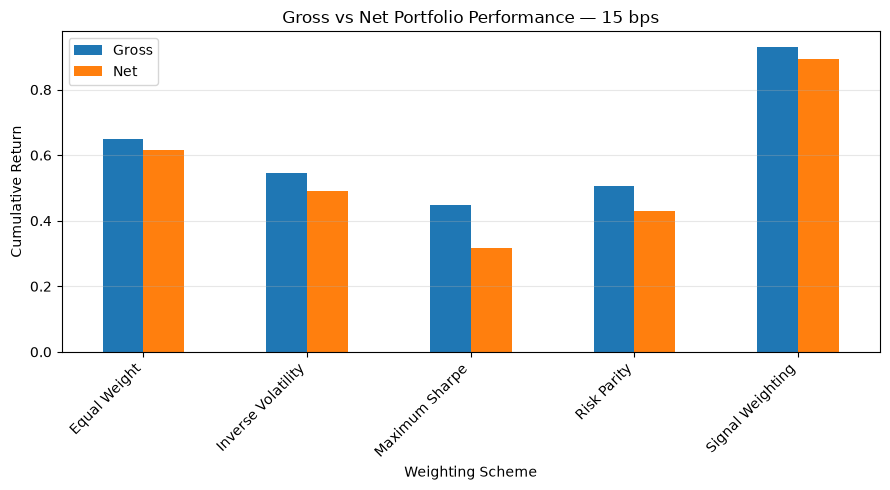

In [54]:
# =============================================================================
# Gross vs Net Performance by Weighting Scheme
# =============================================================================

plot_data = (
    friction_summary
    .groupby("weighting_scheme")[
        [
            "gross_return",
            "net_return_base",
        ]
    ]
    .mean()
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Gross vs Net Portfolio Performance — 15 bps"
)

ax.set_ylabel(
    "Cumulative Return"
)

ax.set_xlabel(
    "Weighting Scheme"
)

ax.legend(
    [
        "Gross",
        "Net"
])

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

La representación gráfica ilustra de forma visual la brecha entre la rentabilidad teórica y la neta para cada esquema de ponderación en el escenario base de $15\text{ bps}$. El gráfico evidencia cómo la brecha entre las barras de retorno bruto y neto se amplía drásticamente a medida que aumenta la complejidad de la optimización: mientras que en Signal Weighting e Equal Weight ambos bloques permanecen alineados reflejando una erosión mínima, en Maximum Sharpe se observa un escalón pronunciado que confirma la severa pérdida de patrimonio acumulado debida a la rotación periódica de posiciones.

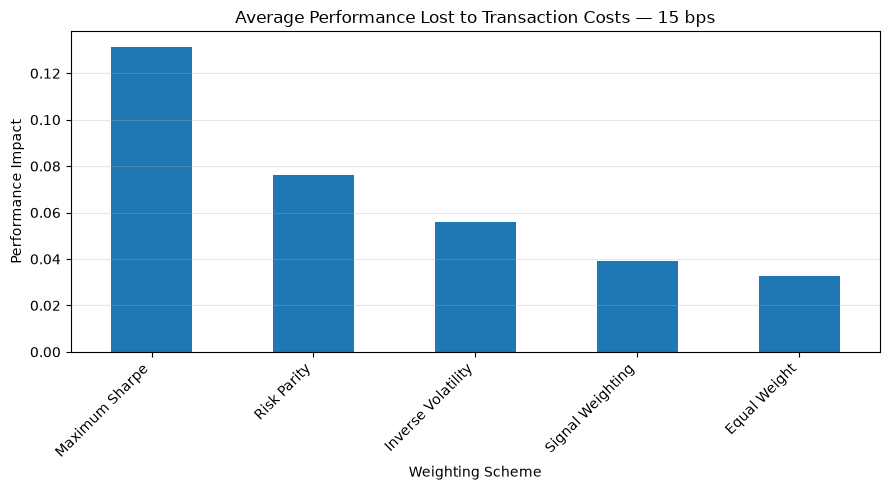

In [53]:
# =============================================================================
# Friction Cost by Weighting Scheme
# =============================================================================

friction_plot = (
    friction_summary
    .groupby("weighting_scheme")[
        "friction_impact_base"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

ax = friction_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Average Performance Lost to Transaction Costs — 15 bps"
)

ax.set_ylabel(
    "Performance Impact"
)

ax.set_xlabel(
    "Weighting Scheme"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

Esta segunda representación complementa la perspectiva anterior aislando exclusivamente la pérdida de patrimonio en términos absolutos (friction impact). Al ordenar las arquitecturas de mayor a menor desgaste, el gráfico resalta la clara asimetría en la penalización operativa: Maximum Sharpe encabeza la pérdida destruyendo más del $13\%$ de patrimonio por costes de ejecución, seguido por los enfoques basados en riesgo (Risk Parity e Inverse Volatility), mientras que Equal Weight y Signal Weighting se sitúan en el extremo inferior con pérdidas acotadas por debajo del $4\%$.

## 10. Conclusions & Transition to Portfolio Performance Analysis

El análisis del impacto de los costes de transacción y la rotación de activos sobre la muestra out-of-sample permite extraer tres conclusiones metodológicas y operativas fundamentales antes de la evaluación económica final:

1. **Magnitud de la Fricción Operativa:** La aplicación del modelo de costes all-in en el escenario base ($15\text{ bps}$) evidencia que la intensidad de rotación varía drásticamente según el esquema de optimización utilizado. Mientras que las estrategias ponderadas por señal e igual ponderación mantienen un *turnover* contenido, los enfoques de optimización media-varianza (*Maximum Sharpe*) registran un desgaste operativo sensiblemente mayor, consumiendo una fracción superior de la rentabilidad bruta.

2. **Estanqueidad y Ausencia de Look-Ahead Bias:** La arquitectura del motor de ejecución —con un desfase estricto de una sesión ($t_k + 1$) entre la generación de la señal analítica y la efectividad operativa de los pesos— garantiza un marco de simulación libre de contaminación por anticipación de datos y completamente reproducible.

3. **Consolidación del Dataset Neto:** Con la generación y exportación del archivo `net_portfolio_returns.parquet`, queda completada la fase de construcción y filtrado operativo de las series temporales. Las curvas de patrimonio resultantes reflejan la rentabilidad real disponible para un inversor tras descontar el impacto del *slippage* y la ejecución de órdenes.


Con los datos de rentabilidad neta consolidados para todos los escenarios de costes, la evaluación económica, la comparativa frente a los *benchmarks* de mercado, el análisis de estabilidad por subperiodos y los test de sensibilidad se desarrollan íntegramente en el **Notebook 09: Portfolio Performance & Sensitivity Analysis**.